# Paper combined - train the edit model, then run BCO experiments

**PART 1** trains the edit agent FROM SCRATCH on the 700-graph graded realistic curriculum (dup -> stub -> detour -> drop_cover -> subtle -> eval-mix -> clean) with the unified objective: 0.5*RTT + 0.5*WMC and a network-level adjustment budget (cap at target=0.2, W=10, paper mode, demand off; the BCO search uses the two-sided |adj-target| form). **PART 2** runs the paper experiments (E1-E6) using that fine-tuned model as `OUR_MODEL_PATH`. Algorithm budgets are set for a full top-to-bottom run that should fit into roughly 25-30 hours on the current CPU calibration; rerun the timing estimator cell after any budget change.

Run top-to-bottom: training must finish before the experiment config picks up the trained weights.


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"   # select GPU 1
import sys, pickle, shutil, json, random as _random
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from hydra import compose, initialize_config_dir
from tqdm.auto import tqdm
from IPython.display import Image, display

from eval_lib.context import (ROOT_DIR, CFG_DIR, DATASETS_DIR,
                              MODEL_OUTPUTS_DIR, EDIT_MODEL_WEIGHTS_DIR)
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from connectpt.routes_generator import utils as lrnu
from connectpt.routes_generator.improvement_learning import (
    _get_planned_current_routes, _make_route_context_state,
    load_raw_graphs_and_lc_routes, make_improvement_batch,
    rollout_lc_improvement, train_lc_improvement_cfg)
from connectpt.routes_generator.torch_utils import (
    get_batch_tensor_from_routes, dump_routes)
from connectpt.routes_generator.transit_time_estimator import (
    ROUTE_ACTION_EXTEND, ROUTE_ACTION_HALT, ROUTE_ACTION_TRIM_END,
    ROUTE_ACTION_TRIM_START, RouteGenBatchState)
from connectpt.routes_generator.citygraph_dataset import (
    STOP_KEY, DynamicCityGraphDataset)
from connectpt.routes_generator.bee_colony import get_adjustment_degrees
from torch_geometric.data import Batch
from eval_lib.results_io import save_table
from eval_lib import build_lc_cfg, run_lc, as_route_tensor
from eval_lib import plots as route_plots

pd.set_option("display.max_columns", None)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

/home/rk/Документы/Python Projects/connectpt/.venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
import os, sys
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "1")
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

from eval_lib.context import ROOT_DIR, EDIT_MODEL_WEIGHTS_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))
from eval_lib import *                      # runners, builders, BENCHMARK_SPECS, ...
from eval_lib import _run_baseline          # private: not pulled by `import *`
from eval_lib import plots as route_plots
from connectpt.routes_generator.bee_colony import get_adjustment_degrees

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_columns", None)
print("device:", device)

# --- wall-clock instrumentation (per-epoch / per-iteration) ---
import time as _time
TIMING = {"epoch_s": None, "dataset_graph_s": None, "bco_iter_s": {}, "base_iter_s": {}}


device: cuda


## Configuration

`copy_full`, `copy_boundary`, `copy_mixed`, and `lc_clean` are equal-size
tiers.  The three corrupted tiers are generated from LC routes with the four
copy/subcopy mutations below.  Multiplicity grows across the curriculum up to
five routes on one stop-to-stop leg.

In [3]:
# Training is OFF: experiments use an existing checkpoint (see OUR_MODEL_PATH).
# Set True to (re)train the edit model in PART 1.
RUN_TRAINING = True

# --- dataset: five tiers (four corrupted + clean), easy -> hard/clean ---
N_GRAPHS        = 1400   # full training pool: 100 graphs/tier (7 tiers)
RAW_N_NODES     = 50
RAW_GRAPH_TYPE  = "mixed"
RAW_GRAPH_SEED  = 0
TARGET_N_ROUTES = 12
MIN_ROUTE_LEN   = 8
MAX_ROUTE_LEN   = 15
LC_N_SAMPLES    = 1
LC_COMBOS = [(1.0,0.0,0.0,"demand"), (0.0,1.0,0.0,"route"), (0.0,0.0,1.0,"conn")]

# Graded curriculum tiers (eval_lib.route_copies.CURRICULUM_TIER_CFG):
# dup_gross -> stub_routes -> detour_gross -> drop_cover -> detour_subtle ->
# realistic_mix (the exact eval-init distribution) -> lc_clean. Each defect is
# fixable by construction with a known reward direction; all street-valid.
from eval_lib.route_copies import (CURRICULUM_TIER_CFG as TIER_CFG,
                                   D_UN_CAP_PCT as D_UN_TARGET_PCT)
TIERS = list(TIER_CFG)
DATASET_DIRNAME = "lc_realistic_curriculum_n700_n50_r12_len8_15_v5"
NEW_DATASET_DIR = DATASETS_DIR / DATASET_DIRNAME
SUBSET_PKL = NEW_DATASET_DIR / "raw_graphs_subset.pkl"
META_CSV   = NEW_DATASET_DIR / "meta.csv"
FORCE_REGEN = False

# --- objective: SINGLE SOURCE = eval_lib/params.py (training == BCO sweeps) ---
# 0.5*RTT + 0.5*WMC(median_weighted) + ADJ_WEIGHT*|adj - ADJ_TARGET|, demand off.
from eval_lib.params import (CONNECTIVITY_MODE, DISABLED_COST_COMPONENTS,
                             UNIFIED_COST_WEIGHTS, ADJ_WEIGHT, ADJ_TARGET,
                             ADJ_TRAIN_OBJECTIVE, ADJ_GAP, ADJ_MODE)
# Vary the cost weights per training batch instead of fixed 0.5/0.5: 30%
# route-only, 30% connectivity-only, 40% random (route, conn) mixes (demand is
# disabled, so the sampler renormalizes over the two enabled components). The
# sampled weights are fed to the agent as conditioning features, so one policy
# serves the whole alpha range (validation stays at the fixed 0.5/0.5 point).
VARY_WEIGHTS = True; OP_FRACTION = 0.3; MCW_FRACTION = 0.3
# Condition the agent on a per-batch adjustment TARGET ~ U[0.1, 0.4] (one extra
# gated global feature; W stays the fixed scalar ADJ_WEIGHT). Validation uses
# the midpoint target. The BCO eval path feeds the run's target to the bee.
CONDITION_ON_ADJ_TARGET = True
ADJ_TARGET_MIN, ADJ_TARGET_MAX = 0.1, 0.7
ROUTE_W = UNIFIED_COST_WEIGHTS["route_time_weight"]
CONN_W = UNIFIED_COST_WEIGHTS["median_connectivity_weight"]

# --- anti-halt-collapse ---
FORCE_NONHALT_FIRST_STEP = False
FORCE_NONHALT_UNTIL_ITER = 150   # half the run: scratch policy needs the crutch far longer than the old finetune
POSITIVE_ONLY_TRIM_REWARD = False
ZERO_TRIM_REWARD = False
ENTROPY_WEIGHT = 0.05   # keep exploring past the forced-nonhalt window (halt logit is the "safe" one)

# --- critic norm + Huber + value clip (both runs) ---
CRITIC_OVERRIDES = ["++critic_normalize_returns=true", "++critic_huber=true",
                    "++critic_huber_delta=1.0", "++critic_value_clip=0.2"]

# --- training run (FROM SCRATCH on the graded realistic curriculum) ---
import torch as _torch
TRAIN_FROM_SCRATCH = True    # random init; no parent checkpoint is loaded
N_ITERATIONS = 300           # from-scratch needs more than the 100-epoch finetune
# GPU-aware budgets: batch 4 was CPU-budgeted and starves a GPU (a 4-graph
# GATv2 forward is launch-overhead-bound). keep_rollout_on_device=True stops
# the per-step GPU->CPU state snapshot + per-minibatch re-upload round trip.
BATCH_SIZE = 16 if _torch.cuda.is_available() else 4
KEEP_ROLLOUT_ON_DEVICE =  False #_torch.cuda.is_available()
TRAIN_FRACTION = 0.9
SPLIT_SEED   = 0
MAX_ROUTE_EDIT_STEPS = MAX_ROUTE_LEN
MAX_TRIM_ACTIONS_PER_ROUTE = 1

# --- init: from scratch by default (TRAIN_FROM_SCRATCH above); the parent
#     PRESERVED checkpoint is only used when TRAIN_FROM_SCRATCH=False ---
RESUME_FROM_CHECKPOINT = False
RESUME_TAG = "resume"
BASE_MODEL_PATH = EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_redundancy_rttwmc_v1_PRESERVED.pt"
REQUIRE_BASE_MODEL = not TRAIN_FROM_SCRATCH


# --- cumulative curriculum: gross defects -> subtle -> eval mix -> clean ---
USE_CURRICULUM = True
CURRICULUM = [
    (round(0.10 * N_ITERATIONS), TIERS[:1], "dup"),
    (round(0.20 * N_ITERATIONS), TIERS[:2], "+stub"),
    (round(0.32 * N_ITERATIONS), TIERS[:3], "+detour"),
    (round(0.44 * N_ITERATIONS), TIERS[:4], "+drop"),
    (round(0.58 * N_ITERATIONS), TIERS[:5], "+subtle"),
    (round(0.75 * N_ITERATIONS), TIERS[:6], "+mix"),
    (N_ITERATIONS,               TIERS,     "+clean"),  # last ~25% includes lc_clean
]

# --- evaluation ---
BALANCED_EVAL_WEIGHTS = (0.5, 0.5)
TRAIN_EVAL_N_PER_TIER = 4   # balanced validation monitor graphs per tier
EVAL_N_PER_TIER = 10
RUN_NAME = "lc_realistic_scratch_rttwmc_adj_v1"
HISTORY_CHECKPOINT_PATH = MODEL_OUTPUTS_DIR / f"{RUN_NAME}_training_history_partial.csv"
FULL_HISTORY_RUN = f"{RUN_NAME}_{RESUME_TAG}" if RESUME_FROM_CHECKPOINT else RUN_NAME
FULL_HISTORY_CHECKPOINT = MODEL_OUTPUTS_DIR / f"{FULL_HISTORY_RUN}_training_history_partial.csv"
PRIOR_HISTORY_FILES = [HISTORY_CHECKPOINT_PATH] if RESUME_FROM_CHECKPOINT else []

print(f"{N_GRAPHS} graphs, tiers={TIERS}; curriculum={[c[2]+'<'+str(c[0]) for c in CURRICULUM]}")
print(f"coverage cap d_un <= {D_UN_TARGET_PCT}% (dup tiers)")
print(f"FINE-TUNE: {N_ITERATIONS} epochs, batch={BATCH_SIZE}, graphs={N_GRAPHS}, resume={RESUME_FROM_CHECKPOINT}")
print(f"base model -> {BASE_MODEL_PATH} | exists={BASE_MODEL_PATH.exists()}")
print(f"connectivity_mode -> {CONNECTIVITY_MODE}")
print(f"plain reward (positive_only={POSITIVE_ONLY_TRIM_REWARD}, zero_trim={ZERO_TRIM_REWARD})")
print(f"dataset -> {NEW_DATASET_DIR}")


1400 graphs, tiers=['dup_gross', 'stub_routes', 'detour_gross', 'drop_cover', 'detour_subtle', 'realistic_mix', 'lc_clean']; curriculum=['dup<30', '+stub<60', '+detour<96', '+drop<132', '+subtle<174', '+mix<225', '+clean<300']
coverage cap d_un <= 10.0% (dup tiers)
FINE-TUNE: 300 epochs, batch=16, graphs=1400, resume=False
base model -> /home/rk/Документы/Python Projects/connectpt/artifacts/model_weights/improvement/improvement_lc_redundancy_rttwmc_v1_PRESERVED.pt | exists=True
connectivity_mode -> median_weighted
plain reward (positive_only=False, zero_trim=False)
dataset -> /home/rk/Документы/Python Projects/connectpt/datasets/lc_realistic_curriculum_n700_n50_r12_len8_15_v5


## Generate the four-tier route-copy dataset

Every corruption copies a whole donor route or a contiguous donor subroute
into another route slot.  Prefix, suffix, and interior replacements preserve
the recipient length.  Candidates with repeated stops are rejected, so the
dataset teaches inter-route redundancy rather than synthetic self-loops.

In [4]:
if RUN_TRAINING:
    from eval_lib.route_copies import (inject_curriculum_tier,
                                       redundancy_stats as _redundancy_stats,
                                       uncovered_demand_pct as _uncovered_demand_pct)
    def _to_fixed(routes):
        t = as_route_tensor(routes).long()
        if t.ndim == 3:
            t = t[0]
        if t.shape[0] < TARGET_N_ROUTES:
            t = torch.cat([t, torch.full((TARGET_N_ROUTES - t.shape[0], t.shape[1]), -1, dtype=t.dtype)], 0)
        else:
            t = t[:TARGET_N_ROUTES]
        if t.shape[1] < MAX_ROUTE_LEN:
            t = torch.cat([t, torch.full((t.shape[0], MAX_ROUTE_LEN - t.shape[1]), -1, dtype=t.dtype)], 1)
        elif t.shape[1] > MAX_ROUTE_LEN:
            t = t[:, :MAX_ROUTE_LEN]
        return t


    def _tensors(g):
        return {"node_locs": g[STOP_KEY].pos.detach().cpu().clone(),
                "street_adj": g.street_adj.detach().cpu().clone(),
                "demand": g.demand.detach().cpu().clone()}


    def generate_dataset():
        if NEW_DATASET_DIR.exists():
            shutil.rmtree(NEW_DATASET_DIR)
        NEW_DATASET_DIR.mkdir(parents=True, exist_ok=True)
        _random.seed(RAW_GRAPH_SEED); torch.manual_seed(RAW_GRAPH_SEED)
        ds = DynamicCityGraphDataset(min_nodes=RAW_N_NODES, max_nodes=RAW_N_NODES,
                                     data_type=RAW_GRAPH_TYPE, mumford_style=True, pos_only=False)
        raw = [ds.generate_graph(n_nodes=RAW_N_NODES) for _ in range(N_GRAPHS)]
        per = N_GRAPHS // len(TIERS)
        subset, meta = [], []
        for gi, g in enumerate(tqdm(raw, desc="generate dataset")):
            tier = TIERS[min(gi // per, len(TIERS) - 1)]
            tier_cfg = TIER_CFG[tier]
            rng = _random.Random(1000 + gi)
            d, rt, cn, ctag = LC_COMBOS[gi % len(LC_COMBOS)]
            c = build_lc_cfg(run_name=f"copy_cur_{gi}", n_routes=TARGET_N_ROUTES,
                             min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN,
                             demand_time_weight=d, route_time_weight=rt,
                             median_connectivity_weight=cn,
                             connectivity_mode=CONNECTIVITY_MODE)
            _, _, _, raw_routes, _ = run_lc(c, tensors=(tn := _tensors(g)), run_name_prefix="copy_cur_",
                                            n_samples=LC_N_SAMPLES)
            routes = _to_fixed(raw_routes)
            before = _redundancy_stats(routes)
            routes, event_counts = inject_curriculum_tier(
                routes, tier_cfg, rng, MIN_ROUTE_LEN, MAX_ROUTE_LEN,
                street_adj=tn["street_adj"], demand=tn["demand"],
                n_nodes=RAW_N_NODES)
            after = _redundancy_stats(routes)
            gdir = NEW_DATASET_DIR / f"graph_{gi:04d}"; gdir.mkdir(parents=True, exist_ok=True)
            dump_routes(f"lc_copy_cur_graph_{gi:04d}_routes", routes, out_dir=gdir)
            subset.append(g)
            meta.append({
                "graph_index": gi, "tier": tier, "tier_kind": tier_cfg["kind"],
                "lc_combo": ctag,
                "applied_events": int(sum(event_counts.values())),
                "mutation_events": json.dumps(dict(event_counts), sort_keys=True),
                "d_un_after_pct": round(_uncovered_demand_pct(routes, tn["demand"], RAW_N_NODES), 2),
                "redun_before": round(before["redundancy"], 4),
                "redun_after": round(after["redundancy"], 4),
                "max_leg_use_before": before["max_leg_use"],
                "max_leg_use_after": after["max_leg_use"],
            })
            if (gi + 1) % 100 == 0:
                print(f"  {gi+1}/{N_GRAPHS} (tier={tier})")
        with SUBSET_PKL.open("wb") as fh:
            pickle.dump(subset, fh)
        pd.DataFrame(meta).to_csv(META_CSV, index=False)
        print(f"Saved {len(subset)} graphs -> {NEW_DATASET_DIR}")


    _have = len(list(NEW_DATASET_DIR.glob("graph_*"))) if NEW_DATASET_DIR.exists() else 0
    if SUBSET_PKL.exists() and _have == N_GRAPHS and META_CSV.exists() and not FORCE_REGEN:
        print(f"dataset already exists ({_have}) -> skip")
    else:
        if _have and _have != N_GRAPHS:
            print(f"found {_have} graphs, expected {N_GRAPHS} -> regenerate")
        _tg = _time.perf_counter()
        generate_dataset()
        TIMING["dataset_graph_s"] = (_time.perf_counter() - _tg) / max(1, N_GRAPHS)
        print(f"[timing] dataset gen: {TIMING['dataset_graph_s']:.2f} s/graph "
              f"(scales with N_GRAPHS: {N_GRAPHS} now)")

found 700 graphs, expected 1400 -> regenerate


generate dataset:   7%|▋         | 100/1400 [05:43<1:15:17,  3.48s/it]

  100/1400 (tier=dup_gross)


generate dataset:  14%|█▍        | 200/1400 [11:29<1:11:56,  3.60s/it]

  200/1400 (tier=dup_gross)


...

generate dataset:  93%|█████████▎| 1300/1400 [1:17:11<05:48,  3.48s/it]

  1300/1400 (tier=lc_clean)


generate dataset: 100%|██████████| 1400/1400 [1:22:57<00:00,  3.56s/it]

  1400/1400 (tier=lc_clean)


Saved 1400 graphs -> /home/rk/Документы/Python Projects/connectpt/datasets/lc_realistic_curriculum_n700_n50_r12_len8_15_v5
[timing] dataset gen: 3.58 s/graph (scales with N_GRAPHS: 1400 now)


## Load, split, and define the cumulative curriculum

In [5]:
if RUN_TRAINING:
    graphs, seed_routes = load_raw_graphs_and_lc_routes(SUBSET_PKL, NEW_DATASET_DIR)
    meta_df = pd.read_csv(META_CSV)
    N = len(graphs)
    print(f"loaded {N} graphs; seed_routes={tuple(seed_routes.shape)}")
    print("copy/subcopy corruption summary by tier:")
    display(meta_df.groupby("tier")[[
        "applied_events",
        "redun_before", "redun_after", "max_leg_use_after", "d_un_after_pct",
    ]].mean().round(3).reindex(TIERS))

    _perm = torch.randperm(N, generator=torch.Generator().manual_seed(SPLIT_SEED))
    TIER_OF = dict(zip(meta_df["graph_index"], meta_df["tier"]))

    # Stratified split: each tier contributes its own train/val so EVERY tier has
    # >= TRAIN_EVAL_N_PER_TIER validation graphs (robust for small N / smoke runs).
    _by_tier = {tier: [] for tier in TIERS}
    for gi in _perm.tolist():
        _by_tier[TIER_OF[gi]].append(gi)
    _train_l, _val_l = [], []
    for tier in TIERS:
        idxs = _by_tier[tier]
        n_val = max(TRAIN_EVAL_N_PER_TIER, int(round((1 - TRAIN_FRACTION) * len(idxs))))
        n_val = min(n_val, max(0, len(idxs) - 1))        # keep >= 1 train when possible
        if len(idxs) - n_val < 1 or n_val < TRAIN_EVAL_N_PER_TIER:
            raise ValueError(
                f"tier '{tier}' has only {len(idxs)} graphs -- too few for "
                f"TRAIN_EVAL_N_PER_TIER={TRAIN_EVAL_N_PER_TIER}; raise N_GRAPHS or "
                f"lower TRAIN_EVAL_N_PER_TIER")
        _val_l += idxs[:n_val]; _train_l += idxs[n_val:]
    TRAIN_INDICES = torch.tensor(_train_l, dtype=torch.long)
    VAL_INDICES = torch.tensor(_val_l, dtype=torch.long)

    _val_by_tier = {tier: [] for tier in TIERS}
    for gi in VAL_INDICES.tolist():
        _val_by_tier[TIER_OF[gi]].append(gi)
    MONITOR_VAL_INDICES = torch.tensor([
        gi for tier in TIERS for gi in _val_by_tier[tier][:TRAIN_EVAL_N_PER_TIER]
    ], dtype=torch.long)
    print(f"validation graphs={len(VAL_INDICES)}; balanced train-loop monitor={len(MONITOR_VAL_INDICES)}")

    _train_by_tier = {tier: [] for tier in TIERS}
    for gi in TRAIN_INDICES.tolist():
        _train_by_tier[TIER_OF[gi]].append(gi)
    _train_by_tier = {
        tier: torch.tensor(indices, dtype=torch.long)
        for tier, indices in _train_by_tier.items()
    }
    print("train graphs per tier:", {tier: len(indices) for tier, indices in _train_by_tier.items()})


    def curriculum_fn(iteration):
        '''iteration -> (active train indices, stage label).'''
        for until, tiers, label in CURRICULUM:
            if iteration < until:
                idx = torch.cat([_train_by_tier[tier] for tier in tiers if len(_train_by_tier[tier])])
                return idx, label
        tiers = CURRICULUM[-1][1]
        idx = torch.cat([_train_by_tier[tier] for tier in tiers if len(_train_by_tier[tier])])
        return idx, CURRICULUM[-1][2]


    def stage_spans():
        '''[(start_iter, end_iter, label)] for curriculum shading.'''
        spans, prev = [], 0
        for until, _tiers, label in CURRICULUM:
            spans.append((prev + 1, until, label)); prev = until
        return spans

loaded 1400 graphs; seed_routes=(1400, 12, 15)
copy/subcopy corruption summary by tier:


,applied_events,redun_before,redun_after,max_leg_use_after,d_un_after_pct
tier,,,,,
dup_gross,3.000,0.283,0.483,5.605,31.512
stub_routes,11.860,0.292,0.268,3.290,11.347
detour_gross,2.505,0.310,0.353,3.905,0.000
drop_cover,2.305,0.295,0.303,3.450,8.898
detour_subtle,2.925,0.298,0.344,3.895,1.306
realistic_mix,4.365,0.297,0.354,3.940,7.194
lc_clean,0.000,0.304,0.304,3.510,0.000


validation graphs=140; balanced train-loop monitor=28
train graphs per tier: {'dup_gross': 180, 'stub_routes': 180, 'detour_gross': 180, 'drop_cover': 180, 'detour_subtle': 180, 'realistic_mix': 180, 'lc_clean': 180}


## Model and objective builders

Two helpers used by the fine-tune run below. `build_edit_run` composes the
hydra config, builds a **fresh** trim model + cost module, selects which of
the three cost components (`demand` / `route` / `connectivity`) are active,
and enables the optional adjustment-degree shaping through `adj_weight`.
`train_edit_run` wraps `train_lc_improvement_cfg` and returns the in-memory
history. Adjustment conditioning stays off, so the fine-tuned actor keeps the
same architecture as the RTT+connectivity checkpoint.


In [6]:
def build_edit_run(run_name, disabled_components, vary_weights=True,
                   critic_overrides=None, route_time_weight=None, adj_weight=0.0,
                   adj_target=None, adj_objective=None, adj_gap=None, adj_mode=None):
    """Compose cfg + build a fresh trim model/cost module for one training run."""
    critic_overrides = list(CRITIC_OVERRIDES if critic_overrides is None
                            else critic_overrides)
    adj_target = ADJ_TARGET if adj_target is None else adj_target
    adj_objective = ADJ_TRAIN_OBJECTIVE if adj_objective is None else adj_objective
    adj_gap = ADJ_GAP if adj_gap is None else adj_gap
    adj_mode = ADJ_MODE if adj_mode is None else adj_mode
    overrides = [
        "model=bestsofar_feb2023_trim",
        "model.route_generator.kwargs.serial_halting=True",
        "model.route_generator.kwargs.allow_trim_below_min=true",
        f"++run_name={run_name}", "++experiment.logdir=null",
        f"++experiment.cost_function.kwargs.connectivity_mode={CONNECTIVITY_MODE}",
        f"++adjustment_degree_weight={float(adj_weight)}",
        f"++adjustment_degree_target={float(adj_target)}",
        f"++adjustment_degree_objective={adj_objective}",
        f"++adjustment_degree_gap={float(adj_gap)}",
        f"++adjustment_degree_mode={adj_mode}",
        f"++adjustment_conditioning={str(CONDITION_ON_ADJ_TARGET).lower()}",
        "++adjustment_condition_current=false",
        "++adjustment_condition_weight=false",
        f"++adjustment_target_min={float(ADJ_TARGET_MIN)}",
        f"++adjustment_target_max={float(ADJ_TARGET_MAX)}",
        ("++model.route_generator.kwargs.n_adjustment_cond_feats=1"
         if CONDITION_ON_ADJ_TARGET else
         "++model.route_generator.kwargs.n_adjustment_cond_feats=0"),
        f"++entropy_weight={float(ENTROPY_WEIGHT)}",
        f"++force_nonhalt_first_step_until_iter={int(FORCE_NONHALT_UNTIL_ITER)}",
        f"++positive_only_trim_reward={str(POSITIVE_ONLY_TRIM_REWARD).lower()}",
        f"++zero_trim_reward={str(ZERO_TRIM_REWARD).lower()}",
        f"++keep_rollout_on_device={str(KEEP_ROLLOUT_ON_DEVICE).lower()}",
    ] + critic_overrides
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name="ppo_50nodes.yaml", overrides=overrides)
    _, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg, run_name_prefix="improvement_")
    cost_obj.ignore_stops_oob = True
    cost_obj.set_enabled_components(disabled_components=disabled_components or None)
    if vary_weights:
        cost_obj.variable_weights = True
        cost_obj.pp_fraction = 0.0
        cost_obj.op_fraction = OP_FRACTION
        cost_obj.mcw_fraction = MCW_FRACTION
    else:
        cost_obj.variable_weights = False
    if route_time_weight is not None:
        cost_obj.route_time_weight = float(route_time_weight)
    best_path = EDIT_MODEL_WEIGHTS_DIR / f"{run_name}.pt"
    print(f"run_name={run_name} | enabled={list(cost_obj.enabled_component_names)} | "
          f"variable_weights={cost_obj.variable_weights} | edge_dim={model.edge_feat_dim}")
    print(f"  connectivity_mode={cost_obj.connectivity_mode}")
    print(f"  trim reward: zero_trim={cfg.get('zero_trim_reward')} "
          f"pos_only={cfg.get('positive_only_trim_reward')} | "
          f"critic_norm={cfg.get('critic_normalize_returns')}")
    print(f"  adj shaping: W={cfg.get('adjustment_degree_weight')} "
          f"target={cfg.get('adjustment_degree_target')} "
          f"objective={cfg.get('adjustment_degree_objective')} "
          f"mode={cfg.get('adjustment_degree_mode')} gap={cfg.get('adjustment_degree_gap')}")
    return cfg, cost_obj, model, run_name, best_path


def _pad_route_tensor(t, n_routes, width):
    if t.ndim == 2:
        t = t.unsqueeze(0)
    out = torch.full((t.shape[0], n_routes, width), -1,
                     dtype=t.dtype, device=t.device)
    nr = min(n_routes, t.shape[1])
    w = min(width, t.shape[2])
    out[:, :nr, :w] = t[:, :nr, :w]
    return out


def _rollout_adjustment_kwargs_for_model(model, *, target=None):
    n_adj_feats = int(getattr(model, "n_adjustment_cond_feats", 0) or 0)
    if n_adj_feats <= 0:
        return {}
    target = ADJ_TARGET if target is None else target
    kwargs = dict(adjustment_target=float(target),
                  adjustment_use_current=False,
                  adjustment_gap=ADJ_GAP,
                  adjustment_mode=ADJ_MODE)
    if n_adj_feats > 1:
        kwargs["adjustment_weight"] = float(ADJ_WEIGHT)
    return kwargs


def _adj_penalty_from_routes(routes, reference, cost_obj, *, weight, target,
                             objective, gap, mode):
    n_routes = max(int(routes.shape[1]), int(reference.shape[1]))
    width = max(int(routes.shape[2]), int(reference.shape[2]))
    routes = _pad_route_tensor(routes, n_routes, width)
    reference = _pad_route_tensor(reference, n_routes, width)
    adj = get_adjustment_degrees(
        routes, reference, cost_obj.symmetric_routes, gap=gap, mode=mode)
    # NETWORK-level form (matches MyCostModule._adjustment_penalty and the PPO
    # shaping): average the degrees first, then apply the objective transform.
    net_adj = adj.mean(dim=1)
    if objective == "cap":
        pen = (net_adj - float(target)).clamp(min=0.0)
    elif objective == "cap_sq":
        pen = (net_adj - float(target)).clamp(min=0.0) ** 2
    elif objective == "target":
        pen = (net_adj - float(target)).abs()
    else:
        pen = net_adj
    return float(weight) * pen, net_adj


# train_lc_improvement_cfg validates and saves best checkpoints through the
# module-level evaluate_lc_improvement. Patch it locally so validation is scored
# with the same network-level adjustment penalty (ADJ_TRAIN_OBJECTIVE) as the
# PPO reward shaping.
import connectpt.routes_generator.improvement_learning as _il_mod
if not hasattr(_il_mod, "_paper_combined_raw_evaluate_lc_improvement"):
    _il_mod._paper_combined_raw_evaluate_lc_improvement = _il_mod.evaluate_lc_improvement
_RAW_EVALUATE_LC_IMPROVEMENT = _il_mod._paper_combined_raw_evaluate_lc_improvement


def evaluate_lc_improvement_adj_aware(model, cost_obj, graphs, seed_routes, indices,
                                      device, min_route_len, max_route_len,
                                      batch_size=8, force_nonhalt_first_step=False,
                                      max_route_edit_steps=None,
                                      max_trim_actions_per_route=1,
                                      return_action_stats=False,
                                      target_n_routes=None,
                                      return_best_routes=False,
                                      adjustment_target=None,
                                      adjustment_weight=None,
                                      adjustment_use_current=False,
                                      adjustment_gap=0.1,
                                      adjustment_mode="paper"):
    if adjustment_target is None:
        _adj_kwargs = _rollout_adjustment_kwargs_for_model(model)
        adjustment_target = _adj_kwargs.get("adjustment_target")
        adjustment_weight = _adj_kwargs.get("adjustment_weight", adjustment_weight)
        adjustment_use_current = _adj_kwargs.get(
            "adjustment_use_current", adjustment_use_current)
        adjustment_gap = _adj_kwargs.get("adjustment_gap", adjustment_gap)
        adjustment_mode = _adj_kwargs.get("adjustment_mode", adjustment_mode)
    result = _RAW_EVALUATE_LC_IMPROVEMENT(
        model, cost_obj, graphs, seed_routes, indices, device,
        min_route_len, max_route_len, batch_size=batch_size,
        force_nonhalt_first_step=force_nonhalt_first_step,
        max_route_edit_steps=max_route_edit_steps,
        max_trim_actions_per_route=max_trim_actions_per_route,
        return_action_stats=return_action_stats,
        target_n_routes=target_n_routes,
        return_best_routes=return_best_routes,
        adjustment_target=adjustment_target,
        adjustment_weight=adjustment_weight,
        adjustment_use_current=adjustment_use_current,
        adjustment_gap=adjustment_gap,
        adjustment_mode=adjustment_mode)

    eval_weights = cost_obj.get_weights(device)
    raw_seed_costs, raw_final_costs = [], []
    seed_adj_pens, final_adj_pens = [], []
    seed_adjs, final_adjs = [], []

    batch_splits = list(indices.split(batch_size))
    for batch_indices, final_routes_cpu in zip(batch_splits, result["routes"]):
        graph_batch, route_batch = make_improvement_batch(
            graphs, seed_routes, batch_indices, device, training=False,
            target_n_routes=target_n_routes)
        final_routes = final_routes_cpu.to(device)
        if final_routes.ndim == 2:
            final_routes = final_routes.unsqueeze(0)

        seed_state = RouteGenBatchState(
            graph_batch, cost_obj, route_batch.shape[1],
            min_route_len, max_route_len,
            cost_weights=_il_mod._clone_cost_weights(eval_weights))
        seed_state.add_new_routes(route_batch)
        final_state = RouteGenBatchState(
            graph_batch, cost_obj, final_routes.shape[1],
            min_route_len, max_route_len,
            cost_weights=_il_mod._clone_cost_weights(eval_weights))
        final_state.add_new_routes(final_routes)

        raw_seed_costs.append(cost_obj(seed_state).cost.detach().cpu())
        raw_final_costs.append(cost_obj(final_state).cost.detach().cpu())
        sp, sa = _adj_penalty_from_routes(
            route_batch, route_batch, cost_obj,
            weight=ADJ_WEIGHT, target=ADJ_TARGET,
            objective=ADJ_TRAIN_OBJECTIVE, gap=ADJ_GAP, mode=ADJ_MODE)
        fp, fa = _adj_penalty_from_routes(
            final_routes, route_batch, cost_obj,
            weight=ADJ_WEIGHT, target=ADJ_TARGET,
            objective=ADJ_TRAIN_OBJECTIVE, gap=ADJ_GAP, mode=ADJ_MODE)
        seed_adj_pens.append(sp.detach().cpu())
        final_adj_pens.append(fp.detach().cpu())
        seed_adjs.append(sa.detach().cpu())
        final_adjs.append(fa.detach().cpu())

    raw_seed_costs = torch.cat(raw_seed_costs)
    raw_final_costs = torch.cat(raw_final_costs)
    seed_adj_pens = torch.cat(seed_adj_pens)
    final_adj_pens = torch.cat(final_adj_pens)
    seed_adjs = torch.cat(seed_adjs)
    final_adjs = torch.cat(final_adjs)
    adj_seed_costs = raw_seed_costs + seed_adj_pens
    adj_final_costs = raw_final_costs + final_adj_pens

    result.update({
        "raw_seed_cost": raw_seed_costs.mean().item(),
        "raw_final_cost": raw_final_costs.mean().item(),
        "raw_delta": (raw_seed_costs - raw_final_costs).mean().item(),
        "seed_adjustment_penalty": seed_adj_pens.mean().item(),
        "final_adjustment_penalty": final_adj_pens.mean().item(),
        "seed_adjustment_degree": seed_adjs.mean().item(),
        "final_adjustment_degree": final_adjs.mean().item(),
        "adjustment_penalty_delta": (seed_adj_pens - final_adj_pens).mean().item(),
        "adjustment_degree_delta": (seed_adjs - final_adjs).mean().item(),
        "seed_cost": adj_seed_costs.mean().item(),
        "final_cost": adj_final_costs.mean().item(),
        "delta": (adj_seed_costs - adj_final_costs).mean().item(),
        "win_rate": (adj_final_costs < adj_seed_costs).float().mean().item(),
    })
    return result


_il_mod.evaluate_lc_improvement = evaluate_lc_improvement_adj_aware


def train_edit_run(model, cost_obj, cfg, run_name, best_path,
                   n_iterations, batch_size, train_indices, val_indices,
                   curriculum_fn=None, checkpoint=None):
    """Train one edit model and return its in-memory history DataFrame."""
    result = train_lc_improvement_cfg(
        model=model, cost_obj=cost_obj, graphs=graphs, seed_routes=seed_routes,
        device=device, cfg=cfg, output_dir=MODEL_OUTPUTS_DIR, run_name=run_name,
        train_fraction=TRAIN_FRACTION, batch_size=batch_size,
        min_route_len=MIN_ROUTE_LEN, max_route_len=MAX_ROUTE_LEN, seed=SPLIT_SEED,
        max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
        max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
        target_n_routes=TARGET_N_ROUTES,
        train_indices=train_indices, val_indices=val_indices,
        best_model_path=best_path, n_iterations=n_iterations,
        force_nonhalt_first_step=FORCE_NONHALT_FIRST_STEP,
        curriculum_fn=curriculum_fn,
        history_checkpoint_path=checkpoint,
    )
    df = pd.DataFrame(result["history"])
    save_table(df, f"{run_name}_training_history")
    print(f"history rows={len(df)}; best -> {best_path}")
    return df


print("builders ready: build_edit_run(), train_edit_run()")
print("adj-aware validation installed: val cost/delta/win_rate include the network-level ADJ_TRAIN_OBJECTIVE adjustment penalty")


builders ready: build_edit_run(), train_edit_run()
adj-aware validation installed: val cost/delta/win_rate include the network-level ADJ_TRAIN_OBJECTIVE adjustment penalty


## From-scratch training - route + connectivity + adj (W=10)

This run starts from the final-experiments RTT + connectivity checkpoint,
keeps `route` and `connectivity` active at 0.5/0.5 (demand off), and adds
network-level adjustment-budget reward shaping (cap at target=0.2, W=10, paper mode). The budget is 100
epochs over the current 500-graph copy-redundancy curriculum, batch 4, with
balanced per-tier validation monitoring. The resulting checkpoint is saved
under a new `adjcap` run name and is used by the evaluation cells below.

If `RESUME_FROM_CHECKPOINT=True`, this cell reloads the adj-finetune output
first; otherwise it initializes from `BASE_MODEL_PATH`.


In [ ]:
if RUN_TRAINING:
    # Train from scratch: route + connectivity (0.5/0.5) + adj penalty (W=ADJ_WEIGHT); demand off.
    cfg, cost_obj, model, run_name, BEST_MODEL_PATH = build_edit_run(
        run_name=RUN_NAME,
        disabled_components=DISABLED_COST_COMPONENTS,
        vary_weights=VARY_WEIGHTS,
        route_time_weight=ROUTE_W,
        adj_weight=ADJ_WEIGHT,
        adj_target=ADJ_TARGET,
        adj_objective=ADJ_TRAIN_OBJECTIVE,
        adj_gap=ADJ_GAP, adj_mode=ADJ_MODE)
    cost_obj.median_connectivity_weight = float(CONN_W)   # fix conn weight (demand off)
    print(f"train objective: route={ROUTE_W} conn={CONN_W} demand=off | "
          f"adj W={ADJ_WEIGHT} target={ADJ_TARGET} "
          f"objective={ADJ_TRAIN_OBJECTIVE} mode={ADJ_MODE} gap={ADJ_GAP}")

    # From-scratch by default; resume / parent-checkpoint init only when asked.
    if RESUME_FROM_CHECKPOINT and BEST_MODEL_PATH.exists():
        model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
        print(f"resumed weights <- {BEST_MODEL_PATH}")
    elif TRAIN_FROM_SCRATCH:
        print(f"training FROM SCRATCH (random init) -> {BEST_MODEL_PATH.name}")
    elif BASE_MODEL_PATH.exists():
        model.load_state_dict(torch.load(BASE_MODEL_PATH, map_location=device))
        print(f"initialized from parent PRESERVED checkpoint <- {BASE_MODEL_PATH}")
    elif REQUIRE_BASE_MODEL:
        raise FileNotFoundError(
            "No base RTT+connectivity model found. Checked: "
            + str(BASE_MODEL_PATH)
        )
    else:
        print("base checkpoint missing; training from scratch")

    _t_train0 = _time.perf_counter()
    history_df = train_edit_run(
        model, cost_obj, cfg, FULL_HISTORY_RUN, BEST_MODEL_PATH,
        n_iterations=N_ITERATIONS, batch_size=BATCH_SIZE,
        train_indices=TRAIN_INDICES, val_indices=MONITOR_VAL_INDICES,
        curriculum_fn=(curriculum_fn if USE_CURRICULUM else None),
        checkpoint=FULL_HISTORY_CHECKPOINT)
    print(f"continuation history -> {FULL_HISTORY_RUN}_training_history "
          f"(partial: {FULL_HISTORY_CHECKPOINT.name})")
    TIMING["epoch_s"] = (_time.perf_counter() - _t_train0) / max(1, N_ITERATIONS)
    print(f"[timing] training: {TIMING['epoch_s']:.2f} s/epoch over {N_ITERATIONS} epochs")

run_name=improvement_lc_realistic_scratch_rttwmc_adj_v1 | enabled=['route', 'connectivity'] | variable_weights=True | edge_dim=18
  connectivity_mode=median_weighted
  trim reward: zero_trim=False pos_only=False | critic_norm=True
  adj shaping: W=10.0 target=0.2 objective=cap mode=paper gap=0.1
train objective: route=0.5 conn=0.5 demand=off | adj W=10.0 target=0.2 objective=cap mode=paper gap=0.1
training FROM SCRATCH (random init) -> improvement_lc_realistic_scratch_rttwmc_adj_v1.pt


cfg ppo improvement:   0%|          | 1/300 [01:06<5:32:48, 66.78s/it, reward=-0.038, t_ret=-0.126, delta=-0.110, ratio=0.862, clip=13.80%]

cfg_ppo_iter=001 reward=-0.0382 reward_ep=-0.1103 reward_delta_err=0.0000 train_ret=-0.1260 train_delta=-0.1103 val_delta=nan ratio=0.862 clip=13.80% actions=ext:625 trim_s:85 trim_e:105 halt:431 avg_steps=2.88 eval=False


cfg ppo improvement:   1%|          | 2/300 [02:21<5:56:19, 71.74s/it, reward=-0.029, t_ret=-0.109, delta=-0.153, ratio=1.000, clip=0.00%] 

cfg_ppo_iter=002 reward=-0.0286 reward_ep=-0.1527 reward_delta_err=0.0000 train_ret=-0.1085 train_delta=-0.1527 val_delta=nan ratio=1.000 clip=0.00% actions=ext:1407 trim_s:222 trim_e:194 halt:400 avg_steps=5.34 eval=False


...

cfg_ppo_iter=075 reward=0.0084 reward_ep=0.0268 reward_delta_err=-0.0000 train_ret=0.0349 train_delta=0.0268 val_delta=-1.8452 ratio=0.989 clip=13.71% actions=ext:759 trim_s:119 trim_e:140 halt:463 avg_steps=3.19 eval=False


cfg ppo improvement:  25%|██▌       | 76/300 [1:34:26<4:25:02, 70.99s/it, reward=0.005, t_ret=0.023, delta=0.014, ratio=0.999, clip=6.37%] 

cfg_ppo_iter=076 reward=0.0046 reward_ep=0.0143 reward_delta_err=-0.0000 train_ret=0.0234 train_delta=0.0143 val_delta=-1.8452 ratio=0.999 clip=6.37% actions=ext:714 trim_s:122 trim_e:116 halt:445 avg_steps=3.12 eval=False


cfg ppo improvement:  26%|██▌       | 77/300 [1:35:40<4:27:43, 72.03s/it, reward=0.004, t_ret=0.037, delta=0.012, ratio=1.002, clip=6.99%]

cfg_ppo_iter=077 reward=0.0045 reward_ep=0.0119 reward_delta_err=0.0000 train_ret=0.0375 train_delta=0.0119 val_delta=-1.8452 ratio=1.002 clip=6.99% actions=ext:619 trim_s:129 trim_e:114 halt:511 avg_steps=2.68 eval=False


## Train the edit model (cumulative curriculum)

Fine-tune the edit model over the cumulative curriculum (duplicate -> boundary
-> mixed -> covered -> clean). Training history is checkpointed to a partial CSV;
on resume the prior history is prepended.

history stitched: lc_realistic_scratch_rttwmc_adj_v1_training_history_partial.csv(100) => 100 epochs


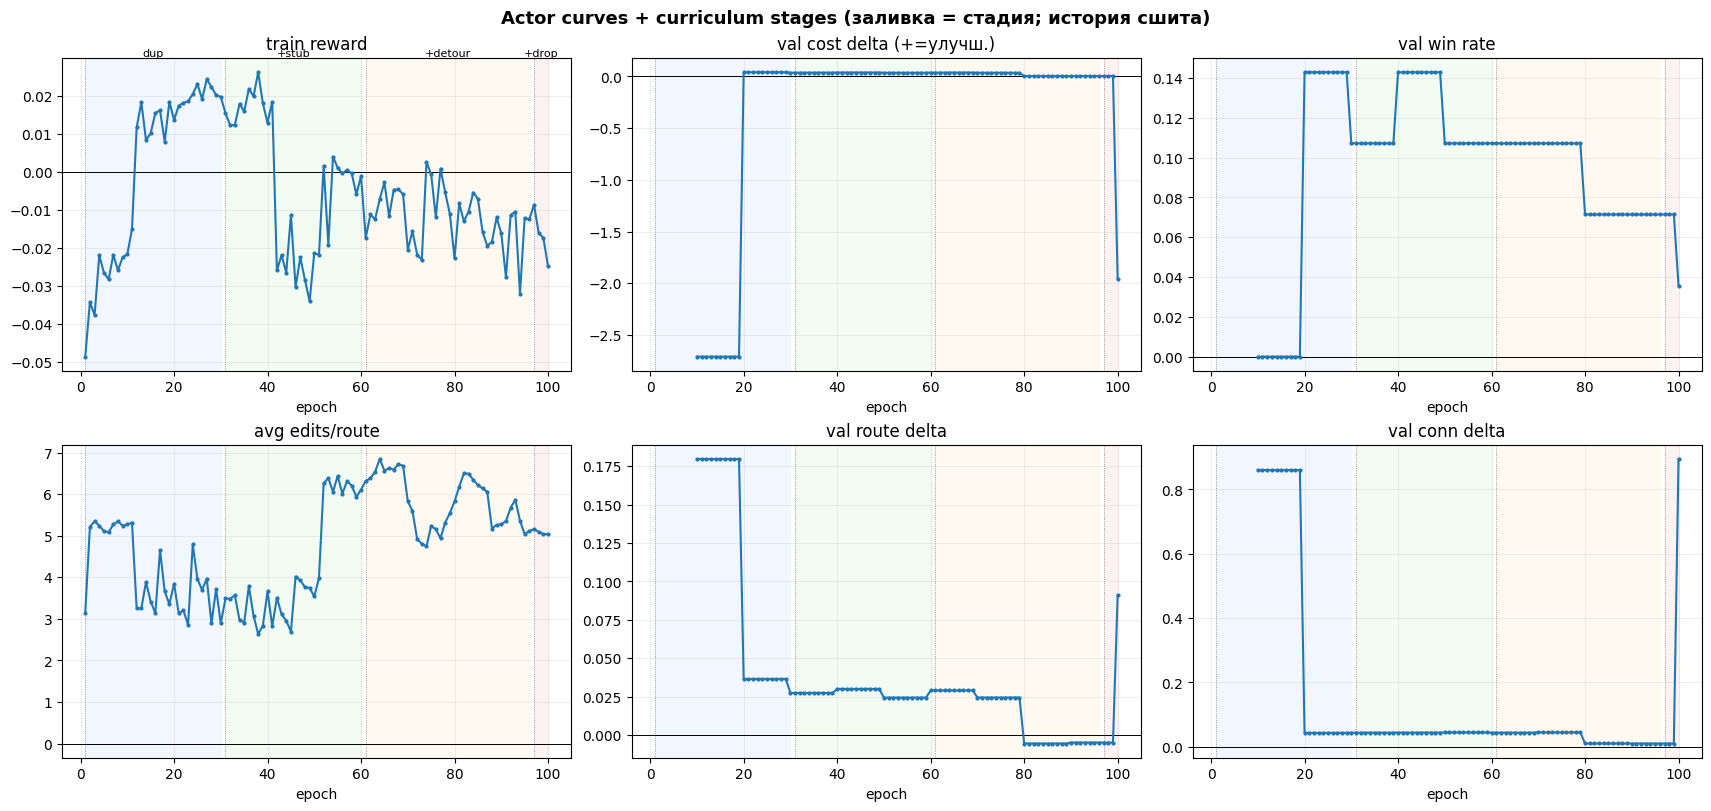

In [ ]:
if RUN_TRAINING:
    if "pd" not in globals():
        import pandas as pd
    if "plt" not in globals():
        import matplotlib.pyplot as plt
    from pathlib import Path

    # --- stitch history: prior part(s) (e.g. machine-1) + this run's continuation ---
    _parts, _labels = [], []
    for _f in (PRIOR_HISTORY_FILES if "PRIOR_HISTORY_FILES" in globals() else []):
        _f = Path(_f)
        if _f.exists():
            _parts.append(pd.read_csv(_f)); _labels.append(f"{_f.name}({len(_parts[-1])})")
    if "history_df" in globals():
        _parts.append(history_df.copy()); _labels.append(f"in-memory({len(history_df)})")
    elif "FULL_HISTORY_CHECKPOINT" in globals() and Path(FULL_HISTORY_CHECKPOINT).exists():
        _parts.append(pd.read_csv(FULL_HISTORY_CHECKPOINT))
        _labels.append(f"{Path(FULL_HISTORY_CHECKPOINT).name}({len(_parts[-1])})")
    if not _parts:
        raise FileNotFoundError("No history found. Train at least one epoch first.")
    h = pd.concat(_parts, ignore_index=True)
    h["epoch"] = range(1, len(h) + 1)          # continuous axis across stitched parts
    print(f"history stitched: {' + '.join(_labels)} => {len(h)} epochs")

    def _num(col):
        return pd.to_numeric(h[col], errors="coerce") if col in h.columns else None

    # curriculum stage spans derived from the stitched data (robust to stitching)
    if "curriculum_stage" in h.columns and h["curriculum_stage"].notna().any():
        _spans = []
        for _epoch, _label in h[["epoch", "curriculum_stage"]].dropna().itertuples(index=False, name=None):
            _epoch = int(_epoch)
            if _spans and _spans[-1][2] == _label:
                _spans[-1] = (_spans[-1][0], _epoch, _label)
            else:
                _spans.append((_epoch, _epoch, _label))
    elif "stage_spans" in globals():
        _spans = stage_spans()
    else:
        _spans = []
    _colors = ["#eaf3ff", "#eafbea", "#fff6e6", "#fdeaea", "#f0eaff"]
    def _shade(ax):
        for k, (s, e, lab) in enumerate(_spans):
            ax.axvspan(s, e, color=_colors[k % len(_colors)], alpha=0.6, zorder=0)
            ax.axvline(s, color="gray", lw=0.6, ls=":")

    fig, ax = plt.subplots(2, 3, figsize=(17, 8), constrained_layout=True)
    panels = [("train_reward_mean","train reward"), ("val_delta","val cost delta (+=улучш.)"),
              ("val_win_rate","val win rate"), ("train_action_avg_actions_per_route","avg edits/route"),
              ("val_component_delta_route","val route delta"),
              ("val_component_delta_connectivity","val conn delta")]
    for a,(col,title) in zip(ax.flat, panels):
        _shade(a); y=_num(col)
        if y is not None and y.notna().any():
            a.plot(h["epoch"], y, marker="o", ms=2, color="tab:blue", zorder=3)
        a.axhline(0,color="k",lw=0.7); a.set_title(title); a.set_xlabel("epoch"); a.grid(alpha=0.2)
    # подписи стадий сверху
    for s,e,lab in _spans:
        ax[0,0].text((s+e)/2, ax[0,0].get_ylim()[1], lab, ha="center", va="bottom", fontsize=8)
    fig.suptitle("Actor curves + curriculum stages (заливка = стадия; история сшита)",
                 fontsize=13, fontweight="bold")
    plt.show()    # keep the inline image as before

    # --- TensorBoard: persist the full (stitched) history + this figure ---
    # Inline image stays above; this just ALSO mirrors every scalar column to a
    # TensorBoard run so the history is browsable/zoomable and comparable across
    # runs.  Launch:  tensorboard --logdir <MODEL_OUTPUTS_DIR>/tensorboard
    from torch.utils.tensorboard import SummaryWriter

    def _tb_tag(col):
        for pre, grp in (("train_ppo_", "ppo/"), ("train_critic_", "critic/"),
                         ("train_action_", "action/"),
                         ("train_component_", "component/train_"),
                         ("val_component_", "component/val_"),
                         ("train_", "train/"), ("val_", "val/")):
            if col.startswith(pre):
                return grp + col[len(pre):]
        return "misc/" + col

    _tb_run = FULL_HISTORY_RUN if "FULL_HISTORY_RUN" in globals() else RUN_NAME
    _tb_dir = MODEL_OUTPUTS_DIR / "tensorboard" / _tb_run
    _tb_dir.mkdir(parents=True, exist_ok=True)
    _writer = SummaryWriter(log_dir=str(_tb_dir))
    _epochs = h["epoch"].astype(int).tolist()
    _n_scalars = 0
    for _col in h.columns:
        if _col == "epoch":
            continue
        _y = pd.to_numeric(h[_col], errors="coerce")
        if not _y.notna().any():
            continue
        _tag = _tb_tag(_col)
        for _ep, _v in zip(_epochs, _y.tolist()):
            if _v == _v:  # skip NaN
                _writer.add_scalar(_tag, float(_v), _ep)
        _n_scalars += 1
    _writer.add_figure("actor_curves", fig, global_step=_epochs[-1])
    _writer.flush(); _writer.close()
    plt.close(fig)
    print(f"[tensorboard] {_n_scalars} scalar series ({len(_epochs)} epochs) -> {_tb_dir}")
    print(f"[tensorboard] launch:  tensorboard --logdir \"{MODEL_OUTPUTS_DIR / 'tensorboard'}\"")

## Critic diagnostics (per-component critic MSE / explained variance)

critic columns: ['train_critic_mse_mean', 'train_critic_explained_variance']


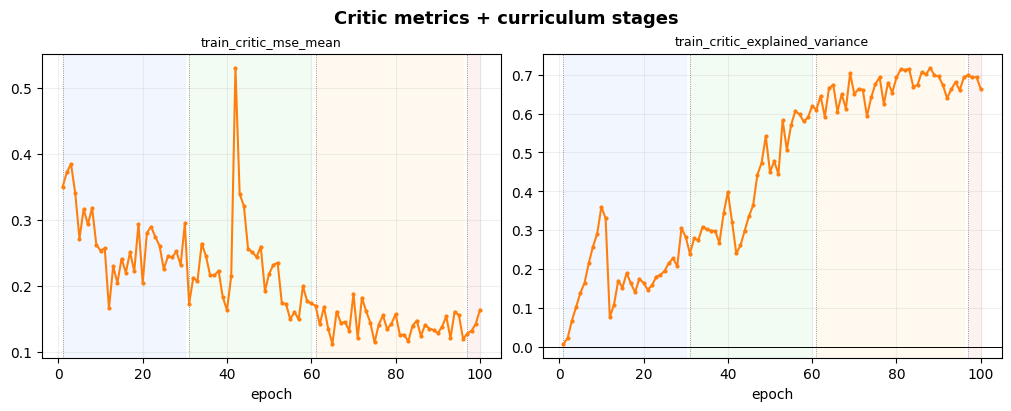

,epoch,curriculum_stage,train_critic_mse_mean,train_critic_explained_variance
0,1,dup,0.3501,0.0078
6,7,dup,0.2933,0.2147
12,13,dup,0.2296,0.1090
18,19,dup,0.2941,0.1753
24,25,dup,0.2256,0.1956
30,31,+stub,0.1728,0.2399
36,37,+stub,0.2160,0.2979
42,43,+stub,0.3396,0.2609
48,49,+stub,0.1924,0.5415
54,55,+stub,0.1494,0.5703


In [ ]:
if RUN_TRAINING:
    crit_cols = [c for c in h.columns if "critic" in c.lower()]
    print("critic columns:", crit_cols)
    if crit_cols:
        n=len(crit_cols)
        fig, ax = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False, constrained_layout=True)
        for a, col in zip(ax[0], crit_cols):
            _shade(a); y=_num(col)
            if y is not None and y.notna().any():
                a.plot(h["epoch"], y, marker="o", ms=2, color="tab:orange", zorder=3)
            a.set_title(col, fontsize=9); a.set_xlabel("epoch"); a.grid(alpha=0.2)
            if "explained" in col: a.axhline(0, color="k", lw=0.7)
        fig.suptitle("Critic metrics + curriculum stages", fontsize=13, fontweight="bold")
        plt.show(); plt.close(fig)
        display(h[["epoch","curriculum_stage"]+crit_cols].iloc[::max(1,len(h)//15)].round(4))

## Evaluate balanced policy by tier

The table reports before/after route-level redundancy, `ATT`, `RTT`,
connectivity, and demand percentages by transfer bucket (`d0`, `d1`, `d2`,
`d_un`). `Adj(current, seed)` remains available only in the example plots.

In [ ]:
if RUN_TRAINING:
    from eval_lib.route_copies import redundancy_stats as _redundancy_stats
    _required_eval_globals = (
        "TIERS", "EVAL_N_PER_TIER", "_val_by_tier", "BALANCED_EVAL_WEIGHTS",
        "graphs", "seed_routes", "model", "cost_obj", "device",
        "TARGET_N_ROUTES", "MIN_ROUTE_LEN", "MAX_ROUTE_LEN",
        "MAX_ROUTE_EDIT_STEPS", "MAX_TRIM_ACTIONS_PER_ROUTE",
        "ADJ_TARGET", "ADJ_WEIGHT", "ADJ_GAP", "ADJ_MODE",
        "make_improvement_batch", "rollout_lc_improvement",
        "get_batch_tensor_from_routes", "torch", "tqdm",
    )
    _missing_eval_globals = [name for name in _required_eval_globals if name not in globals()]
    if _missing_eval_globals:
        raise RuntimeError(
            "Balanced eval needs initialized config, dataset split, and model. "
            "Run the notebook cells from imports through training first. Missing: "
            + ", ".join(_missing_eval_globals)
        )

    def _redun_t(routes_2d):
        return _redundancy_stats(routes_2d)["redundancy"]


    def _mean_metric(result, key):
        value = result.get_metrics()[key]
        return float(value.detach().float().mean().item())


    val_by_tier = {
        tier: indices[:EVAL_N_PER_TIER]
        for tier, indices in _val_by_tier.items()
    }

    base_w = cost_obj.get_weights(device)
    def mkw(route_weight, conn_weight):
        weights = {key: (value.clone() if torch.is_tensor(value) else value)
                   for key, value in base_w.items()}
        weights["demand_time_weight"] = torch.as_tensor(0.0, device=device)
        weights["route_time_weight"] = torch.as_tensor(float(route_weight), device=device)
        weights["median_connectivity_weight"] = torch.as_tensor(float(conn_weight), device=device)
        return weights


    rows = []
    visual_examples = {}
    conn_metric_key = ("median_connectivity_weighted"
                       if cost_obj.use_weighted_connectivity
                       else "median_connectivity")
    transfer_metric_keys = {
        "d0": "$d_0$", "d1": "$d_1$", "d2": "$d_2$", "d_un": "$d_{un}$",
    }
    model.eval()
    weights = mkw(*BALANCED_EVAL_WEIGHTS)
    rollout_kwargs = _rollout_adjustment_kwargs_for_model(model)
    for tier in TIERS:
        idxs = val_by_tier[tier]
        if not idxs:
            continue
        metrics = {
            "redun_before": [], "redun_after": [],
            "ATT_before": [], "ATT_after": [],
            "RTT_before": [], "RTT_after": [],
            "CONN_before": [], "CONN_after": [],
            "d0_before": [], "d0_after": [],
            "d1_before": [], "d1_after": [],
            "d2_before": [], "d2_after": [],
            "d_un_before": [], "d_un_after": [],
        }
        for gi in tqdm(idxs, desc=f"eval balanced/{tier}", leave=False):
            graph_batch, route_batch = make_improvement_batch(
                graphs, seed_routes, torch.tensor([gi]), device,
                training=False, target_n_routes=TARGET_N_ROUTES)
            with torch.no_grad():
                output = rollout_lc_improvement(
                    model, cost_obj, graph_batch, route_batch,
                    MIN_ROUTE_LEN, MAX_ROUTE_LEN,
                    greedy=True, cost_weights=weights,
                    max_route_edit_steps=MAX_ROUTE_EDIT_STEPS,
                    max_trim_actions_per_route=MAX_TRIM_ACTIONS_PER_ROUTE,
                    **rollout_kwargs)
            final_state, seed_result, final_result = output[:3]
            improved = get_batch_tensor_from_routes(
                final_state.routes, device, max_route_len=route_batch.shape[-1])
            metrics["redun_before"].append(_redun_t(route_batch[0]))
            metrics["redun_after"].append(_redun_t(improved[0]))
            metrics["ATT_before"].append(_mean_metric(seed_result, "ATT"))
            metrics["ATT_after"].append(_mean_metric(final_result, "ATT"))
            metrics["RTT_before"].append(_mean_metric(seed_result, "RTT"))
            metrics["RTT_after"].append(_mean_metric(final_result, "RTT"))
            metrics["CONN_before"].append(_mean_metric(seed_result, conn_metric_key))
            metrics["CONN_after"].append(_mean_metric(final_result, conn_metric_key))
            for metric_name, metric_key in transfer_metric_keys.items():
                metrics[f"{metric_name}_before"].append(_mean_metric(seed_result, metric_key))
                metrics[f"{metric_name}_after"].append(_mean_metric(final_result, metric_key))

            if tier not in visual_examples:
                nr = min(improved.shape[1], route_batch.shape[1])
                width = min(improved.shape[-1], route_batch.shape[-1])
                adj = get_adjustment_degrees(
                    improved[:, :nr, :width], route_batch[:, :nr, :width],
                    cost_obj.symmetric_routes, gap=ADJ_GAP, mode=ADJ_MODE
                ).mean().item()
                visual_examples[tier] = {
                    "graph_index": gi,
                    "seed": route_batch[0].detach().cpu(),
                    "improved": improved[0].detach().cpu(),
                    "Adj": adj,
                    "redun_before": metrics["redun_before"][-1],
                    "redun_after": metrics["redun_after"][-1],
                    "ATT_before": metrics["ATT_before"][-1],
                    "ATT_after": metrics["ATT_after"][-1],
                    "RTT_before": metrics["RTT_before"][-1],
                    "RTT_after": metrics["RTT_after"][-1],
                    "CONN_before": metrics["CONN_before"][-1],
                    "CONN_after": metrics["CONN_after"][-1],
                }

        means = {key: float(np.mean(values)) for key, values in metrics.items()}
        rows.append({
            "tier": tier, "n": len(idxs),
            "redun_before": means["redun_before"],
            "redun_after": means["redun_after"],
            "ATT_before": means["ATT_before"], "ATT_after": means["ATT_after"],
            "RTT_before": means["RTT_before"], "RTT_after": means["RTT_after"],
            "CONN_before": means["CONN_before"], "CONN_after": means["CONN_after"],
            "d0_before": means["d0_before"], "d0_after": means["d0_after"],
            "d1_before": means["d1_before"], "d1_after": means["d1_after"],
            "d2_before": means["d2_before"], "d2_after": means["d2_after"],
            "d_un_before": means["d_un_before"], "d_un_after": means["d_un_after"],
        })

    eval_df = pd.DataFrame(rows).round(4)
    display(eval_df)
    save_table(eval_df, f"{RUN_NAME}_eval_by_tier")
    print("ATT/RTT/CONN are minutes; d0/d1/d2/d_un are demand percentages by transfer bucket.")

,tier,n,redun_before,redun_after,ATT_before,ATT_after,RTT_before,RTT_after,CONN_before,CONN_after,d0_before,d0_after,d1_before,d1_after,d2_before,d2_after,d_un_before,d_un_after
0,dup_gross,10,0.4820,0.4325,36.5564,30.7231,979.1256,1550.6839,51.7638,30.0200,19.4842,35.3154,29.9832,47.8797,15.6253,14.5200,34.9073,2.2849
1,stub_routes,10,0.2345,0.3903,35.8745,30.8272,821.8543,1479.7865,40.0470,30.3391,20.8270,36.8402,37.4972,46.7105,25.4827,14.3379,16.1931,2.1114
2,detour_gross,10,0.3678,0.4802,31.5578,30.3577,999.0992,1402.4103,30.6015,29.3877,32.1848,35.9829,46.0597,44.8968,17.6641,15.8809,4.0913,3.2393
3,drop_cover,10,0.2718,0.4049,31.7602,30.4280,940.5694,1524.8561,35.3769,29.5006,25.9337,36.8090,41.8977,45.6366,19.8695,14.9448,12.2992,2.6097
4,detour_subtle,10,0.3594,0.4571,34.0238,33.4869,997.3922,1406.8269,34.7368,32.5796,30.1544,34.3776,43.8663,44.1435,19.6315,17.3311,6.3478,4.1477
5,realistic_mix,10,0.4153,0.5164,34.1443,32.4128,958.8974,1328.8105,37.1875,31.8610,30.9364,37.0396,40.1546,46.4323,18.4869,14.2696,10.4222,2.2585
6,lc_clean,10,0.4028,0.5828,29.9455,29.8140,838.8580,1192.5003,29.2103,29.1757,32.9736,38.5841,46.7506,45.0214,17.5699,14.4519,2.7059,1.9426


[results] table (7 rows) -> /home/rk/Документы/Python Projects/connectpt/artifacts/results/lc_realistic_scratch_rttwmc_adj_v1_eval_by_tier.csv
ATT/RTT/CONN are minutes; d0/d1/d2/d_un are demand percentages by transfer bucket.


## Visual validation examples

For the balanced preference vector, show one seed and the corresponding edited
network from every tier.  The right-hand panels emphasize removed and added
segments relative to the corrupted seed.

render tiers: 100%|██████████| 7/7 [00:03<00:00,  2.12it/s]


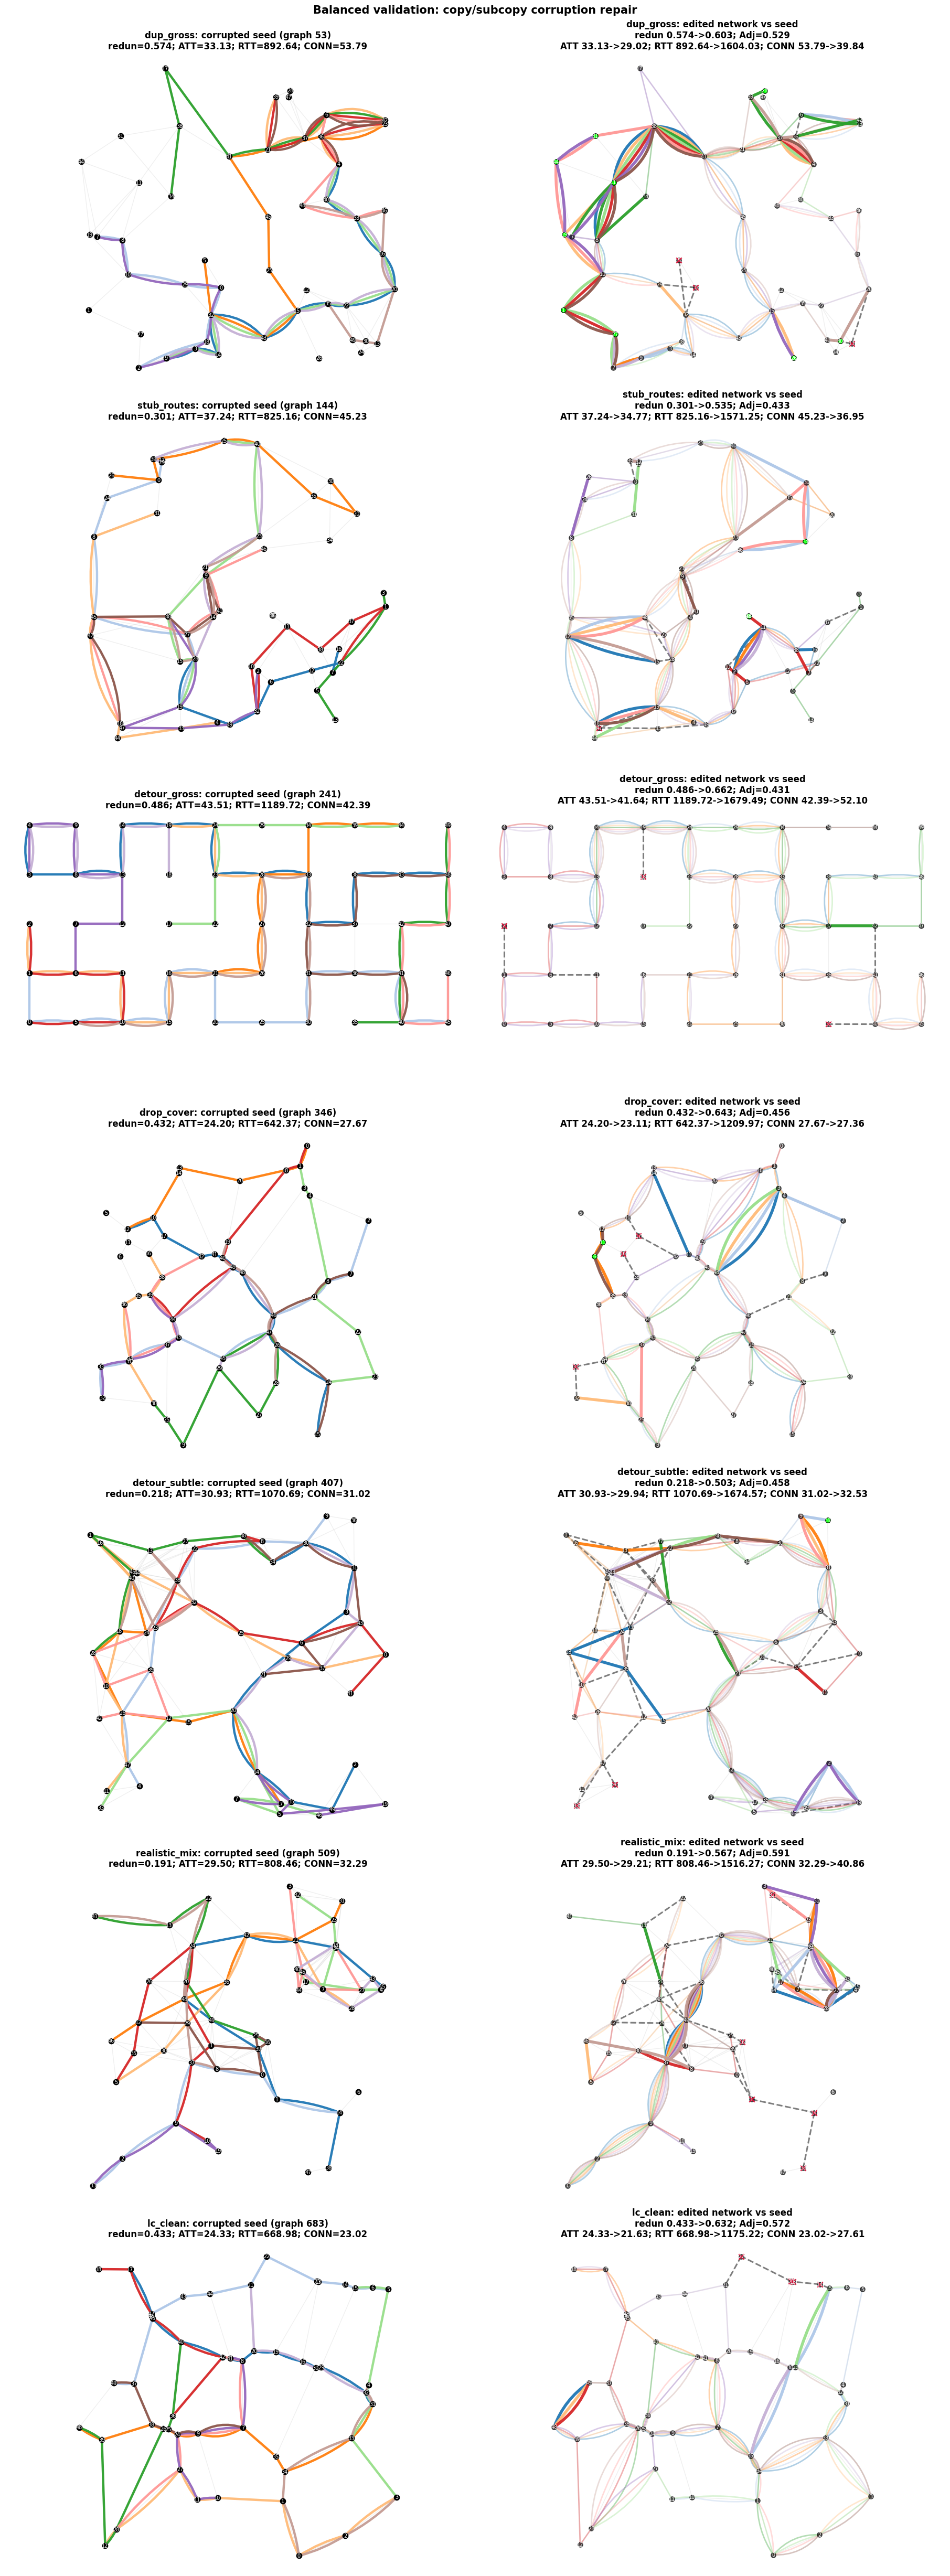

In [ ]:
if RUN_TRAINING:
    if not visual_examples:
        print("Run the evaluation cell first.")
    else:
        tiers_to_plot = [tier for tier in TIERS if tier in visual_examples]
        fig, axes = plt.subplots(
            len(tiers_to_plot), 2,
            figsize=(18, 7 * len(tiers_to_plot)),
            squeeze=False, constrained_layout=True)
        for row_idx, tier in enumerate(tqdm(tiers_to_plot, desc="render tiers")):
            example = visual_examples[tier]
            graph = graphs[example["graph_index"]]
            route_plots.plot_plain_route_set(
                axes[row_idx, 0], example["seed"], graph,
                title=f"{tier}: corrupted seed (graph {example['graph_index']})",
                subtitle=(f"redun={example['redun_before']:.3f}; "
                          f"ATT={example['ATT_before']:.2f}; RTT={example['RTT_before']:.2f}; "
                          f"CONN={example['CONN_before']:.2f}"))
            route_plots.plot_route_diff(
                axes[row_idx, 1], example["improved"], example["seed"], graph,
                title=f"{tier}: edited network vs seed",
                subtitle=(f"redun {example['redun_before']:.3f}->{example['redun_after']:.3f}; "
                          f"Adj={example['Adj']:.3f}\n"
                          f"ATT {example['ATT_before']:.2f}->{example['ATT_after']:.2f}; "
                          f"RTT {example['RTT_before']:.2f}->{example['RTT_after']:.2f}; "
                          f"CONN {example['CONN_before']:.2f}->{example['CONN_after']:.2f}"))
        fig.suptitle("Balanced validation: copy/subcopy corruption repair", fontsize=15, fontweight="bold")
        plt.show()
        plt.close(fig)

## Agent action GIFs

Run the greedy balanced policy step by step for one graph from every tier.
Each GIF starts from the corrupted seed and adds a frame after every agent
action (`extend`, `trim_start`, `trim_end`, or `halt`) with its reward and cost.

In [ ]:
# GIF_OUTPUT_DIR = MODEL_OUTPUTS_DIR / "agent_action_gifs"
# GIF_FPS = 2
# GIF_FORCE_NONHALT_FIRST_STEP = False  # match the balanced eval rollout
# ACTION_NAMES = {
#     ROUTE_ACTION_EXTEND: "extend", ROUTE_ACTION_TRIM_START: "trim_start",
#     ROUTE_ACTION_TRIM_END: "trim_end", ROUTE_ACTION_HALT: "halt",
# }


# def _is_trim_action(action_kind):
#     return int(action_kind) in (ROUTE_ACTION_TRIM_START, ROUTE_ACTION_TRIM_END)


# def _action_text(action_kind, action):
#     action_kind = int(action_kind)
#     name = ACTION_NAMES[action_kind]
#     if action_kind == ROUTE_ACTION_HALT:
#         return name
#     if _is_trim_action(action_kind):
#         return f"{name}(position={int(action[0])})"
#     return f"{name}({int(action[0])} -> {int(action[1])})"


# def _put_route(routes, route_idx, route):
#     routes = routes.clone()
#     routes[:, route_idx] = -1
#     route = route[route > -1].to(routes.device)
#     if route.numel():
#         route_tensor = get_batch_tensor_from_routes(
#             [[route]], routes.device, max_route_len=routes.shape[-1])
#         routes[:, route_idx] = route_tensor[:, 0]
#     return routes


# def _collect_agent_action_frames(graph_index):
#     graph_batch, route_batch = make_improvement_batch(
#         graphs, seed_routes, torch.tensor([graph_index]), device,
#         training=False, target_n_routes=TARGET_N_ROUTES)
#     weights = mkw(*BALANCED_EVAL_WEIGHTS)
#     reward_scale = float(getattr(cfg, "reward_scale", 1.0))
#     diff_reward = bool(getattr(cfg, "diff_reward", True))
#     incumbent_reward = bool(getattr(cfg, "incumbent_reward", False))
#     zero_trim_reward = bool(getattr(cfg, "zero_trim_reward", False))
#     positive_only_trim_reward = bool(getattr(cfg, "positive_only_trim_reward", False))
#     edit_step_penalty = float(getattr(cfg, "edit_step_penalty", 0.0))
#     forced_halt_penalty = float(getattr(cfg, "forced_halt_penalty", 0.0))
#     context_len = max(
#         int(route_batch.shape[-1]), int(MAX_ROUTE_LEN),
#         int(graph_batch[STOP_KEY].num_nodes))
#     working_routes = torch.full(
#         (1, route_batch.shape[1], context_len), -1,
#         dtype=route_batch.dtype, device=device)
#     working_routes[..., :route_batch.shape[-1]] = route_batch
#     display_routes = working_routes.clone()
#     frames = [{"routes": display_routes[0].detach().cpu(), "label": "corrupted seed"}]
#     rows = []

#     model.eval()
#     with torch.no_grad():
#         for route_idx in range(route_batch.shape[1]):
#             context_routes = working_routes.clone()
#             context_routes[:, route_idx] = -1
#             route_state = _make_route_context_state(
#                 cost_obj, graph_batch, working_routes, route_idx,
#                 MIN_ROUTE_LEN, MAX_ROUTE_LEN, weights,
#                 invalid_directly_connected=not bool((context_routes >= 0).any().item()))
#             context_counts = route_state.n_finished_routes.detach().clone()
#             route_state = model.setup_planning(route_state)
#             prev_cost = cost_obj(route_state).cost.detach().clone()
#             trim_count = 0

#             for step_idx in range(MAX_ROUTE_EDIT_STEPS + 1):
#                 if route_state.is_done().all():
#                     break
#                 force_halt = step_idx >= MAX_ROUTE_EDIT_STEPS
#                 trim_allowed = (MAX_TRIM_ACTIONS_PER_ROUTE is None or
#                                 trim_count < int(MAX_TRIM_ACTIONS_PER_ROUTE))
#                 if force_halt:
#                     step_kinds = torch.full((1,), ROUTE_ACTION_HALT, dtype=torch.long, device=device)
#                     step_actions = torch.full((1, 2), -1, dtype=torch.long, device=device)
#                 else:
#                     step_kinds, step_actions, _, _ = model.step_route_action(
#                         route_state, greedy=True,
#                         allow_halt=not (GIF_FORCE_NONHALT_FIRST_STEP and step_idx == 0),
#                         allow_trim_start=trim_allowed, allow_trim_end=trim_allowed)

#                 cost_before = float(prev_cost.cpu()[0])
#                 action_kind = int(step_kinds[0].item())
#                 is_trim = _is_trim_action(action_kind)
#                 route_state.apply_route_actions(step_kinds, step_actions)
#                 planned_route = _get_planned_current_routes(
#                     route_state, working_routes[:, route_idx], context_counts)[0]
#                 frame_routes = _put_route(display_routes, route_idx, planned_route)
#                 new_cost = cost_obj(route_state).cost.detach().clone()
#                 if incumbent_reward:
#                     step_reward = torch.clamp_min(prev_cost - new_cost, 0) * reward_scale
#                 elif diff_reward:
#                     step_reward = (prev_cost - new_cost) * reward_scale
#                 else:
#                     step_reward = torch.zeros_like(new_cost)
#                     if action_kind == ROUTE_ACTION_HALT:
#                         step_reward = -new_cost * reward_scale
#                 if positive_only_trim_reward and is_trim:
#                     step_reward = step_reward.clamp_min(0)
#                 elif zero_trim_reward and is_trim:
#                     step_reward = torch.zeros_like(step_reward)
#                 if action_kind != ROUTE_ACTION_HALT:
#                     step_reward = step_reward - edit_step_penalty
#                 if force_halt:
#                     step_reward = step_reward - forced_halt_penalty
#                 if not (zero_trim_reward and not positive_only_trim_reward and is_trim):
#                     prev_cost = new_cost
#                 trim_count += int(is_trim)

#                 label = (_action_text(action_kind, step_actions[0]) +
#                          f" | reward={float(step_reward.cpu()[0]):+.4f}" +
#                          f" | cost={float(new_cost.cpu()[0]):.4f}")
#                 frames.append({"routes": frame_routes[0].detach().cpu(), "label": label})
#                 rows.append({
#                     "route": route_idx, "step": step_idx + 1,
#                     "action": _action_text(action_kind, step_actions[0]),
#                     "action_kind": ACTION_NAMES[action_kind],
#                     "cost_before": cost_before, "cost_after": float(new_cost.cpu()[0]),
#                     "reward": float(step_reward.cpu()[0]), "forced_halt": force_halt,
#                 })
#                 if action_kind == ROUTE_ACTION_HALT:
#                     break

#             final_route = _get_planned_current_routes(
#                 route_state, working_routes[:, route_idx], context_counts)[0]
#             display_routes = _put_route(display_routes, route_idx, final_route)
#             working_routes = _put_route(working_routes, route_idx, final_route)
#     return frames, pd.DataFrame(rows)


# def save_agent_action_gif(tier, example):
#     frames, steps_df = _collect_agent_action_frames(example["graph_index"])
#     graph = graphs[example["graph_index"]]
#     fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)

#     def _draw(frame_idx):
#         ax.clear()
#         frame = frames[frame_idx]
#         route_plots.plot_route_diff(
#             ax, frame["routes"], example["seed"], graph,
#             title=f"{tier}: greedy balanced actions (graph {example['graph_index']})",
#             subtitle=f"frame {frame_idx + 1}/{len(frames)} | {frame['label']}")
#         return []

#     GIF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#     gif_path = GIF_OUTPUT_DIR / f"{RUN_NAME}_{tier}_agent_actions.gif"
#     animation = FuncAnimation(
#         fig, _draw, frames=len(frames), interval=1000 / GIF_FPS, blit=False)
#     try:
#         animation.save(gif_path, writer=PillowWriter(fps=GIF_FPS))
#         plt.close(fig)
#         display(Image(filename=str(gif_path)))
#     except Exception as exc:
#         plt.close(fig)
#         print(f"{tier}: could not save GIF with PillowWriter: {exc}")
#         fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
#         _draw(len(frames) - 1)
#         plt.show(); plt.close(fig)
#         gif_path = None
#     return gif_path, steps_df


# if not visual_examples:
#     print("Run the evaluation cell first.")
# else:
#     saved_gifs, gif_steps_by_tier = {}, {}
#     for tier in tqdm([tier for tier in TIERS if tier in visual_examples], desc="render GIFs"):
#         gif_path, steps_df = save_agent_action_gif(tier, visual_examples[tier])
#         saved_gifs[tier] = gif_path
#         gif_steps_by_tier[tier] = steps_df
#         save_table(steps_df, f"{RUN_NAME}_{tier}_agent_action_steps")
#         print(f"{tier}: {len(steps_df) + 1} frames -> {gif_path}")
#         display(steps_df.groupby("action_kind")["reward"].agg(["count", "sum", "mean"]).round(4))

---
# PART 2 - BCO experiments (E1-E6)

Uses the model trained above (`BEST_MODEL_PATH`). All baselines are re-run live on a single seed with small budgets.

## Configuration

`SMOKE=True` -> Mandl only, 1 seed, tiny iteration budgets (just checks the
pipeline builds tables/figures). `SMOKE=False` runs Mandl and Mumford0-3
with the 25-30 hour budgeted settings below.


In [ ]:
SMOKE = False
QUICK = False  # minimal budgets/sweeps just to verify the notebook runs end-to-end
CITIES = ["Mandl"] if SMOKE else ["Mandl", "Mumford0", "Mumford1", "Mumford2", "Mumford3"]
SEEDS = [0]                # single seed everywhere
# Unified objective parameters -- SINGLE SOURCE: eval_lib/params.py (also used
# by the PART 1 training config above).
from eval_lib.params import (CONNECTIVITY_MODE, DISABLED_COST_COMPONENTS,
                             UNIFIED_COST_WEIGHTS, ADJ_WEIGHT, ADJ_TARGET,
                             ADJ_OBJECTIVE, ADJ_GAP, ADJ_MODE)
# E1u (unified objective: 0.5*RTT + 0.5*WMC + adj for ALL methods) runs live.
E1U_CITIES = ["Mandl", "Mumford0", "Mumford1"]
# NSGA-II is the heaviest baseline. When False, skip live NSGA-II runs and
# drop any precomputed NSGA-II rows from the comparison CSVs.
RUN_NSGAII_BASELINES = False

# Edit model used by the experiments (training is OFF here). After the new
# from-scratch run finishes, point this at
# "improvement_lc_realistic_scratch_rttwmc_adj_v1.pt".
OUR_MODEL_PATH = EDIT_MODEL_WEIGHTS_DIR / "improvement_lc_rttconn_adj_w10_t02_finetune100.pt"

# BCO edit/trim bees also load the edit model via eval_lib's default path.
# Point it at the same 18-dim (redundancy) checkpoint so it matches the
# bestsofar_feb2023_trim architecture.
import eval_lib.helpers as _eh
_eh.EDIT_MODEL_WEIGHTS_PATH = OUR_MODEL_PATH
# The current finetune100 checkpoint is unconditioned. When switching to the
# new scratch model trained with CONDITION_ON_ADJ_TARGET=True, also set
# _eh.EDIT_MODEL_N_ADJ_COND_FEATS = 1 (the BCO edit bee then receives the
# run's adjustment target as a conditioning feature).
_eh.EDIT_MODEL_N_ADJ_COND_FEATS = 0
# Experiment init for every city = LC construction + covered_dup tier (overridden
# to the LC generator in the helpers cell below); BENCHMARK_INIT_MODE is unused.
import eval_lib.baselines as _eb
_eb.BENCHMARK_INIT_MODE = "nx"
if QUICK:
    _eh.BCO_N_ITERATIONS = 5   # tiny BCO budget for quick sweeps

# Version B of our NBCO (edit model as the REBUILD bee) makes the trim model run a
# full rollout as a constructor -> ~250x slower per BCO iteration (258 s/it vs 1 s/it
# on Mandl, effectively hangs on Mumford). OFF by default; opt-in for Mandl-only probes.
INCLUDE_EDIT_REBUILD = False

# Early stopping OFF: every method runs its full iteration budget so the
# convergence curves below are complete (no premature termination).
EARLY_STOP_PATIENCE = None   # no early stopping (full iteration budget)

# CPU-budgeted full profiles. BCO uses the paper-scale population size
# (10 bees), with reduced-but-not-tiny iteration counts. E2 uses a separate
# BCO budget because the Pareto sweep multiplies runs by grids x models.
DEFAULT_ALGO_SETTINGS = (
    dict(sa=120, hh=120, ga=5, ga_pop=6, nsgaii=(8, 6),
         bco=8, bco_bees=10, sa_args={}, bco_args={})
    if SMOKE else
    dict(sa=15000, hh=15000, ga=500, ga_pop=20, nsgaii=(800, 100),
         bco=500, bco_bees=10, sa_args={}, bco_args={})
)

MANDL_ALGO_SETTINGS = dict(
    sa=(120 if SMOKE else 15000),
    hh=(120 if SMOKE else 15000),
    ga=(5 if SMOKE else 500),
    ga_pop=(6 if SMOKE else 20),
    nsgaii=((8, 6) if SMOKE else (800, 100)),
    bco=(8 if SMOKE else 500),
    bco_bees=10,
    sa_args=dict(initial_temp=0.08, final_temp=0.003, cooling_rate=6.5e-5,
                 reheating_threshold=300, reheating_factor=1.02),
    bco_args=dict(worse_accept_temperature=0.02, worse_accept_decay=0.985,
                  worse_accept_min_temperature=0.001,
                  worse_selection_temperature=0.02,
                  worse_selection_decay=0.985,
                  worse_selection_uniform_mix=0.10,
                  worse_selection_elite_count=2),
)

# SA explores a single network with local moves, so larger graphs need more
# iterations (Mumford1+ stayed ~stuck at the seed with 15k). Scale by city.
SA_ITERS_BY_CITY = {"Mandl": 15000, "Mumford0": 25000, "Mumford1": 40000,
                    "Mumford2": 60000, "Mumford3": 80000}
# HH random-walk init-repair removes covered_dup duplicate-edge violations; on
# Mumford1+ it took ~88k steps. Cap it -- HH penalizes residual violations in
# its optimization loop, so a near-feasible start is enough.
HH_MAX_REPAIR_ITERS = 5000

# E2 is an expensive sweep (alpha x target x models); keep iterations bounded.
E2_BCO_ITERATIONS = 120


def algo_settings(city):
    settings = dict(DEFAULT_ALGO_SETTINGS)
    if city == "Mandl":
        settings.update(MANDL_ALGO_SETTINGS)
    if not (SMOKE or QUICK):
        settings["sa"] = SA_ITERS_BY_CITY.get(city, settings["sa"])
    settings["bco_args"] = dict(DEFAULT_ALGO_SETTINGS.get("bco_args", {}),
                                 **settings.get("bco_args", {}))
    if QUICK:
        settings.update(sa=40, hh=40, ga=5, ga_pop=6, nsgaii=(10, 8),
                        bco=8, bco_bees=10)
    # SA temperature schedule: a LINEAR anneal spanning the FULL (city-specific)
    # iteration budget + periodic reheating, applied to ALL cities. Previously
    # only Mandl was tuned; Mumford used the yaml defaults with NO reheating and
    # a budget-agnostic cooling_rate, so SA could stay stuck at the seed.
    # cost_norm in the SA loop normalizes acceptance by the initial cost, so one
    # schedule transfers across cities (initial cost ~2-3 for every benchmark).
    _sa_n = int(settings["sa"]); _t0, _t1 = 0.15, 0.005
    settings["sa_args"] = dict(
        schedule="linear", initial_temp=_t0, final_temp=_t1,
        cooling_rate=(_t0 - _t1) / max(_sa_n, 1),
        reheating_threshold=max(500, _sa_n // 20), reheating_factor=1.5)
    return settings


print("cities:", CITIES)
print("our model:", OUR_MODEL_PATH.name, "| exists:", OUR_MODEL_PATH.exists())
print("connectivity_mode:", CONNECTIVITY_MODE)
print("disabled cost components:", DISABLED_COST_COMPONENTS)
print("run NSGA-II baselines:", RUN_NSGAII_BASELINES)
print("unified weights (RTT+WMC):", UNIFIED_COST_WEIGHTS,
      "| adj:", f"{ADJ_WEIGHT}*|adj-{ADJ_TARGET}| ({ADJ_OBJECTIVE})")
print("E2 BCO iterations:", E2_BCO_ITERATIONS)

cities: ['Mandl', 'Mumford0', 'Mumford1', 'Mumford2', 'Mumford3']
our model: improvement_lc_rttconn_adj_w10_t02_finetune100.pt | exists: True
connectivity_mode: median_weighted
disabled cost components: ['demand']
run NSGA-II baselines: False
unified weights (RTT+WMC): {'demand_time_weight': 0.0, 'route_time_weight': 0.5, 'median_connectivity_weight': 0.5} | adj: 10.0*|adj-0.2| (target)
E2 BCO iterations: 120


## Shared metrics: adjustment-degree vs seed + redundancy

In [ ]:
from omegaconf import OmegaConf
from tqdm.auto import tqdm

# Generic plumbing lives in eval_lib (paper.py / route_copies.py); this cell
# keeps only the experiment design: per-city budgets, BCO variants, LC init.
from eval_lib.paper import (UNIFIED_ADJ, PAPER_DIR, bco_cfg_set,
                            set_cfg_value as _set_cfg_value,
                            unify_weights as _unify_weights,
                            eval_routes_cfg as _eval_routes_cfg,
                            ravel_hist as _ravel_hist,
                            paper_row as _row, full_metrics as _full_metrics,
                            adj_vs_init, redundancy_pct, conn_metric,
                            save_paper_table, reset_paper_table,
                            append_paper_row, save_paper_fig, save_paper_routes)
from eval_lib.route_copies import (inject_realistic_tier, pad_routes,
                                   uncovered_demand_pct)

# LC init optimizes the same unified objective (RTT + WMC, demand off).
LC_INIT_WEIGHTS = UNIFIED_COST_WEIGHTS


def _sa_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    cfg = build_sa_cfg(run_name, n_routes, min_route_len, max_route_len,
                       n_iterations=s["sa"], early_stop_patience=EARLY_STOP_PATIENCE,
                       connectivity_mode=CONNECTIVITY_MODE)
    for key, value in s.get("sa_args", {}).items():
        _set_cfg_value(cfg, f"alg_args.{key}", value)
    return cfg


def _ga_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    return build_ga_cfg(run_name, n_routes, min_route_len, max_route_len,
                        n_iterations=s["ga"], population_size=s["ga_pop"],
                        early_stop_patience=EARLY_STOP_PATIENCE,
                        connectivity_mode=CONNECTIVITY_MODE)


def _hh_cfg(city, run_name, n_routes, min_route_len, max_route_len):
    s = algo_settings(city)
    return build_hh_cfg(run_name, n_routes, min_route_len, max_route_len,
                        n_iterations=s["hh"], max_repair_iters=HH_MAX_REPAIR_ITERS,
                        early_stop_patience=EARLY_STOP_PATIENCE,
                        connectivity_mode=CONNECTIVITY_MODE)


def _variant_type1_bees(variant, n_bees):
    if variant.get("n_type2_bees") is None and variant.get("n_type1_bees") == BCO_N_TYPE1_BEES:
        return max(1, n_bees // 2)
    return variant["n_type1_bees"]


def _variant_bco_cfg(city, spec, variant, *, weights=UNIFIED_COST_WEIGHTS, run_name_suffix=""):
    s = algo_settings(city)
    n_bees = int(s["bco_bees"])
    cfg = build_bco_cfg(
        run_name=f"{city}_{run_name_suffix}{variant['run_name']}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=variant["use_neural_bees"],
        n_bees=n_bees, n_type1_bees=_variant_type1_bees(variant, n_bees),
        n_type2_bees=variant["n_type2_bees"], n_type4_bees=variant["n_type4_bees"],
        n_type5_bees=variant.get("n_type5_bees", 0),
        n_type6_bees=variant.get("n_type6_bees", 0),
        n_type7_bees=variant.get("n_type7_bees", 0),
        connectivity_mode=CONNECTIVITY_MODE,
        **s.get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    return cfg


# Two versions of our NBCO:
#   use_gnn=True  -> GNN construction bees (type-1) + our trim/extend edit bees (type-5)
#   use_gnn=False -> the GNN constructor is ALSO replaced by our trim/extend model
#                    (all bees type-5); isolates "drop the GNN, rely on our edit model".
# Two versions of our NBCO -- both = half rebuild bees (type-1) + half one-step
# edit bees (type-5). They differ only in WHICH model drives the rebuild bee:
#   use_gnn=True  -> rebuild bee = GNN construction model (standard NBCO)
#   use_gnn=False -> rebuild bee = OUR trim/edit model (rebuild via the edit
#                    model's RL rollout); type-5 is our edit model in both.
OUR_NBCO_VERSIONS = [(True, "GNN rebuild + trim/extend")]
if INCLUDE_EDIT_REBUILD:          # version B is ~250x slower/iter -> opt-in only
    OUR_NBCO_VERSIONS.append((False, "edit-model rebuild + trim/extend"))


def _our_model_cfg(city, spec, *, adj_target=None, run_name_suffix="", seed=None, use_gnn=True):
    s = algo_settings(city)
    n_bees = int(s["bco_bees"])
    rebuild_bees = max(1, n_bees // 2)         # rebuild bees (type-1)
    trim_extend_bees = n_bees - rebuild_bees   # one-step edit bees (type-5)
    if use_gnn:
        bee_arch, bee_w, tag = None, None, "our_nbco_gnn_rebuild_trimext"
    else:
        bee_arch = "bestsofar_feb2023_trim"    # rebuild driven by OUR edit model
        bee_w = str(OUR_MODEL_PATH)
        tag = "our_nbco_editmodel_rebuild_trimext"
    cfg = build_bco_cfg(
        run_name=f"{city}_{run_name_suffix}{tag}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=True,
        n_bees=n_bees, n_type1_bees=rebuild_bees, n_type2_bees=0,
        n_type4_bees=0, n_type5_bees=trim_extend_bees,
        n_type6_bees=0, n_type7_bees=0,
        bee_model_arch=bee_arch, bee_model_weights=bee_w,
        connectivity_mode=CONNECTIVITY_MODE,
        **s.get("bco_args", {}), **UNIFIED_COST_WEIGHTS)
    bco_cfg_set(cfg, n_iterations=s["bco"])
    # type-5 bee must propose an edit (halt collapsed to 73% of eval steps);
    # a bad proposal is simply rejected by BCO acceptance.
    bco_cfg_set(cfg, type5_allow_halt=False)
    if adj_target is not None:
        bco_cfg_set(cfg, **dict(UNIFIED_ADJ,
                                adjustment_degree_target=float(adj_target)))
    if seed is not None:
        _set_cfg_value(cfg, "experiment.seed", int(seed))
    return cfg


# --- experiment init: LC construction base + the REALISTIC corruption tier
#     (eval_lib.route_copies.REALISTIC_TIER_CFG): a couple of street-valid
#     partial duplicates, 1-2 detour routes the agent should straighten, and a
#     few dropped low-demand stops -- instead of the old covered_dup tier that
#     cloned half the network and glued phantom (non-street) legs. ---
import random as _random
LC_INIT_SEED = 0
EXP_INIT_TIER = "realistic"   # tier injected into the experiment init network
_LC_INIT_CACHE = {}


def _lc_base_routes(spec):
    """Clean LC construction routes for a city (no tier corruption)."""
    tensors = load_benchmark_tensors(spec["city"])
    cfg = build_lc_cfg(run_name=f"lc_init_{spec['city']}", n_routes=spec["n_routes"],
                       min_route_len=spec["min_route_len"],
                       max_route_len=spec["max_route_len"],
                       connectivity_mode=CONNECTIVITY_MODE, **LC_INIT_WEIGHTS)
    _set_cfg_value(cfg, "experiment.seed", int(LC_INIT_SEED))
    routes = run_lc(cfg, tensors=tensors, run_name_prefix=f"lc_init_{spec['city']}_", n_samples=1)[3]
    return tensors, pad_routes(routes, spec["n_routes"], spec["max_route_len"])


def load_benchmark_graph(spec, init_mode=None):     # overrides eval_lib.load_benchmark_graph
    city = spec["city"]
    if city not in _LC_INIT_CACHE:
        tensors, clean = _lc_base_routes(spec)
        rng = _random.Random(LC_INIT_SEED)
        init, _applied = inject_realistic_tier(
            clean, rng, spec["min_route_len"], spec["max_route_len"],
            street_adj=tensors["street_adj"], demand=tensors["demand"],
            n_nodes=tensors["node_locs"].shape[0])
        init = as_route_tensor(init)
        if init.ndim == 2:
            init = init[None]                      # -> (1, n_routes, max_len) for runners
        _LC_INIT_CACHE[city] = (tensors, init)
        _dun = uncovered_demand_pct(init[0], tensors["demand"],
                                    tensors["node_locs"].shape[0])
        print(f"[init] {city}: LC base + tier '{EXP_INIT_TIER}' "
              f"({dict(_applied)}) -> redun={redundancy_pct(init):.1f}% "
              f"d_un={_dun:.1f}%")
    return _LC_INIT_CACHE[city]


# 2x2 ablation BCO variant (paper-style: GNN constructor swapped for RPC).
#   construct: "GNN" = neural route-construction rebuild (type-1, use_neural_bees)
#             "RPC" = random path-combiner rebuild (type-3, path_mix_rebuild)
#   edit:     "trim/extend" = our edit-model bee (type-5)
#             "type2"       = old local-endpoint edit (type-2)
ABL_MODELS = ["GNN + trim/extend", "RPC + trim/extend", "GNN + type2", "RPC + type2"]


def abl_variant(construct, edit, n_bees):
    if construct == "none":   # all bees are the edit type (no rebuild bee)
        return {"run_name": f"abl_only_{edit}".replace("/", ""),
                "summary_label": f"{edit} only",
                "use_neural_bees": False,
                "n_type1_bees": 0,
                "n_type2_bees": n_bees if edit == "type2" else 0,
                "n_type4_bees": 0,
                "n_type5_bees": n_bees if edit == "trim/extend" else 0,
                "n_type6_bees": 0, "n_type7_bees": 0}
    half = max(1, n_bees // 2)
    edit_n = n_bees - half
    return {"run_name": f"abl_{construct}_{edit}".replace("/", ""),
            "summary_label": f"{construct} + {edit}",
            "use_neural_bees": construct == "GNN",
            "n_type1_bees": half if construct == "GNN" else 0,
            "n_type2_bees": edit_n if edit == "type2" else 0,
            "n_type4_bees": 0,
            "n_type5_bees": edit_n if edit == "trim/extend" else 0,
            "n_type6_bees": 0, "n_type7_bees": 0}


# Unified objective (RTT + WMC + two-sided |adj-target|) shared by E1u and MACSA.




In [ ]:
# === Mumford0 neural-BCO variants (alpha=0.5, target=0.3, 200 BCO iterations) ===
M0_NBCO_CITY = "Mumford0"
M0_NBCO_ALPHA = 0.5
M0_NBCO_ADJ_TARGET = 0.3
M0_NBCO_ITERS = 200
M0_NBCO_GNN_TRIMEXT_BEES = 10
M0_NBCO_OTHER_BEES = 24
M0_NBCO_TABLE = "final_mumford0_nbco_variants_alpha05_target03_iter200"

M0_NBCO_VARIANTS = [
    dict(method="Our NBCO (GNN + trim/extend)", run_name="gnn_trimextend",
         n_bees=M0_NBCO_GNN_TRIMEXT_BEES,
         use_neural_bees=True, n_type1_bees=5, n_type2_bees=0,
         n_type4_bees=0, n_type5_bees=5, n_type6_bees=0, n_type7_bees=0),
    dict(method="Trim/extend only (24 bees)", run_name="trimextend_only24",
         n_bees=M0_NBCO_OTHER_BEES,
         use_neural_bees=False, n_type1_bees=0, n_type2_bees=0,
         n_type4_bees=0, n_type5_bees=24, n_type6_bees=0, n_type7_bees=0),
    dict(method="Trim 12 + extend 12", run_name="trim12_extend12",
         n_bees=M0_NBCO_OTHER_BEES,
         use_neural_bees=True, n_type1_bees=0, n_type2_bees=0,
         n_type4_bees=12, n_type5_bees=0, n_type6_bees=12, n_type7_bees=0),
]


def _m0_nbco_split(v):
    return (f"n_bees={v['n_bees']}, type1={v['n_type1_bees']}, "
            f"type2={v['n_type2_bees']}, "
            f"type4={v['n_type4_bees']}, type5={v['n_type5_bees']}, "
            f"type6={v['n_type6_bees']}, type7={v['n_type7_bees']}")


def _m0_nbco_cfg(spec, variant, *, seed=None):
    weights = dict(demand_time_weight=0.0,
                   route_time_weight=float(M0_NBCO_ALPHA),
                   median_connectivity_weight=float(1.0 - M0_NBCO_ALPHA))
    cfg = build_bco_cfg(
        run_name=(f"{M0_NBCO_CITY}_nbco_{variant['run_name']}_"
                  f"alpha05_target03_iter200"),
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"],
        use_neural_bees=variant["use_neural_bees"], n_bees=int(variant["n_bees"]),
        n_type1_bees=variant["n_type1_bees"],
        n_type2_bees=variant["n_type2_bees"],
        n_type4_bees=variant["n_type4_bees"],
        n_type5_bees=variant["n_type5_bees"],
        n_type6_bees=variant["n_type6_bees"],
        n_type7_bees=variant["n_type7_bees"],
        connectivity_mode=CONNECTIVITY_MODE,
        **algo_settings(M0_NBCO_CITY).get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=int(M0_NBCO_ITERS))
    bco_cfg_set(cfg, **dict(UNIFIED_ADJ,
                            adjustment_degree_target=float(M0_NBCO_ADJ_TARGET)))
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
    if seed is not None:
        _set_cfg_value(cfg, "experiment.seed", int(seed))
    return cfg


def _m0_eval_routes_cfg(spec, run_name):
    cfg = _unify_weights(_eval_routes_cfg(M0_NBCO_CITY, spec))
    _set_cfg_value(cfg, "run_name", run_name)
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.demand_time_weight", 0.0)
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.route_time_weight",
                   float(M0_NBCO_ALPHA))
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.median_connectivity_weight",
                   float(1.0 - M0_NBCO_ALPHA))
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
    return cfg


def _m0_cost_weights(cost_obj, device):
    weights = {key: (value.clone() if torch.is_tensor(value) else value)
               for key, value in cost_obj.get_weights(device).items()}
    weights["demand_time_weight"] = torch.as_tensor(0.0, device=device)
    weights["route_time_weight"] = torch.as_tensor(float(M0_NBCO_ALPHA), device=device)
    weights["median_connectivity_weight"] = torch.as_tensor(
        float(1.0 - M0_NBCO_ALPHA), device=device)
    return weights


def _run_m0_rl_only(spec, tensors, init_routes):
    """Greedy eval of the trained RL edit agent on the same Mumford0 init."""
    eval_cfg = _m0_eval_routes_cfg(spec, f"{M0_NBCO_CITY}_rl_only_eval")
    dataloader = make_tensor_dataloader(eval_cfg.eval.dataset, tensors)
    device, _run_name, _, cost_obj, _ = lrnu.process_standard_experiment_cfg(
        eval_cfg, run_name_prefix=f"{M0_NBCO_CITY}_rl_only_", weights_required=False)
    cost_obj.use_weighted_connectivity = True
    cost_obj.connectivity_mode = CONNECTIVITY_MODE
    graph_batch = next(iter(dataloader))
    if device.type != "cpu":
        graph_batch = graph_batch.cuda()
    route_batch = as_route_tensor(init_routes).to(device)
    model = build_edit_model(device, weights_path=OUR_MODEL_PATH)
    max_steps = globals().get("MAX_ROUTE_EDIT_STEPS", None)
    max_trims = globals().get("MAX_TRIM_ACTIONS_PER_ROUTE", 1)
    rollout_kwargs = _rollout_adjustment_kwargs_for_model(
        model, target=M0_NBCO_ADJ_TARGET)
    with torch.no_grad():
        output = rollout_lc_improvement(
            model, cost_obj, graph_batch, route_batch,
            spec["min_route_len"], spec["max_route_len"],
            greedy=True, cost_weights=_m0_cost_weights(cost_obj, device),
            return_actions=True, max_route_edit_steps=max_steps,
            max_trim_actions_per_route=max_trims, **rollout_kwargs)
    final_state = output[0]
    route_actions, route_action_kinds = output[5], output[6]
    routes = get_batch_tensor_from_routes(
        final_state.routes, device, max_route_len=spec["max_route_len"])
    action_stats = summarize_route_action_stats(route_actions, route_action_kinds)
    eval_res = _run_baseline(
        None, _m0_eval_routes_cfg(spec, f"{M0_NBCO_CITY}_rl_only_score"),
        routes.detach().cpu(), f"{M0_NBCO_CITY}_rlscore_", {}, tensors=tensors,
        use_weighted_connectivity=True, connectivity_mode=CONNECTIVITY_MODE,
        adjustment_seed_routes=init_routes,
        **dict(UNIFIED_ADJ, adjustment_degree_target=float(M0_NBCO_ADJ_TARGET)))
    return eval_res, action_stats


_m0_spec = next(s for s in BENCHMARK_SPECS if s["city"] == M0_NBCO_CITY)
_m0_tensors, _m0_init = load_benchmark_graph(_m0_spec)
_m0_seed = as_route_tensor(_m0_init)
reset_paper_table(M0_NBCO_TABLE)

M0_NBCO_ROWS = []
M0_NBCO_ROUTES = {f"Initial (LC+{EXP_INIT_TIER})": _m0_seed}
M0_NBCO_HISTORY = {}
M0_NBCO_MUTATION_COUNTS = {}

print(f"=== {M0_NBCO_CITY} NBCO/RL variants: alpha={M0_NBCO_ALPHA}, "
      f"target={M0_NBCO_ADJ_TARGET}, BCO iters={M0_NBCO_ITERS} ===")
for _variant in tqdm(M0_NBCO_VARIANTS, desc=f"{M0_NBCO_CITY} NBCO variants"):
    _label = _variant["method"]
    _history, _mutation_counts = {}, {}
    print(f"  -> {_label} ({_m0_nbco_split(_variant)}) ...", flush=True)
    _t0 = _time.perf_counter()
    try:
        _res = run_bco(
            _m0_nbco_cfg(_m0_spec, _variant, seed=SEEDS[0]), _m0_init,
            mutation_counts_out=_mutation_counts, tensors=_m0_tensors,
            run_name_scope=f"{M0_NBCO_CITY}_", cost_history_out=_history)
        _dt = _time.perf_counter() - _t0
        _routes = as_route_tensor(_res[3])
        _row_out = _row(M0_NBCO_CITY, _label, "mumford0_nbco_variants",
                        _res[1], _routes, _m0_seed, duration_s=_dt)
        _row_out.update(alpha=float(M0_NBCO_ALPHA),
                        adj_target=float(M0_NBCO_ADJ_TARGET),
                        n_iterations=int(M0_NBCO_ITERS),
                        n_bees=int(_variant["n_bees"]),
                        bee_split=_m0_nbco_split(_variant))
        M0_NBCO_ROWS.append(_row_out)
        M0_NBCO_ROUTES[_label] = _routes
        M0_NBCO_HISTORY[_label] = _ravel_hist(_history.get("history"))
        M0_NBCO_MUTATION_COUNTS[_label] = _mutation_counts
        append_paper_row(_row_out, M0_NBCO_TABLE, ndigits=4)
        print(f"  [done] {_label}: RTT={_row_out['RTT']:.0f} "
              f"WMC={_row_out['WMC']:.2f} adj={_row_out['adj_vs_seed']:.2f} "
              f"cost={_row_out['cost']:.4f} ({_dt:.0f}s)", flush=True)
    except Exception as exc:
        print(f"  {M0_NBCO_CITY}/{_label} FAILED: {exc}", flush=True)

print("  -> RL only (greedy edit-agent eval) ...", flush=True)
_t0 = _time.perf_counter()
try:
    _rl_res, _rl_action_stats = _run_m0_rl_only(_m0_spec, _m0_tensors, _m0_init)
    _dt = _time.perf_counter() - _t0
    _rl_routes = as_route_tensor(_rl_res[3])
    _rl_row = _row(M0_NBCO_CITY, "RL only", "mumford0_rl_only_eval",
                  _rl_res[1], _rl_routes, _m0_seed, duration_s=_dt)
    _rl_row.update(alpha=float(M0_NBCO_ALPHA),
                   adj_target=float(M0_NBCO_ADJ_TARGET),
                   n_iterations=None, n_bees=None,
                   bee_split="RL greedy rollout; no BCO population")
    M0_NBCO_ROWS.append(_rl_row)
    M0_NBCO_ROUTES["RL only"] = _rl_routes
    M0_NBCO_HISTORY["RL only"] = []
    M0_NBCO_MUTATION_COUNTS["RL only"] = _rl_action_stats
    append_paper_row(_rl_row, M0_NBCO_TABLE, ndigits=4)
    print(f"  [done] RL only: RTT={_rl_row['RTT']:.0f} "
          f"WMC={_rl_row['WMC']:.2f} adj={_rl_row['adj_vs_seed']:.2f} "
          f"cost={_rl_row['cost']:.4f} ({_dt:.0f}s)", flush=True)
except Exception as exc:
    print(f"  {M0_NBCO_CITY}/RL only FAILED: {exc}", flush=True)

M0_NBCO_VARIANTS_DF = pd.DataFrame(M0_NBCO_ROWS).round(4)
if not M0_NBCO_VARIANTS_DF.empty:
    display(M0_NBCO_VARIANTS_DF)
    save_paper_table(M0_NBCO_VARIANTS_DF, M0_NBCO_TABLE)
    save_paper_routes(M0_NBCO_TABLE, M0_NBCO_ROUTES,
                      _m0_tensors["node_locs"], _m0_tensors["street_adj"],
                      meta={"city": M0_NBCO_CITY,
                            "objective": "alpha*RTT + (1-alpha)*WMC + adj",
                            "alpha": M0_NBCO_ALPHA,
                            "adj_target": M0_NBCO_ADJ_TARGET,
                            "n_iterations": M0_NBCO_ITERS,
                            "gnn_trimextend_bees": M0_NBCO_GNN_TRIMEXT_BEES,
                            "other_bco_bees": M0_NBCO_OTHER_BEES,
                            "connectivity_mode": CONNECTIVITY_MODE,
                            "init_tier": EXP_INIT_TIER})
    torch.save(M0_NBCO_HISTORY, PAPER_DIR / f"{M0_NBCO_TABLE}_history.pt")
    torch.save(M0_NBCO_MUTATION_COUNTS,
               PAPER_DIR / f"{M0_NBCO_TABLE}_mutation_counts.pt")
    print(f"[paper] histories/mutation counts -> {PAPER_DIR / (M0_NBCO_TABLE + '_history.pt')}")

    _viz_items = list(M0_NBCO_ROUTES.items())
    _fig, _axes = plt.subplots(2, len(_viz_items),
                               figsize=(4.2 * len(_viz_items), 8.2),
                               squeeze=False)
    _coords = _m0_tensors["node_locs"]
    _street_adj = _m0_tensors["street_adj"]
    _demand = _m0_tensors["demand"]
    _ref_routes = M0_NBCO_ROUTES[f"Initial (LC+{EXP_INIT_TIER})"]
    for _col, (_label, _routes) in enumerate(_viz_items):
        _short = (_label.replace("Our NBCO ", "")
                         .replace(" (GNN + trim/extend)", "GNN+trim/extend"))
        route_plots.plot_plain_route_set(
            _axes[0, _col], _routes, _coords, _street_adj,
            title=_short, subtitle="routes", palette="tab20")
        if _col == 0:
            route_plots.plot_demand_graph(
                _axes[1, _col], _demand, _coords, _street_adj,
                title="OD demand", subtitle="bottom row: diff vs init",
                top_frac=0.20)
        else:
            route_plots.plot_route_diff(
                _axes[1, _col], _routes, _ref_routes, _coords, _street_adj,
                title=_short, subtitle="diff vs init", palette="tab20")
    _fig.suptitle(f"{M0_NBCO_CITY}: NBCO/RL variants, alpha={M0_NBCO_ALPHA}, "
                  f"target={M0_NBCO_ADJ_TARGET}", y=1.02, fontsize=15)
    plt.tight_layout()
    save_paper_fig(_fig, f"{M0_NBCO_TABLE}_routes")
    plt.show()
    plt.close(_fig)
else:
    print("No successful Mumford0 NBCO variant runs.")


KeyboardInterrupt: 

## E2 - Pareto fronts on RTT x WMC (Mumford0, covered_dup tier)

Both panels run on **Mumford0** from the **covered_dup** init tier (removable
redundancy), optimizing `alpha*RTT + (1-alpha)*WMC + adj(|.-target|)` with
`use_weighted_connectivity=True`. `alpha` = `route_time_weight` (so alpha=1 ->
pure RTT, alpha=0 -> pure WMC).

- **Fig 1 (our model):** RTT x WMC Pareto front of `GNN + trim/extend`, swept
  over `alpha` x `adj_target` (one curve per target).
- **Fig 2 (4-model comparison):** `{GNN, RPC} x {trim/extend, type2}`, alpha-
  swept at a fixed `adj_target=ADJ_TARGET` -> shows the trim/extend
  bee's contribution to the RTT x WMC front.

In [ ]:
# === E2 -- Pareto fronts on RTT x WMC (Mumford0, covered_dup init tier) ===
E2_CITY = "Mumford0" if not SMOKE else "Mandl"
E2_ALPHA_GRID = [0.0, 0.5, 1.0] if not SMOKE else [0.0, 0.5, 1.0]
E2_TARGET_GRID = [0.2, 0.6, 1.0] if not SMOKE else [0.0, 0.2]
E2_FIX_TARGET = min(E2_TARGET_GRID, key=lambda _t: abs(_t - 0.2))  # alpha-slice target
E2_FIX_ALPHA = min(E2_ALPHA_GRID, key=lambda _a: abs(_a - 0.5))    # target-slice alpha
E2_FIXED_TARGET = 1.0     # adj target for the 4-model comparison


In [ ]:
def _e2_ctx():
    spec = next(s for s in BENCHMARK_SPECS if s["city"] == E2_CITY)
    tensors, init = load_benchmark_graph(spec)
    s = algo_settings(E2_CITY)
    return dict(city=E2_CITY, spec=spec, tensors=tensors, init=init,
                nb=int(s["bco_bees"]), settings=s)


def _run_rttwmc(ctx, construct, edit, *, alpha, adj_target, tag, seed=None,
                adj_weight=None):
    """One BCO run optimizing alpha*RTT + (1-alpha)*WMC + adj(|.-target|).

    ``adj_weight=0.0`` disables the adjustment penalty entirely (the
    Holliday-style control: acceptance driven purely by alpha*RTT+(1-a)*WMC).
    """
    var = abl_variant(construct, edit, ctx["nb"])
    spec = ctx["spec"]
    weights = {"demand_time_weight": 0.0, "route_time_weight": float(alpha),
               "median_connectivity_weight": float(1.0 - alpha)}
    cfg = build_bco_cfg(
        run_name=f"{ctx['city']}_{tag}_{var['run_name']}",
        n_routes=spec["n_routes"], min_route_len=spec["min_route_len"],
        max_route_len=spec["max_route_len"], use_neural_bees=var["use_neural_bees"],
        n_bees=ctx["nb"], n_type1_bees=var["n_type1_bees"], n_type2_bees=var["n_type2_bees"],
        n_type4_bees=0, n_type5_bees=var["n_type5_bees"], n_type6_bees=0, n_type7_bees=0,
        connectivity_mode=CONNECTIVITY_MODE,
        **ctx["settings"].get("bco_args", {}), **weights)
    bco_cfg_set(cfg, n_iterations=int(E2_BCO_ITERATIONS))
    _adj = dict(UNIFIED_ADJ, adjustment_degree_target=float(adj_target))
    if adj_weight is not None:
        _adj["adjustment_degree_weight"] = float(adj_weight)
    bco_cfg_set(cfg, **_adj)
    # type-5 bee must propose an edit (halt collapsed to 73% of eval steps);
    # a bad proposal is simply rejected by BCO acceptance.
    bco_cfg_set(cfg, type5_allow_halt=False)
    _set_cfg_value(cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
    if seed is not None:
        _set_cfg_value(cfg, "experiment.seed", int(seed))
    t = _time.perf_counter()
    res = run_bco(cfg, ctx["init"], tensors=ctx["tensors"], run_name_scope=f"{ctx['city']}_")
    duration_s = _time.perf_counter() - t
    return res[3], res[1], duration_s


def _e2_row(ctx, series_col, label, alpha, target, routes, metrics, duration_s=None):
    rt = as_route_tensor(routes)
    return {"city": ctx["city"], series_col: label, "alpha": float(alpha),
            "adj_target": float(target),
            "duration_s": (round(float(duration_s), 1) if duration_s is not None else None),
            **_full_metrics(metrics, rt, ctx["init"])}


_AXIS_LABEL = {"RTT": "RTT (lower = better)", "WMC": "WMC (lower = better)",
              "rtt_cost": "normalized RTT cost (lower = better)",
              "wmc_cost": "normalized WMC cost (lower = better)",
              "adj_vs_seed": "adjustment degree vs seed (lower = less change)"}


def _plot_fronts(df, series_col, title, save_name, xcol="RTT", ycol="WMC"):
    fig, ax = plt.subplots(figsize=(8, 6))
    for lab, sub in df.groupby(series_col):
        sub = sub.sort_values(xcol)
        ax.plot(sub[xcol], sub[ycol], marker="o", alpha=0.85, label=str(lab))
        for _, r in sub.iterrows():
            tag = f"a={r['alpha']:g}"
            if "adj_target" in r and pd.notna(r["adj_target"]):
                tag += f",t={r['adj_target']:g}"
            ax.annotate(tag, (r[xcol], r[ycol]), fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords="offset points")
    ax.set_xlabel(_AXIS_LABEL.get(xcol, xcol)); ax.set_ylabel(_AXIS_LABEL.get(ycol, ycol))
    ax.set_title(title); ax.legend(title=series_col); ax.grid(alpha=0.3)
    save_paper_fig(fig, save_name); plt.show(); plt.close(fig)


_ctx = _e2_ctx()
_sfx = "_smoke" if SMOKE else ""
print(f"=== E2 Pareto fronts on RTT x WMC ({E2_CITY}, tier={EXP_INIT_TIER}) ===")

# --- Fig 1: OUR model (GNN + trim/extend), Pareto over alpha x target ---
_e2_our_table = f"final_e2_ourpareto_{E2_CITY}{_sfx}"
reset_paper_table(_e2_our_table)
def _e2_route_key(alpha, target):
    return f"target={float(target):g} | alpha={float(alpha):g}"


_our_rows = []
_our_routes = {f"Initial (LC+{EXP_INIT_TIER})": _ctx["init"]}
for _t in tqdm(E2_TARGET_GRID, desc=f"E2 {E2_CITY} our-model targets"):
    for _a in E2_ALPHA_GRID:
        try:
            r, m, dt = _run_rttwmc(_ctx, "GNN", "trim/extend", alpha=_a, adj_target=_t,
                               tag=f"our_a{_a}_t{_t}", seed=SEEDS[0])
            row = _e2_row(_ctx, "adj_target", f"target={_t:g}", _a, _t, r, m, duration_s=dt)
            row["objective"] = f"RTT_x_{CONNECTIVITY_MODE}"
            _our_rows.append(row)
            _our_routes[_e2_route_key(_a, _t)] = as_route_tensor(r)
            append_paper_row(row, _e2_our_table, ndigits=4)
        except Exception as exc:
            print(f"  our alpha={_a} target={_t} FAILED: {exc}")
E2_OUR_DF = pd.DataFrame(_our_rows)
if not E2_OUR_DF.empty:
    display(E2_OUR_DF.round(4))
    save_paper_table(E2_OUR_DF.round(4), _e2_our_table)
    save_paper_routes(_e2_our_table, _our_routes,
                      _ctx["tensors"]["node_locs"], _ctx["tensors"]["street_adj"],
                      meta={"city": E2_CITY, "objective": "E2 alpha x target",
                            "connectivity_mode": CONNECTIVITY_MODE,
                            "init_tier": EXP_INIT_TIER})
    # (1) combined: one curve per adj_target, each curve = alpha sweep
    _plot_fronts(E2_OUR_DF, "adj_target",
                 f"E2 ({E2_CITY}): our model RTT x WMC -- alpha x target (combined)",
                 f"final_e2_ourpareto_combined_{E2_CITY}{_sfx}")
    # (1b) SAME data on adj x RTT axes -- makes the target sweep (which moves the
    # deviation, not RTT/WMC directly) visible: points spread along the adj axis.
    _plot_fronts(E2_OUR_DF, "adj_target",
                 f"E2 ({E2_CITY}): our model adj x RTT -- alpha x target",
                 f"final_e2_ourpareto_adjrtt_{E2_CITY}{_sfx}",
                 xcol="adj_vs_seed", ycol="RTT")
    # (2) alpha sweep at a fixed adj target
    _alpha_slice = E2_OUR_DF[np.isclose(E2_OUR_DF["adj_target"], E2_FIX_TARGET)]
    if not _alpha_slice.empty:
        _plot_fronts(_alpha_slice, "adj_target",
                     f"E2 ({E2_CITY}): alpha sweep on RTT x WMC (target={E2_FIX_TARGET:g} fixed)",
                     f"final_e2_alphasweep_{E2_CITY}{_sfx}")
    # (3) adj-target sweep at a fixed alpha
    _target_slice = E2_OUR_DF[np.isclose(E2_OUR_DF["alpha"], E2_FIX_ALPHA)]
    if not _target_slice.empty:
        _plot_fronts(_target_slice, "alpha",
                     f"E2 ({E2_CITY}): adj-target sweep on RTT x WMC (alpha={E2_FIX_ALPHA:g} fixed)",
                     f"final_e2_targetsweep_{E2_CITY}{_sfx}")


=== E2 Pareto fronts on RTT x WMC (Mumford0, tier=realistic) ===


E2 Mumford0 our-model targets:   0%|          | 0/3 [00:00<?, ?it/s]

[Mumford0_our_a0.0_t0.2_abl_GNN_trimextend] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


  2%|▏         | 2/120 [00:04<04:53,  2.49s/it]


KeyboardInterrupt: 

In [ ]:
# --- Fig 2: 4-model comparison, alpha-swept at fixed adj target ---
_e2_abl_table = f"final_e2_4model_{E2_CITY}{_sfx}"
reset_paper_table(_e2_abl_table)
_abl_rows = []
for _mdl in tqdm(ABL_MODELS + ["trim/extend only"], desc=f"E2 {E2_CITY} model alpha sweep"):
    _c, _e = ("none", "trim/extend") if _mdl == "trim/extend only" else _mdl.split(" + ")
    for _a in E2_ALPHA_GRID:
        try:
            r, m, dt = _run_rttwmc(_ctx, _c, _e, alpha=_a, adj_target=E2_FIXED_TARGET,
                               tag=f"abl_a{_a}".replace(".", ""), seed=SEEDS[0])
            row = _e2_row(_ctx, "model", _mdl, _a, E2_FIXED_TARGET, r, m, duration_s=dt)
            _abl_rows.append(row)
            append_paper_row(row, _e2_abl_table, ndigits=4)
        except Exception as exc:
            print(f"  {_mdl} alpha={_a} FAILED: {exc}")
E2_ABL_DF = pd.DataFrame(_abl_rows)
if not E2_ABL_DF.empty:
    display(E2_ABL_DF.round(4))
    save_paper_table(E2_ABL_DF.round(4), _e2_abl_table)
    _plot_fronts(E2_ABL_DF, "model",
                 f"E2 ({E2_CITY}): model RTT x WMC fronts (alpha sweep @ target={E2_FIXED_TARGET:g})",
                 f"final_e2_4model_{E2_CITY}{_sfx}")
print(f"[E2] {E2_CITY}: our-model alpha x target front + model alpha sweep (incl. trim/extend-only) done.")


E2 Mumford0 model alpha sweep:   0%|          | 0/5 [00:00<?, ?it/s]

[Mumford0_abl_a00_abl_GNN_trimextend] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


100%|██████████| 120/120 [04:00<00:00,  2.00s/it]

,12.000,0.588,16.600,902.000,56.038,42.240,1.721,0.000,0.000,0.000,16.967,15.290,240.577,121.000
[paper] row -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e2_4model_Mumford0.csv


[Mumford0_abl_a05_abl_GNN_trimextend] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


 57%|█████▋    | 68/120 [02:36<01:59,  2.30s/it]


KeyboardInterrupt: 

### E2-control: GNN vs RPC rebuild WITHOUT the adjustment penalty

Holliday-style check that separates "weak constructor" from "E2 setup
artifact": with `adj_weight=0` the acceptance is pure
`alpha*RTT + (1-alpha)*WMC`, exactly like the paper's NBCO-vs-unlearned
comparison. If the learned GNN constructor really is better than the random
path-combiner (RPC), the gap must show HERE; if they are still equal, the
constructor itself is the bottleneck (undertrained / out-of-distribution),
not the `|adj-target|`-dominated E2 objective.

In [ ]:
# === E2-control -- {GNN, RPC} + trim/extend at adj_weight=0 (no adj penalty) ===
E2_CTRL_MODELS = ["GNN + trim/extend", "RPC + trim/extend"]
_e2_ctrl_table = "final_e2_control_noadj_" + E2_CITY + ("_smoke" if SMOKE else "")
reset_paper_table(_e2_ctrl_table)
_ctx = _e2_ctx()
_e2c_rows = []
for _label in E2_CTRL_MODELS:
    _construct, _edit = _label.split(" + ")
    for _alpha in E2_ALPHA_GRID:
        r, m, dt = _run_rttwmc(_ctx, _construct, _edit, alpha=_alpha,
                               adj_target=ADJ_TARGET, adj_weight=0.0,
                               tag=f"e2ctrl_a{_alpha}")
        row = _e2_row(_ctx, "model", _label, _alpha, float("nan"), r, m, dt)
        _e2c_rows.append(row)
        append_paper_row(row, _e2_ctrl_table, ndigits=4)
        print(f"[E2-ctrl] {_label:18} alpha={_alpha}: RTT={row['RTT']:.0f} "
              f"WMC={row['WMC']:.3f} cost={row['cost']:.4f} ({dt:.0f}s)", flush=True)

_e2c_df = pd.DataFrame(_e2c_rows).round(4)
display(_e2c_df)
save_paper_table(_e2c_df, _e2_ctrl_table)
# side-by-side: same-alpha GNN vs RPC deltas (negative = GNN better)
_p = _e2c_df.pivot_table(index="alpha", columns="model", values="cost")
_p["GNN_minus_RPC"] = (_p["GNN + trim/extend"] - _p["RPC + trim/extend"]).round(4)
display(_p)
if not _e2c_df.empty:
    _plot_fronts(_e2c_df, "model",
                 f"E2-control ({E2_CITY}): GNN vs RPC no-adj Pareto front",
                 f"final_e2_control_noadj_front_{E2_CITY}{_sfx}",
                 xcol="rtt_cost", ycol="wmc_cost")
print("E2-control: no-adj acceptance; a consistently negative GNN_minus_RPC "
      "column reproduces Holliday's learned-constructor advantage.")

[Mumford0_e2ctrl_a0.0_abl_GNN_trimextend] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


100%|██████████| 120/120 [03:36<00:00,  1.81s/it]

,12.000,0.560,15.936,1058.000,60.562,38.567,0.871,0.000,0.000,0.000,16.333,14.560,216.737,121.000
[paper] row -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e2_control_noadj_Mumford0.csv
[E2-ctrl] GNN + trim/extend  alpha=0.0: RTT=1058 WMC=14.560 cost=0.5600 (217s)


[Mumford0_e2ctrl_a0.5_abl_GNN_trimextend] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


100%|██████████| 120/120 [03:40<00:00,  1.84s/it]

...

,12.000,0.808,43.420,252.000,13.801,21.239,20.482,44.479,0.000,0.000,41.900,41.377,572.951,121.000
[paper] row -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e2_control_noadj_Mumford0.csv
[E2-ctrl] RPC + trim/extend  alpha=1.0: RTT=252 WMC=41.377 cost=0.8077 (573s)


,city,model,alpha,adj_target,duration_s,ATT,RTT,WMC,WMC_mean,WMC_median,adj_vs_seed,rtt_cost,wmc_cost,cost,d0,d1,d2,d_un,redun%
0,Mumford0,GNN + trim/extend,0.0,NaN,216.9,15.9357,1058.0,14.5598,15.8397,14.5598,0.2398,3.3910,0.5600,0.5600,60.5623,38.5668,0.8709,0.0000,36.3636
1,Mumford0,GNN + trim/extend,0.5,NaN,220.5,23.5773,250.0,22.5018,23.4027,22.5018,0.3899,0.8013,0.8655,0.8334,17.4597,43.1932,30.9680,8.3791,0.0000
2,Mumford0,GNN + trim/extend,1.0,NaN,257.4,30.4876,256.0,29.9698,30.3003,29.9698,0.3562,0.8205,1.1527,0.8205,18.2897,33.8263,26.8880,20.9960,6.4516
3,Mumford0,RPC + trim/extend,0.0,NaN,482.3,15.5072,1228.0,14.1233,15.4169,14.1233,0.6371,3.9359,0.5432,0.5432,63.8064,36.1936,0.0000,0.0000,42.5373
4,Mumford0,RPC + trim/extend,0.5,NaN,544.3,21.2994,302.0,20.3930,21.1558,20.3930,0.5758,0.9679,0.7843,0.8761,21.6945,50.2250,22.3404,5.7400,5.1282
5,Mumford0,RPC + trim/extend,1.0,NaN,573.3,43.4201,252.0,41.3770,43.2496,41.3770,0.3990,0.8077,1.5914,0.8077,13.8006,21.2386,20.4816,44.4792,0.0000


[paper] table (6 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_e2_control_noadj_Mumford0.csv


model,GNN + trim/extend,RPC + trim/extend,GNN_minus_RPC
alpha,,,
0.0,0.5600,0.5432,0.0168
0.5,0.8334,0.8761,-0.0427
1.0,0.8205,0.8077,0.0128


E2-control: no-adj acceptance; a consistently negative GNN_minus_RPC column reproduces Holliday's learned-constructor advantage.


### E2 Route Visualisation

Draw selected `alpha x adj_target` route sets from the E2 our-model sweep. The first grid shows the route sets directly; the second grid highlights changes against the LC initial network.

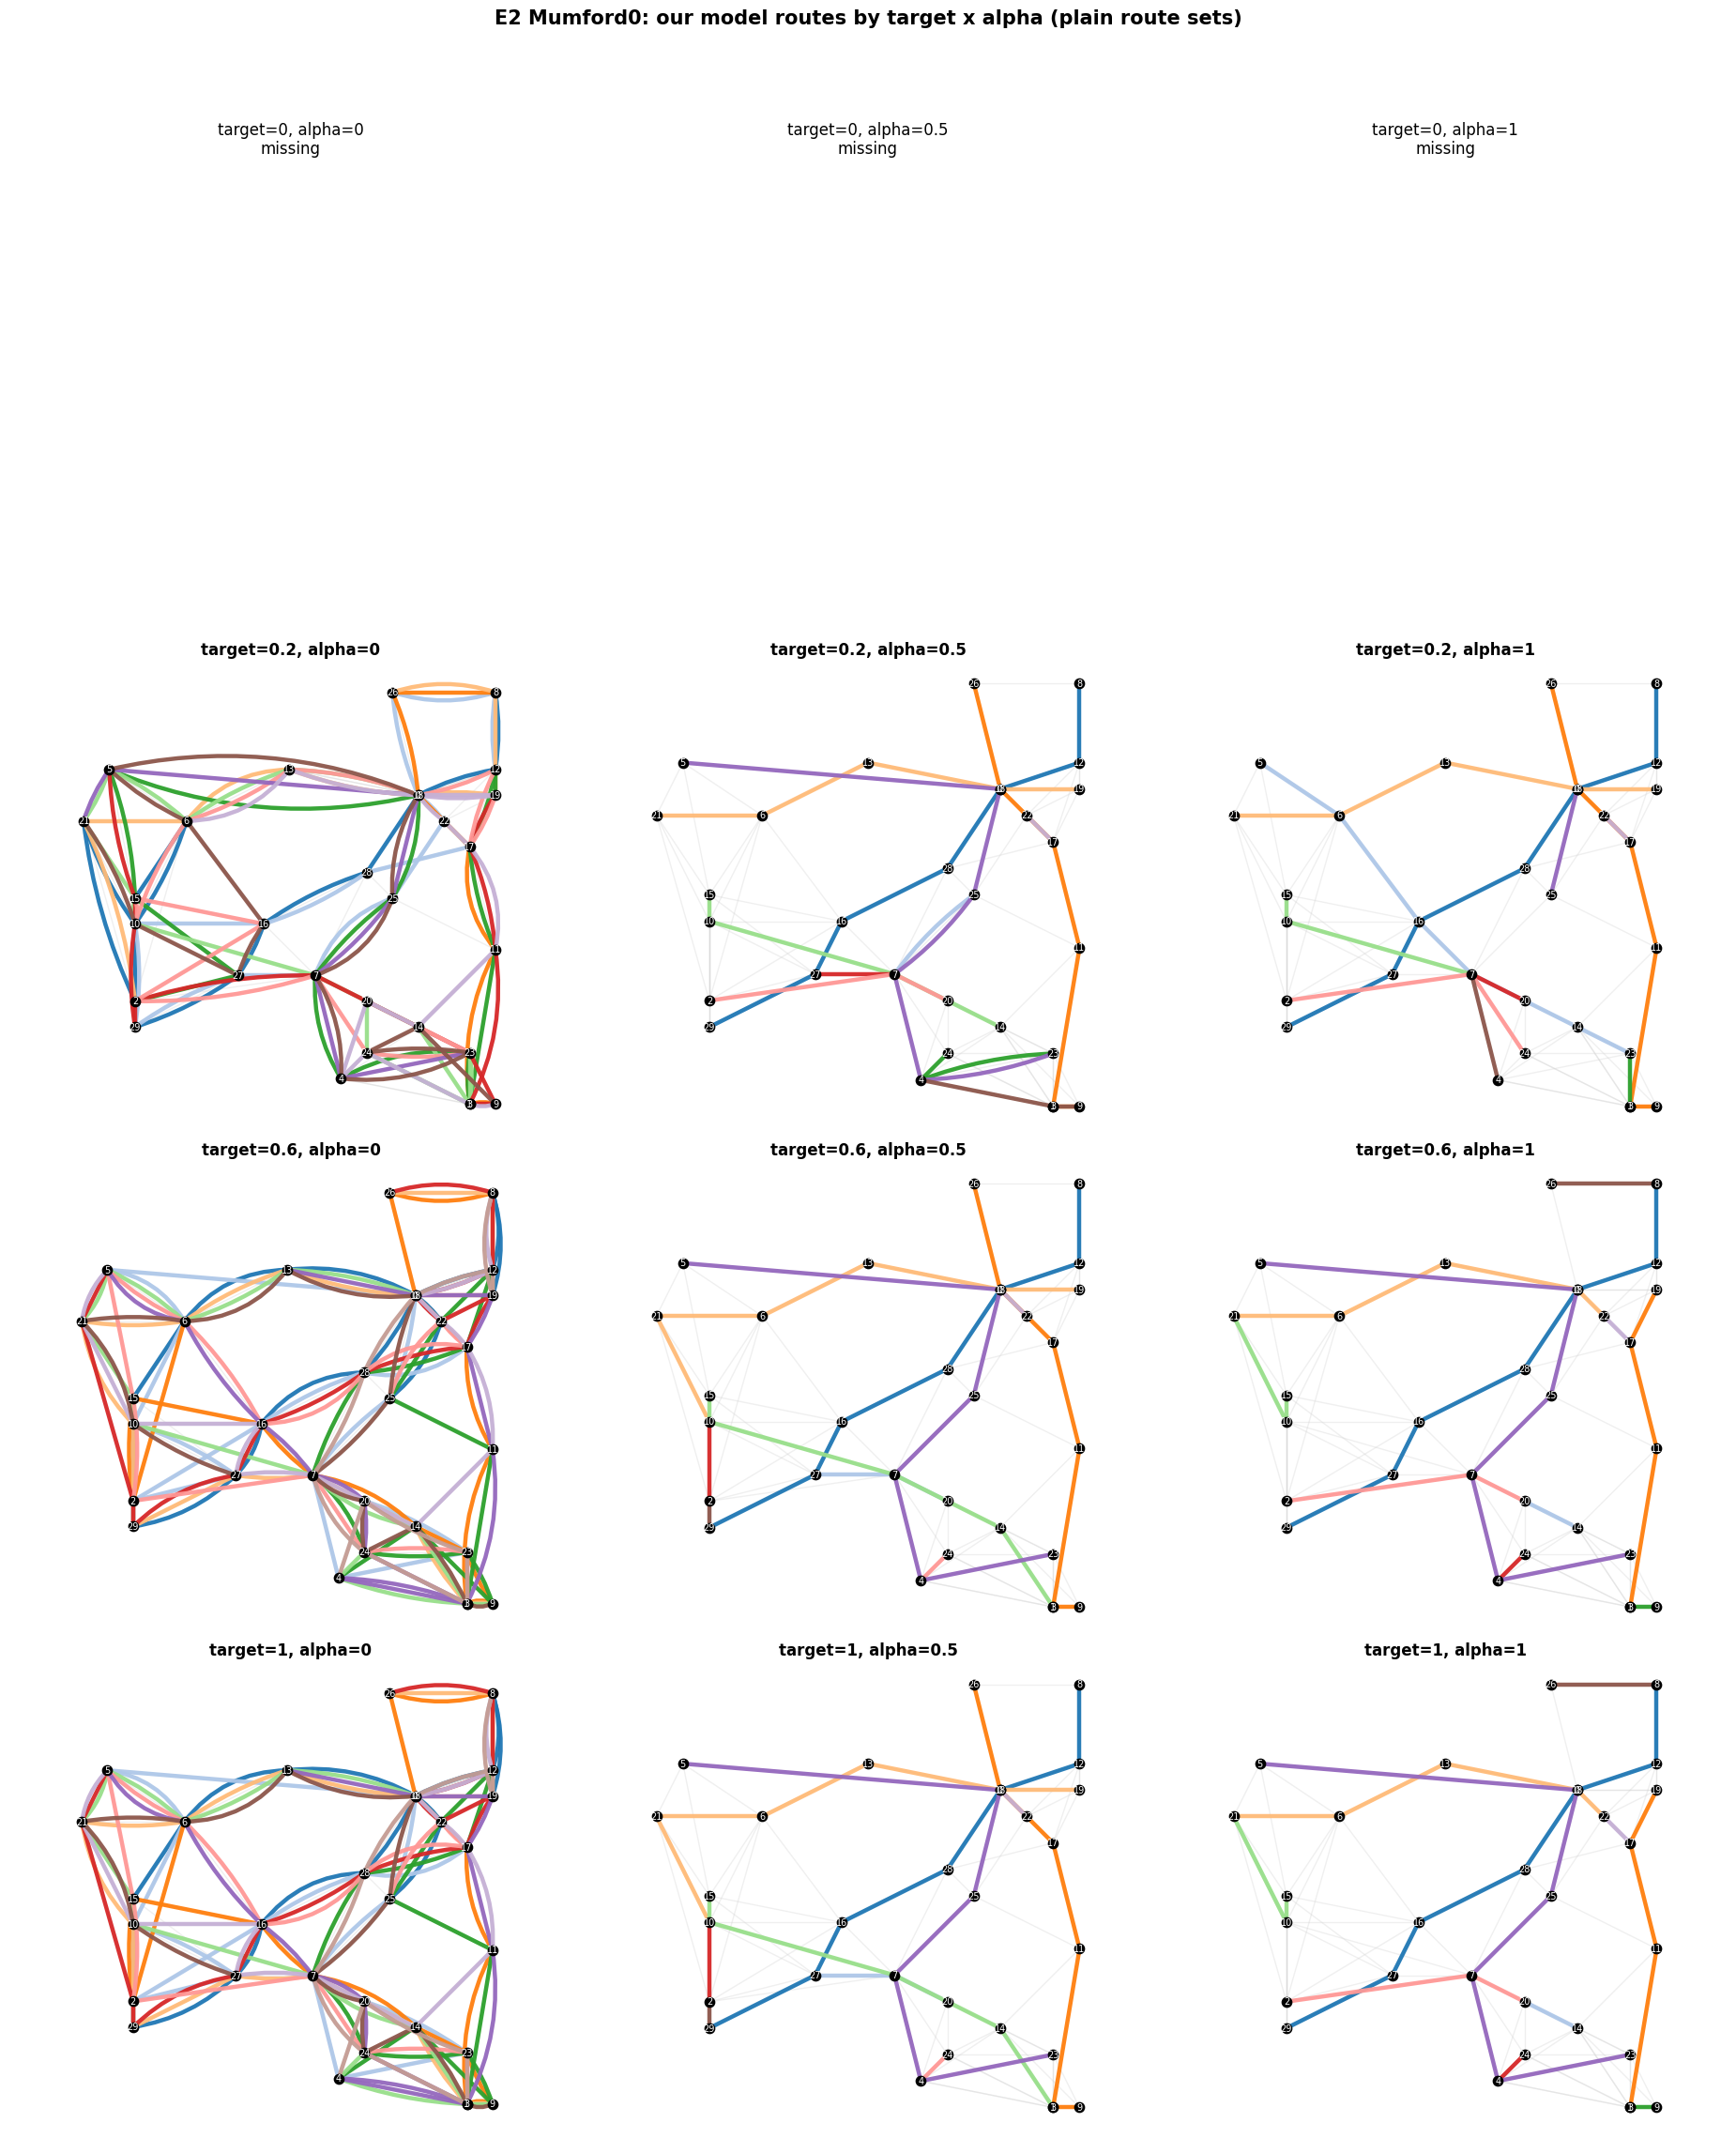

missing 3 route sets: ['target=0 | alpha=0', 'target=0 | alpha=0.5', 'target=0 | alpha=1']


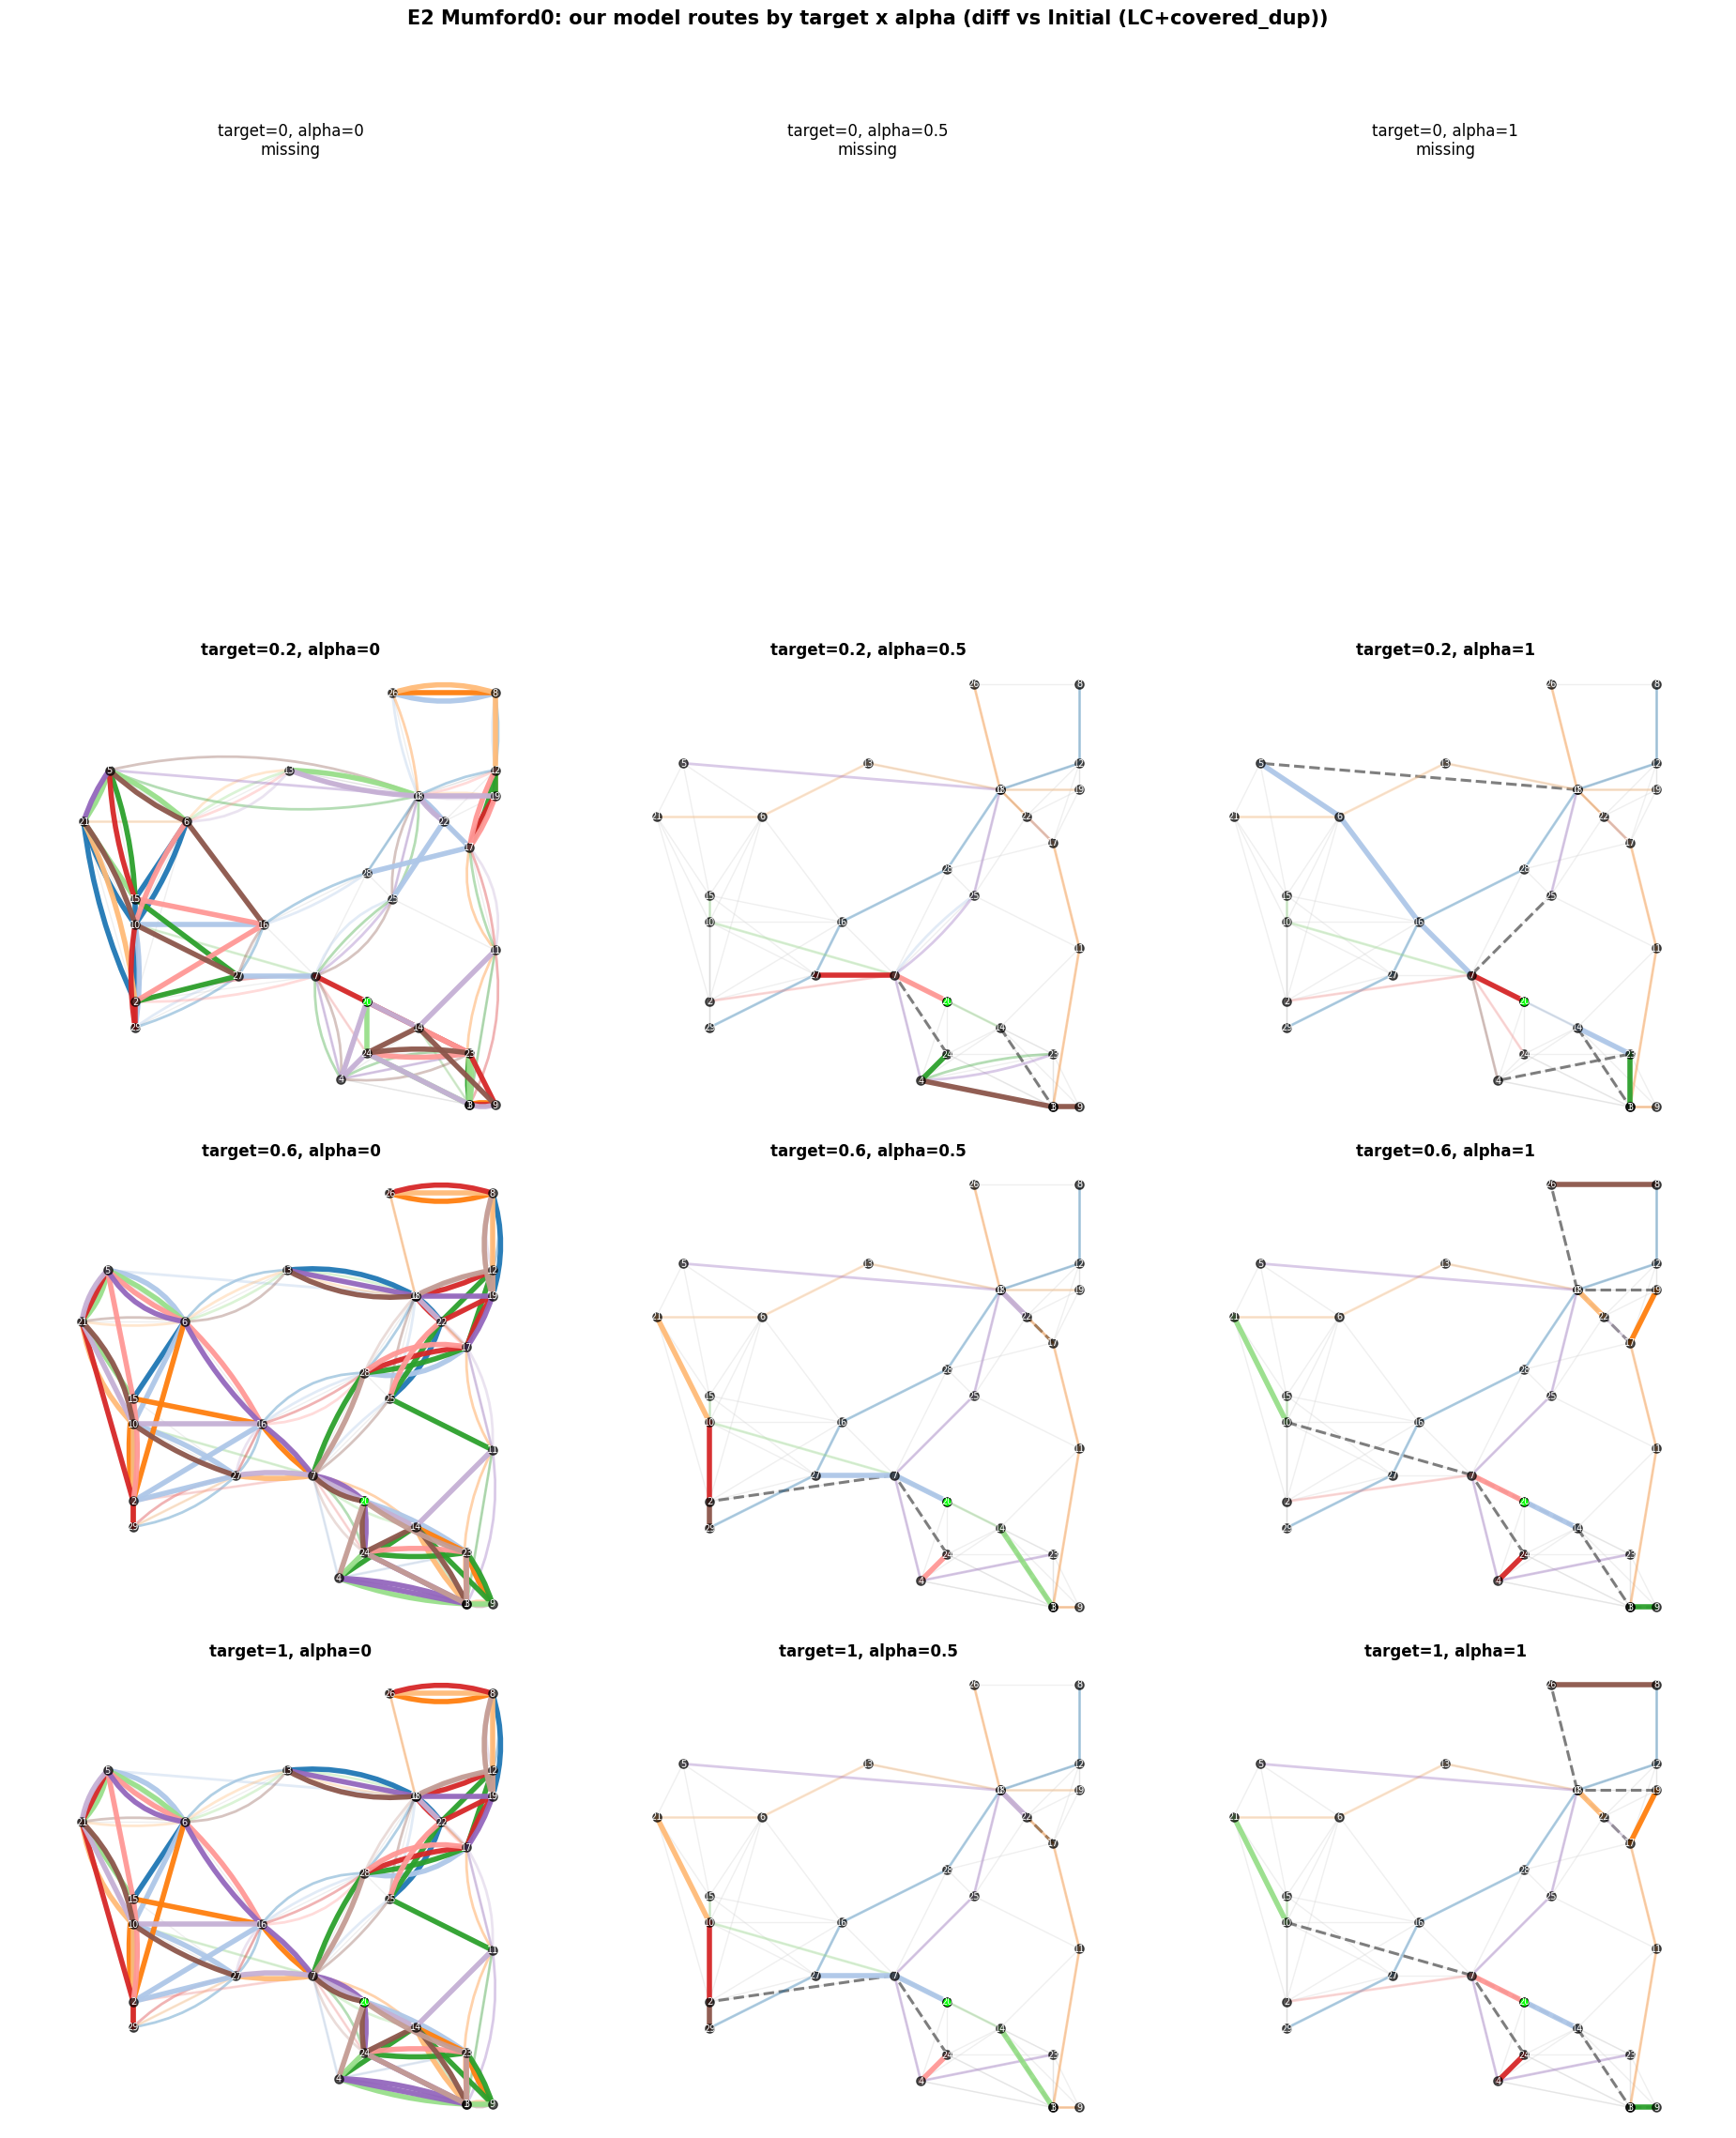

missing 3 route sets: ['target=0 | alpha=0', 'target=0 | alpha=0.5', 'target=0 | alpha=1']
E2 route visualisation drawn from final_e2_ourpareto_Mumford0_routes.pt; ref='Initial (LC+covered_dup)'


In [ ]:
# Visualise E2 our-model routes for selected alpha x target combinations.
# Run the E2 cell above first so final_e2_ourpareto_<city>_routes.pt exists.
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from eval_lib import plots as route_plots

E2_VIZ_CITY = E2_CITY
E2_VIZ_ALPHAS = [0.0, 0.5, 1.0]
E2_VIZ_TARGETS = [0.0, 0.2, 0.6, 1.0]
E2_VIZ_OVERLAP_CURVES = True
E2_VIZ_SHOW_DIFF = True

_e2_viz_sfx = "_smoke" if globals().get("SMOKE", False) else ""
_e2_viz_table = f"final_e2_ourpareto_{E2_VIZ_CITY}{_e2_viz_sfx}"
_e2_viz_routes_path = PAPER_DIR / f"{_e2_viz_table}_routes.pt"
_e2_viz_csv_path = PAPER_DIR / f"{_e2_viz_table}.csv"
assert _e2_viz_routes_path.exists(), (
    f"no E2 route dump: {_e2_viz_routes_path}; run the E2 cell above first")

_e2_dump = torch.load(_e2_viz_routes_path, weights_only=False)
_e2_routes = _e2_dump["routes"]
_e2_coords = _e2_dump["coords"]
_e2_adj = _e2_dump["street_adj"]
_e2_ref_key = next((k for k in _e2_routes if str(k).startswith("Initial")), list(_e2_routes)[0])
_e2_ref_rt = as_route_tensor(_e2_routes[_e2_ref_key])
_e2_ref_rr = _e2_ref_rt[0] if _e2_ref_rt.ndim == 3 else _e2_ref_rt

_e2_viz_df = pd.read_csv(_e2_viz_csv_path) if _e2_viz_csv_path.exists() else pd.DataFrame()
if not _e2_viz_df.empty:
    _e2_viz_df["alpha"] = pd.to_numeric(_e2_viz_df["alpha"], errors="coerce")
    _e2_viz_df["adj_target"] = pd.to_numeric(_e2_viz_df["adj_target"], errors="coerce")


def _e2_viz_key(alpha, target):
    return f"target={float(target):g} | alpha={float(alpha):g}"


def _e2_select_values(col, preferred):
    if _e2_viz_df.empty or col not in _e2_viz_df:
        return preferred
    available = sorted(float(v) for v in _e2_viz_df[col].dropna().unique())
    selected = [float(v) for v in preferred if any(np.isclose(v, a) for a in available)]
    return selected or available[:min(4, len(available))]


_e2_plot_alphas = _e2_select_values("alpha", E2_VIZ_ALPHAS)
_e2_plot_targets = _e2_select_values("adj_target", E2_VIZ_TARGETS)


def _e2_metric_subtitle(alpha, target):
    if _e2_viz_df.empty:
        return ""
    mask = (np.isclose(_e2_viz_df["alpha"], float(alpha)) &
            np.isclose(_e2_viz_df["adj_target"], float(target)))
    if not mask.any():
        return ""
    row = _e2_viz_df.loc[mask].iloc[0]
    return (f"RTT={row['RTT']:.0f}  WMC={row['WMC']:.2f}  adj={row['adj_vs_seed']:.2f}\n"
            f"d_un={row['d_un']:.1f}%  redun={row['redun%']:.0f}%")


def _draw_e2_route_grid(diff=False):
    if not _e2_plot_alphas or not _e2_plot_targets:
        print("No E2 alpha/target values available for plotting.")
        return
    fig, axes = plt.subplots(
        len(_e2_plot_targets), len(_e2_plot_alphas),
        figsize=(6.2 * len(_e2_plot_alphas), 5.8 * len(_e2_plot_targets)),
        squeeze=False)
    missing = []
    for row_idx, target in enumerate(_e2_plot_targets):
        for col_idx, alpha in enumerate(_e2_plot_alphas):
            ax = axes[row_idx, col_idx]
            key = _e2_viz_key(alpha, target)
            if key not in _e2_routes:
                ax.axis("off")
                ax.set_title(f"target={target:g}, alpha={alpha:g}\nmissing")
                missing.append(key)
                continue
            rt = as_route_tensor(_e2_routes[key])
            rr = rt[0] if rt.ndim == 3 else rt
            title = f"target={target:g}, alpha={alpha:g}"
            subtitle = _e2_metric_subtitle(alpha, target)
            if diff:
                route_plots.plot_route_diff(
                    ax, rr, _e2_ref_rr, _e2_coords, _e2_adj, title=title,
                    subtitle=subtitle, palette="tab20",
                    with_overlap_curves=E2_VIZ_OVERLAP_CURVES)
            else:
                route_plots.plot_plain_route_set(
                    ax, rr, _e2_coords, _e2_adj, title=title,
                    subtitle=subtitle, palette="tab20",
                    with_overlap_curves=E2_VIZ_OVERLAP_CURVES)
    mode = f"diff vs {_e2_ref_key}" if diff else "plain route sets"
    fig.suptitle(f"E2 {E2_VIZ_CITY}: our model routes by target x alpha ({mode})",
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show(); plt.close(fig)
    if missing:
        print(f"missing {len(missing)} route sets:", missing[:8])


if not _e2_viz_df.empty:
    _e2_display = _e2_viz_df[
        _e2_viz_df["alpha"].apply(lambda x: any(np.isclose(x, a) for a in _e2_plot_alphas)) &
        _e2_viz_df["adj_target"].apply(lambda x: any(np.isclose(x, t) for t in _e2_plot_targets))
    ]
    display(_e2_display.round(4))

_draw_e2_route_grid(diff=False)
if E2_VIZ_SHOW_DIFF:
    _draw_e2_route_grid(diff=True)
print(f"E2 route visualisation drawn from {_e2_viz_routes_path.name}; ref={_e2_ref_key!r}")


## E1u - Unified objective: ALL methods optimize 0.5*RTT + 0.5*WMC + adj

Every enabled method (SA / GA / HH / optional NSGA-II / BCO / neural BCO / our model) runs on the
**same** unified objective: route time + weighted mean connectivity + the
adjustment-degree penalty (two-sided |adj-target| @ `ADJ_TARGET`, weight `ADJ_WEIGHT`).
This is the apples-to-apples comparison; E1 above is the legacy ATT/RTT baseline.
Cities: `E1U_CITIES` (Mandl + Mumford0 + Mumford1). Tables ->
`paper_results/final_main_unified_<city>.csv`.

In [ ]:
import torch


def run_city_unified(spec, table_name=None, comparison_table_name=None):
    city = spec["city"]
    nr, mn, mx = spec["n_routes"], spec["min_route_len"], spec["max_route_len"]
    tensors, init = load_benchmark_graph(spec)
    seed = as_route_tensor(init)
    rows, routes, conv = [], {}, {}

    def add(method, m, rt, dt=None, hist=None):
        rt = as_route_tensor(rt)
        row = _row(city, method, "unified", m, rt, seed, duration_s=dt)
        rows.append(row); routes[method] = rt
        if table_name is not None:
            append_paper_row(row, table_name, ndigits=3)
        if comparison_table_name is not None:
            append_paper_row(row, comparison_table_name, ndigits=3)
        if hist is not None:
            conv[method] = _ravel_hist(hist)
        tail = f"  ({dt:.0f}s)" if dt is not None else ""
        print(f"  [done] {method:34} RTT={row['RTT']:.0f} WMC={row['WMC']:.2f} "
              f"adj={row['adj_vs_seed']:.2f} cost={row['cost']:.3f} "
              f"redun={row['redun%']:.0f}%{tail}", flush=True)

    def run_one(name, fn):
        print(f"  -> {name} ...", flush=True)
        t = _time.perf_counter()
        try:
            return fn(), _time.perf_counter() - t
        except Exception as exc:
            print(f"  {city}/{name} FAILED: {exc}", flush=True); return None, None

    r, dt = run_one(f"Initial (LC+{EXP_INIT_TIER})", lambda: _run_baseline(
        None, _unify_weights(_eval_routes_cfg(city, spec)), init,
        f"{city}_uini_", {}, tensors=tensors, use_weighted_connectivity=True))
    if r is not None:
        add(f"Initial (LC+{EXP_INIT_TIER})", r[1], r[3], dt)

    for name, builder in [
        ("Simulated annealing", lambda: run_sa(
            _unify_weights(_sa_cfg(city, f"{city}_usa", nr, mn, mx)), init, tensors=tensors,
            run_name_scope=f"{city}_u", use_weighted_connectivity=True,
            return_history=True, **UNIFIED_ADJ)),
        ("Genetic algorithm", lambda: run_ga(
            _unify_weights(_ga_cfg(city, f"{city}_uga", nr, mn, mx)), init, tensors=tensors,
            run_name_scope=f"{city}_u", use_weighted_connectivity=True,
            return_history=True, **UNIFIED_ADJ)),
        ("Hyper-heuristics", lambda: run_hh(
            _unify_weights(_hh_cfg(city, f"{city}_uhh", nr, mn, mx)), init, tensors=tensors,
            run_name_scope=f"{city}_u", use_weighted_connectivity=True,
            return_history=True, **UNIFIED_ADJ)),
    ]:
        r, dt = run_one(name, builder)
        if r is not None:
            _h = r[-1]
            add(name, r[1], r[3], dt,
                hist=(_h[0] if (_h is not None and len(_h) > 0) else None))

    for label, vkey in [("BCO", "seeded_heuristic"), ("neural BCO", "seeded_neural")]:
        v = next(x for x in BCO_VARIANTS if x["key"] == vkey)
        ch = {}

        def _bco(v=v, ch=ch):
            cfg = _variant_bco_cfg(city, spec, v, weights=UNIFIED_COST_WEIGHTS, run_name_suffix="uni_")
            bco_cfg_set(cfg, **UNIFIED_ADJ)
            _set_cfg_value(cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
            return run_bco(cfg, init, tensors=tensors, run_name_scope=f"{city}_",
                           cost_history_out=ch)
        r, dt = run_one(label, _bco)
        if r is not None:
            add(label, r[1], r[3], dt, hist=ch.get("history"))

    if RUN_NSGAII_BASELINES:
        def _nsga():
            it, pop = algo_settings(city)["nsgaii"]
            _, out = run_nsgaii(build_nsgaii_cfg(f"{city}_unsgaii", nr, mn, mx,
                                n_iterations=it, pop_size=pop,
                                connectivity_mode=CONNECTIVITY_MODE),
                                tensors=tensors, init_routes=init, run_name_scope=f"{city}_u",
                                use_weighted_connectivity=True,
                                connectivity_mode=CONNECTIVITY_MODE, **UNIFIED_ADJ)
            best = reduce_pareto_front(out, 0.5, 0.5)   # objectives are (RTT, WMC)
            rr = best["routes"]; rr = rr[None] if rr.ndim == 2 else rr
            return _run_baseline(None, _unify_weights(_eval_routes_cfg(city, spec)), rr,
                                 f"{city}_unsga_eval_", {}, tensors=tensors,
                                 use_weighted_connectivity=True,
                                 adjustment_seed_routes=init, **UNIFIED_ADJ)
        r, dt = run_one("NSGA-II", _nsga)
        if r is not None:
            add("NSGA-II", r[1], r[3], dt)
    else:
        print("  [skip] NSGA-II", flush=True)

    # our model already optimizes the unified objective (RTT + WMC + adj |.-target|)
    for _ug, _lbl in OUR_NBCO_VERSIONS:
        method = f"Our NBCO ({_lbl})"
        ch = {}
        r, dt = run_one(method, lambda ug=_ug, ch=ch: run_bco(
            _our_model_cfg(city, spec, adj_target=ADJ_TARGET, seed=SEEDS[0], use_gnn=ug),
            init, tensors=tensors, run_name_scope=f"{city}_", cost_history_out=ch))
        if r is not None:
            add(method, r[1], r[3], dt, hist=ch.get("history"))
    return rows, routes, tensors, init, conv


u_all_rows = []
_sfx = "_smoke" if SMOKE else ""
_e1u_comparison_table = "final_main_unified_comparison" + _sfx
if E1U_CITIES:
    reset_paper_table(_e1u_comparison_table)
for spec in [s for s in BENCHMARK_SPECS if s["city"] in E1U_CITIES]:
    print(f"=== {spec['city']} UNIFIED (all methods on 0.5*RTT+0.5*WMC+adj) ===", flush=True)
    _city_table = f"final_main_unified_{spec['city']}{_sfx}"
    reset_paper_table(_city_table)
    rows, routes, tensors, init, conv = run_city_unified(
        spec, table_name=_city_table, comparison_table_name=_e1u_comparison_table)
    u_all_rows += rows
    save_paper_table(pd.DataFrame(rows).round(3), _city_table)
    save_paper_routes(_city_table, routes,
                      tensors["node_locs"], tensors["street_adj"],
                      meta={"city": spec["city"], "objective": "unified"})
    torch.save(conv, PAPER_DIR / f"final_main_unified_{spec['city']}{_sfx}_history.pt")
    print(f"[paper] cost histories ({len(conv)} methods) -> "
          f"final_main_unified_{spec['city']}{_sfx}_history.pt", flush=True)
    print(f"=== {spec['city']} unified done ({len(rows)} methods) ===", flush=True)

unified_df = pd.DataFrame(u_all_rows).round(3)
if not RUN_NSGAII_BASELINES and not unified_df.empty:
    unified_df = unified_df[unified_df["method"] != "NSGA-II"].reset_index(drop=True)
display(unified_df)
save_paper_table(unified_df, _e1u_comparison_table)
print("E1u: every method optimized 0.5*RTT + 0.5*WMC + adj(|.-target|@%.2f); "
      "tables/route dumps/histories -> paper_results/final_main_unified_*." % ADJ_TARGET)


=== Mandl UNIFIED (all methods on 0.5*RTT+0.5*WMC+adj) ===
[init] Mandl: LC base + tier 'covered_dup' -> redun=61.3%
  -> Initial (LC+covered_dup) ...
,6.000,2.791,17.183,342.000,54.528,22.608,15.093,7.771,20.000,0.000,17.692,17.447,0.010,0.000
[paper] row -> D:\PythonProjects\connectpt\artifacts\paper_results\final_main_unified_Mandl.csv
[paper] row -> D:\PythonProjects\connectpt\artifacts\paper_results\final_main_unified_comparison.csv
  [done] Initial (LC+covered_dup)           RTT=342 WMC=17.45 adj=0.00 cost=2.791 redun=61%  (0s)
  -> Simulated annealing ...


  2%|▏         | 334/15000 [00:03<02:43, 89.55it/s]


KeyboardInterrupt: 

### Route visualisation (unified run: RTT + WMC + adj for all methods)

Drawn from the **unified** dumps (`final_main_unified_<city>`). Layout: OD demand -> init -> methods (plain & diff vs init), plus a focused 1x4 (our routes / init / neural-BCO diff / our-NBCO diff).

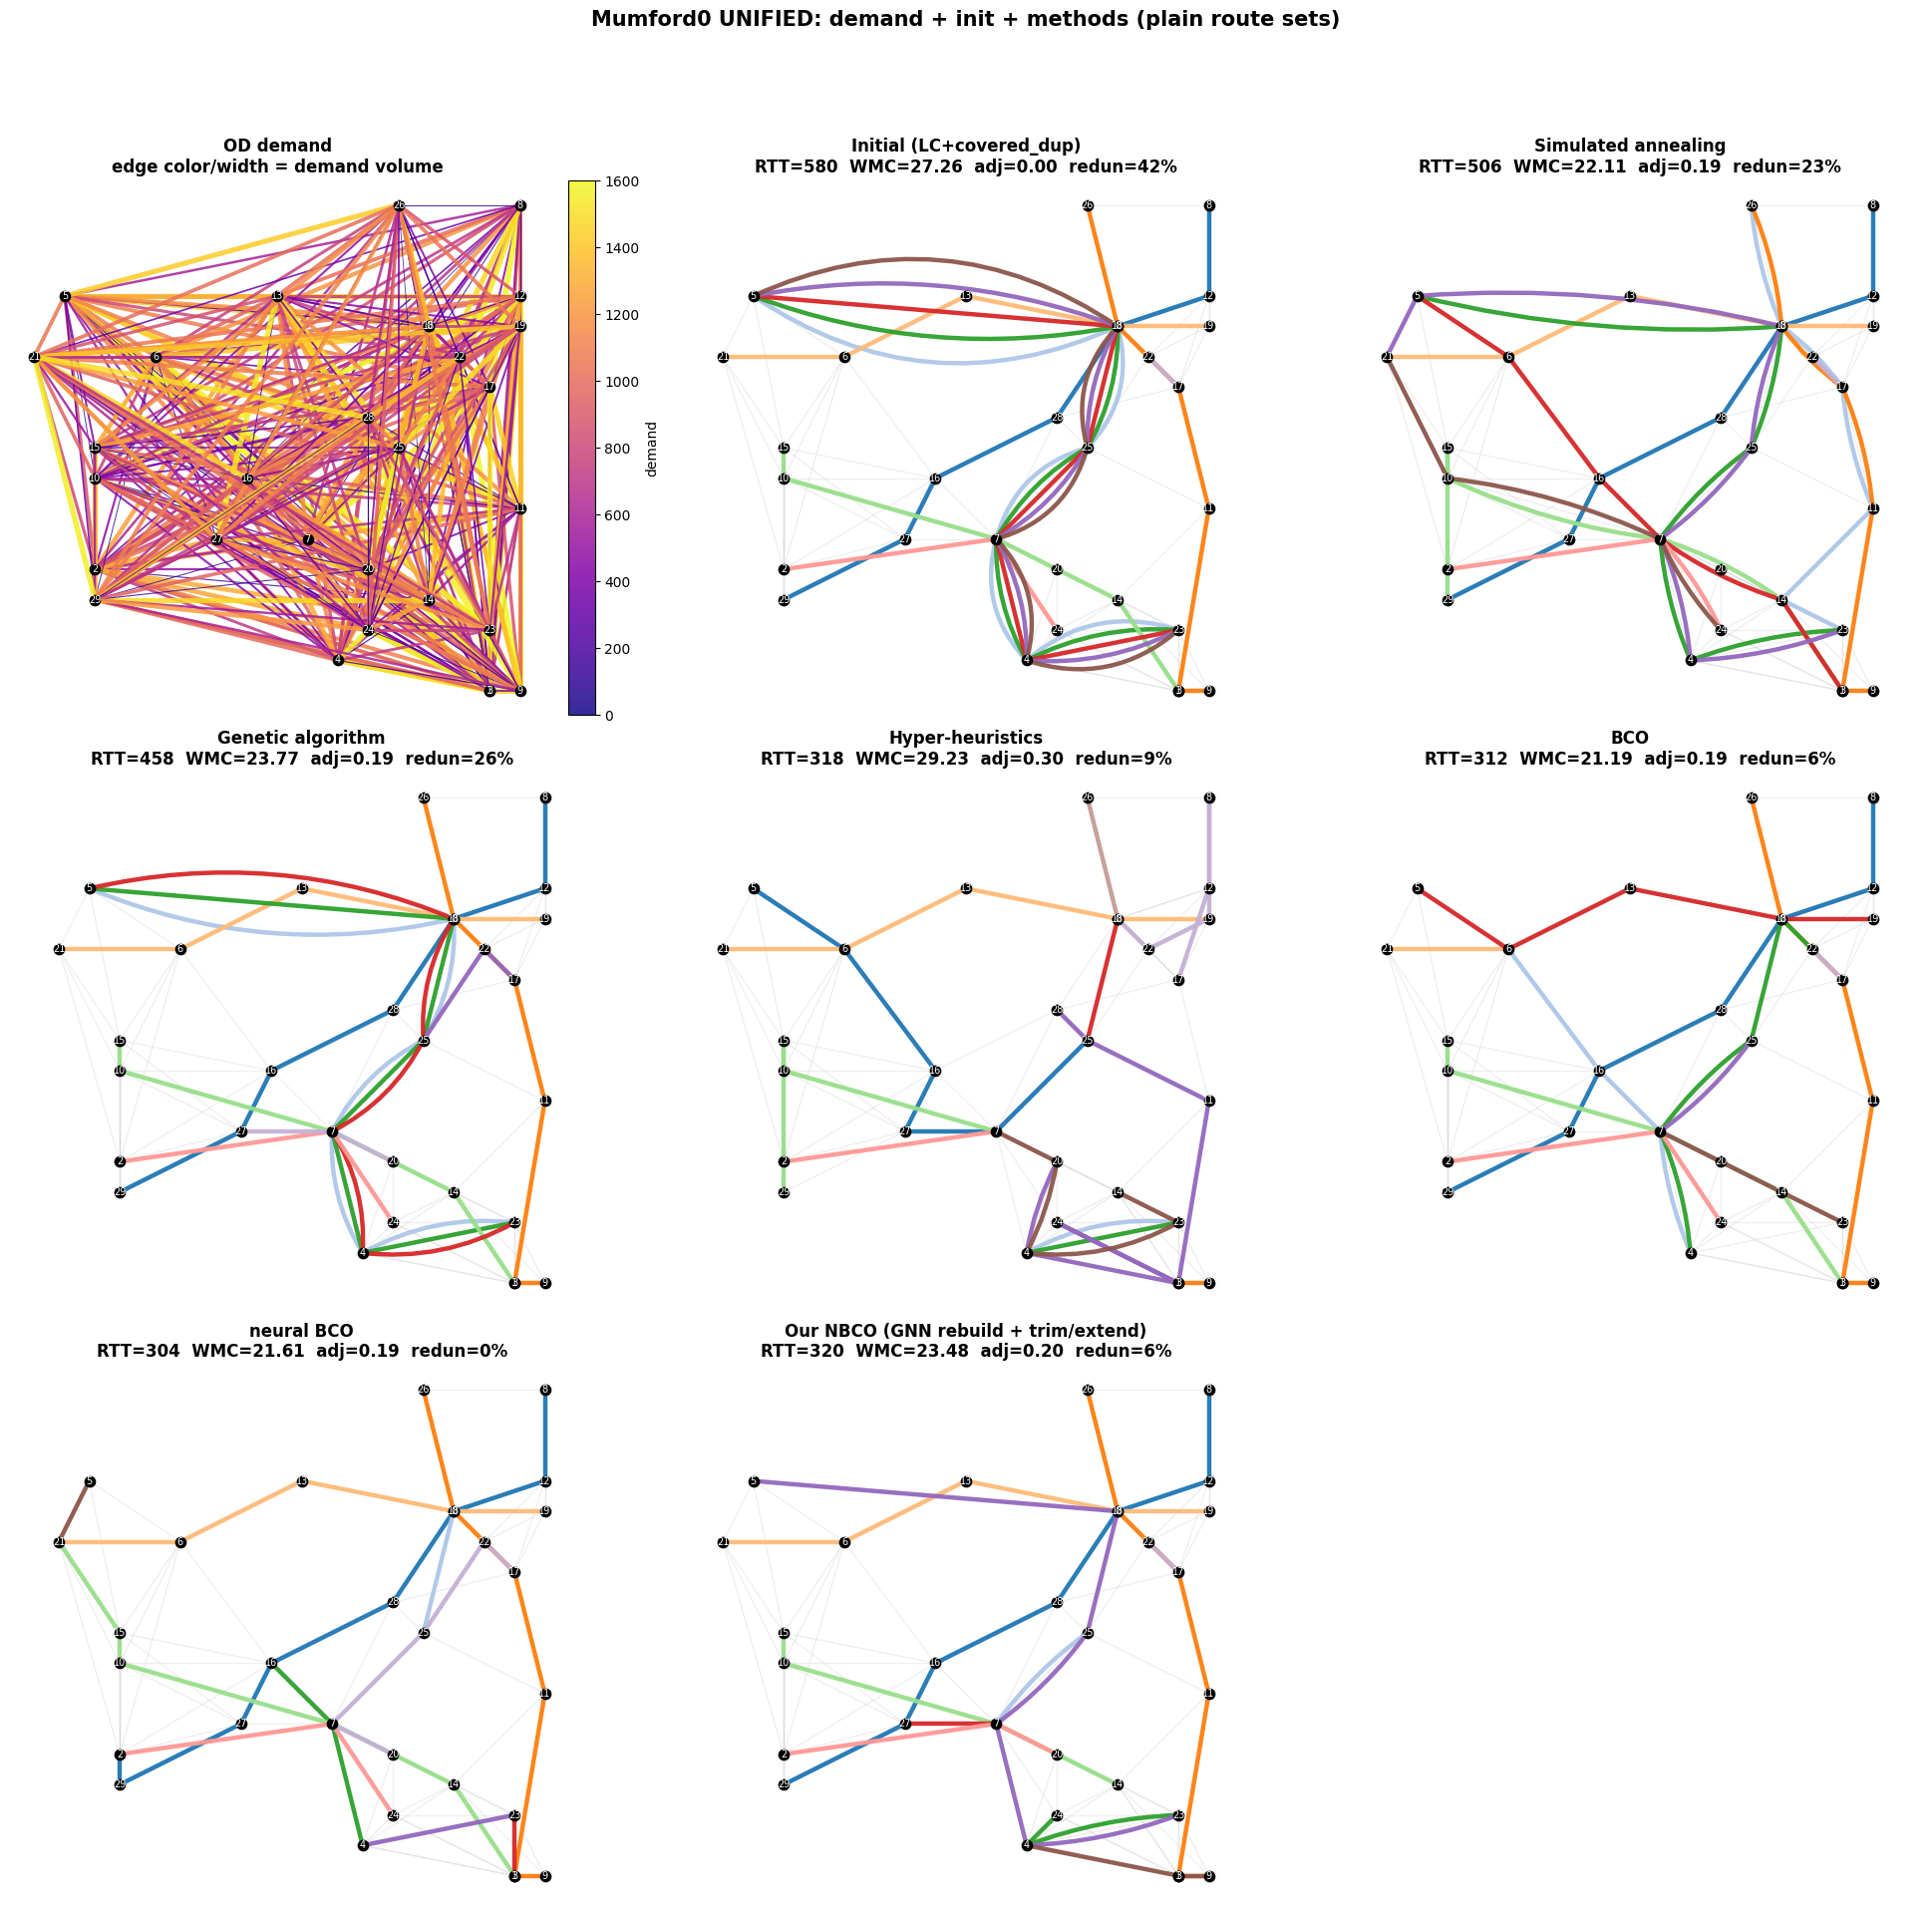

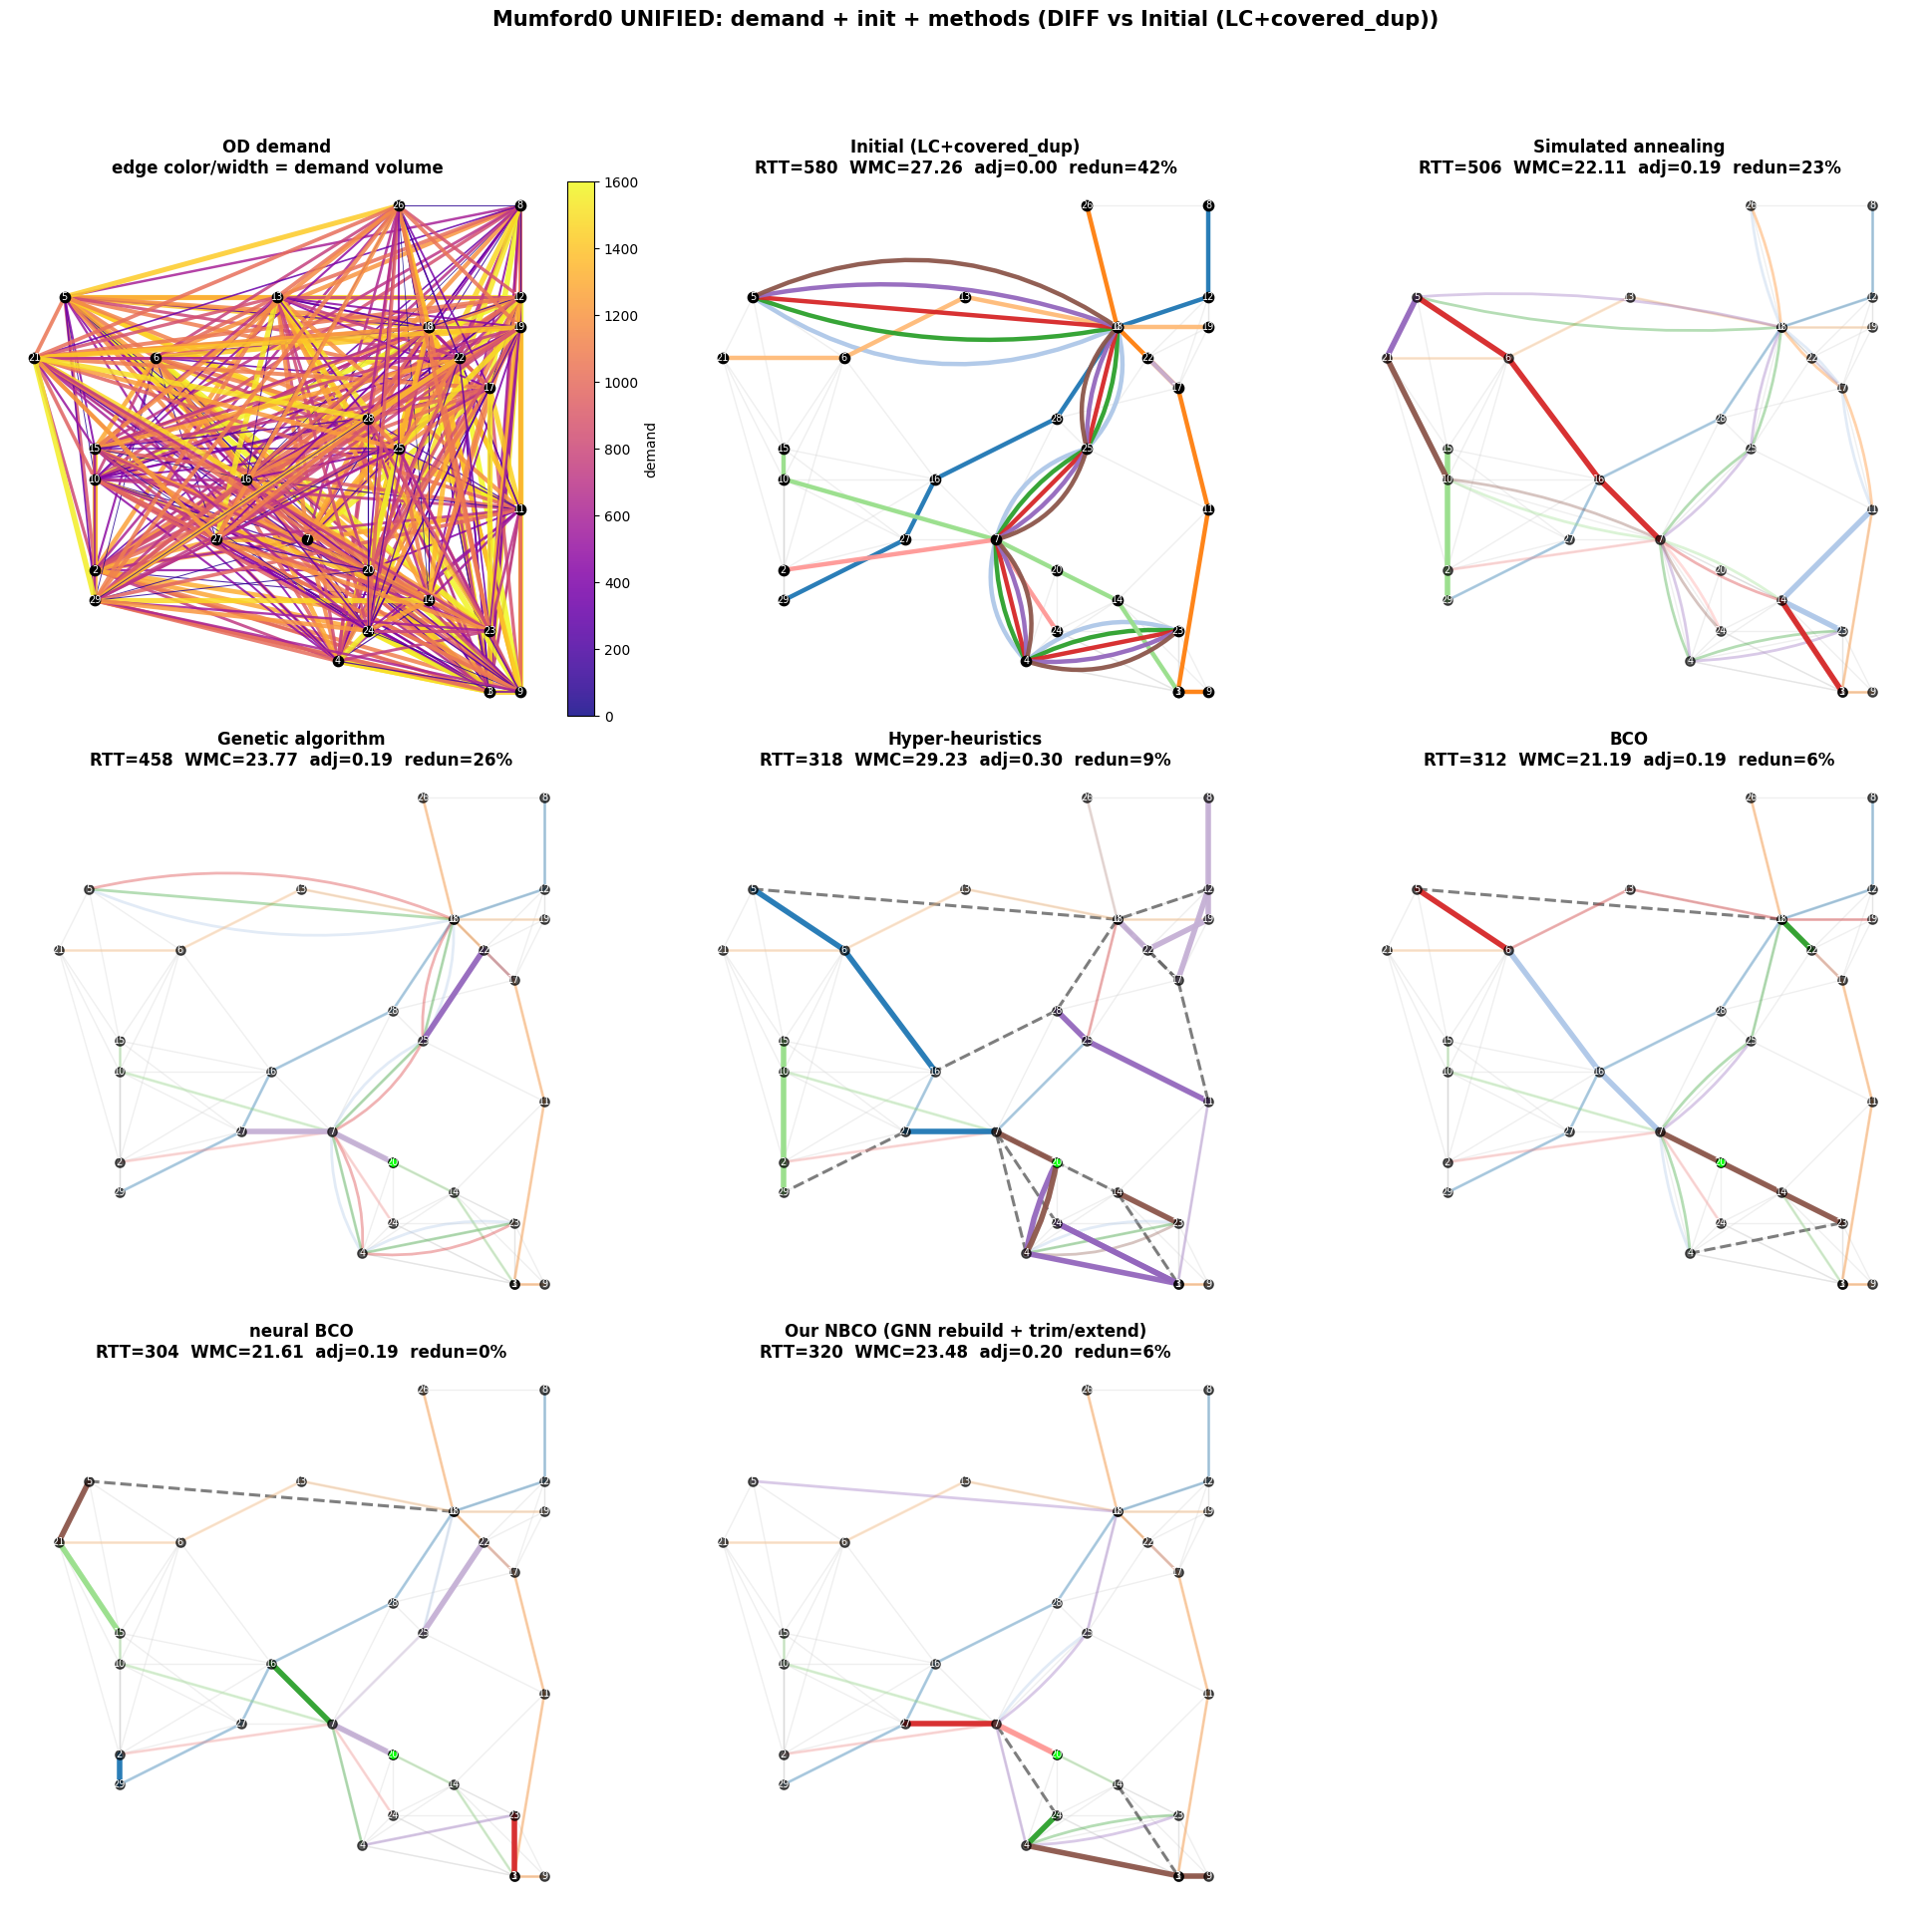

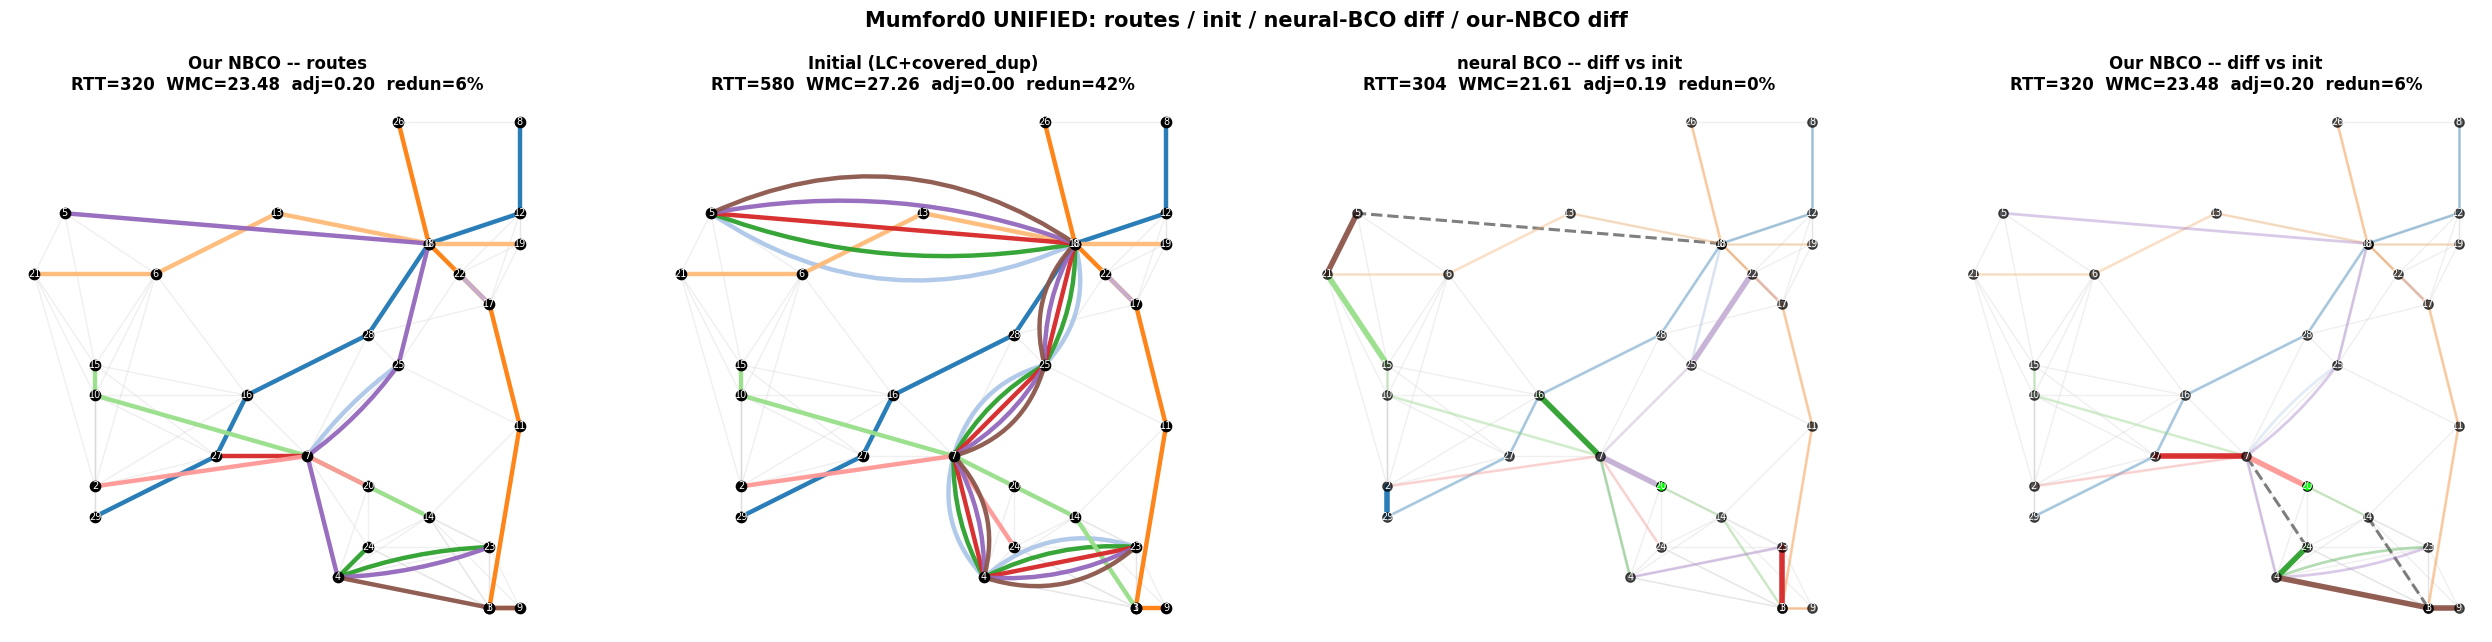

focused 4-panel: our='Our NBCO (GNN rebuild + trim/extend)', nbco='neural BCO', ref='Initial (LC+covered_dup)'
drawn demand + init + 7 methods x2 (plain+diff) for Mumford0; ref='Initial (LC+covered_dup)'


In [ ]:
# Autonomous route-set visualisation (reads paper_results dumps). Layout:
#   grid 1 (plain): [OD demand] [init] [methods...]
#   grid 2 (diff):  [OD demand] [init] [methods diff vs init]
#   + focused 1x4: our routes / init / neural-BCO diff / our-NBCO diff.
import math
import torch
import pandas as pd
import matplotlib.pyplot as plt
from eval_lib.results_io import ARTIFACTS_DIR
from eval_lib import plots as route_plots
from eval_lib import as_route_tensor, load_benchmark_tensors

VIZ_CITY = "Mumford0"          #  UNIFIED route dumps
VIZ_OVERLAP_CURVES = True      # overlap "ribbons"; set False for dense Mumford networks
VIZ_NCOL = 3
VIZ_DEMAND_TOP_FRAC = None     # None = all OD pairs; e.g. 0.15 keeps only busiest 15%

_prdir = ARTIFACTS_DIR / "paper_results"
_vsfx = "_smoke" if SMOKE else ""
_ptf = _prdir / f"final_main_unified_{VIZ_CITY}{_vsfx}_routes.pt"
assert _ptf.exists(), f"no route dump: {_ptf} (run E1u for {VIZ_CITY} first)"
_dump = torch.load(_ptf, weights_only=False)
_routes, _coords, _adj = _dump["routes"], _dump["coords"], _dump["street_adj"]
_methods = list(_routes)
_demand = load_benchmark_tensors(VIZ_CITY)["demand"]   # OD matrix for the demand panel

# initial network = reference for the diff version
_ref_key = next((m for m in _methods if "Initial" in m), _methods[0])
_ref_rt = as_route_tensor(_routes[_ref_key]); _ref_rr = _ref_rt[0] if _ref_rt.ndim == 3 else _ref_rt

# optional metric subtitle from the matching results table
_sub = {}
_csvf = _prdir / f"final_main_unified_{VIZ_CITY}{_vsfx}.csv"
if _csvf.exists():
    _df = pd.read_csv(_csvf).set_index("method")
    for _m, _r in _df.iterrows():
        _sub[_m] = (f"RTT={_r['RTT']:.0f}  WMC={_r['WMC']:.2f}  "
                    f"adj={_r['adj_vs_seed']:.2f}  redun={_r['redun%']:.0f}%")


def _draw_panel(ax, key, diff):
    if key == "__demand__":
        route_plots.plot_demand_graph(ax, _demand, _coords, _adj, title="OD demand",
                                      subtitle="edge color/width = demand volume",
                                      top_frac=VIZ_DEMAND_TOP_FRAC)
        return
    _rt = as_route_tensor(_routes[key]); _rr = _rt[0] if _rt.ndim == 3 else _rt
    try:
        if diff and key != _ref_key:
            route_plots.plot_route_diff(ax, _rr, _ref_rr, _coords, _adj, title=key,
                                        subtitle=_sub.get(key, ""), palette="tab20",
                                        with_overlap_curves=VIZ_OVERLAP_CURVES)
        else:
            route_plots.plot_plain_route_set(ax, _rr, _coords, _adj, title=key,
                                             subtitle=_sub.get(key, ""), palette="tab20",
                                             with_overlap_curves=VIZ_OVERLAP_CURVES)
    except Exception as exc:
        ax.set_title(f"{key}: plot failed ({exc})")


def _draw_grid(diff):
    # panel order: demand first, init second, then every other method
    panels = ["__demand__", _ref_key] + [m for m in _methods if m != _ref_key]
    _nrow = math.ceil(len(panels) / VIZ_NCOL)
    fig, axes = plt.subplots(_nrow, VIZ_NCOL, figsize=(6.5 * VIZ_NCOL, 6.5 * _nrow), squeeze=False)
    for _ax, _panel in zip(axes.flat, panels):
        _draw_panel(_ax, _panel, diff)
    for _ax in axes.flat[len(panels):]:
        _ax.axis("off")
    _kind = f"DIFF vs {_ref_key}" if diff else "plain route sets"
    fig.suptitle(f"{VIZ_CITY} UNIFIED: demand + init + methods ({_kind})",
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show(); plt.close(fig)


_draw_grid(diff=False)   # version 1: plain route sets
_draw_grid(diff=True)    # version 2: diff vs the initial network


# --- focused 1x4: our routes / init / neural-BCO diff / our-NBCO diff ---
_our_key = next((m for m in _methods if "Our NBCO" in m), None)
_nbco_key = next((m for m in _methods if m == "neural BCO"),
                 next((m for m in _methods if "neural" in m.lower()), None))
if _our_key and _nbco_key:
    _ourt = as_route_tensor(_routes[_our_key]); _our_rr = _ourt[0] if _ourt.ndim == 3 else _ourt
    _nbt = as_route_tensor(_routes[_nbco_key]); _nb_rr = _nbt[0] if _nbt.ndim == 3 else _nbt
    fig, axes = plt.subplots(1, 4, figsize=(26, 6.5), squeeze=False)
    route_plots.plot_plain_route_set(axes[0, 0], _our_rr, _coords, _adj,
                                     title="Our NBCO -- routes", subtitle=_sub.get(_our_key, ""),
                                     palette="tab20", with_overlap_curves=VIZ_OVERLAP_CURVES)
    route_plots.plot_plain_route_set(axes[0, 1], _ref_rr, _coords, _adj, title=_ref_key,
                                     subtitle=_sub.get(_ref_key, ""), palette="tab20",
                                     with_overlap_curves=VIZ_OVERLAP_CURVES)
    route_plots.plot_route_diff(axes[0, 2], _nb_rr, _ref_rr, _coords, _adj,
                                title="neural BCO -- diff vs init", subtitle=_sub.get(_nbco_key, ""),
                                palette="tab20", with_overlap_curves=VIZ_OVERLAP_CURVES)
    route_plots.plot_route_diff(axes[0, 3], _our_rr, _ref_rr, _coords, _adj,
                                title="Our NBCO -- diff vs init", subtitle=_sub.get(_our_key, ""),
                                palette="tab20", with_overlap_curves=VIZ_OVERLAP_CURVES)
    fig.suptitle(f"{VIZ_CITY} UNIFIED: routes / init / neural-BCO diff / our-NBCO diff",
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94]); plt.show(); plt.close(fig)
    print(f"focused 4-panel: our={_our_key!r}, nbco={_nbco_key!r}, ref={_ref_key!r}")
else:
    print(f"4-panel skipped (missing key): our={_our_key!r}, nbco={_nbco_key!r}")

print(f"drawn demand + init + {len(_methods)} methods x2 (plain+diff) for {VIZ_CITY}; ref={_ref_key!r}")


## MACSA -- our NBCO vs neural BCO (unified objective)

Run our model (GNN rebuild + trim/extend) and neural BCO on the MACSA
scenario(s) (`datasets/MACSA_data/`), seeded from the scenario's own routes,
on the same unified objective (0.5*RTT + 0.5*WMC + adj |.-target|@`ADJ_TARGET`,
WMC = median weighted connectivity). Table + route visualisation below.

In [ ]:
import time as _t
from connectpt.routes_generator.citygraph_dataset import load_macsa_scenarios
from eval_lib.paper import macsa_eval_bounds
from eval_lib.context import MACSA_DATA_DIR

_macsa_scenarios = load_macsa_scenarios(MACSA_DATA_DIR)
print("MACSA scenarios:", [s["name"] for s in _macsa_scenarios], flush=True)

MACSA_RESULTS = {}     # name -> (routes dict, tensors, init)
macsa_rows = []
for _scn in _macsa_scenarios:
    _name = _scn["name"]
    _tensors = _scn["tensors"]
    _init = as_route_tensor(_scn["routes"]);  _init = _init if _init.ndim == 3 else _init[None]
    _nr, _mn, _mx = macsa_eval_bounds(_scn)
    _spec = {"city": _name, "n_routes": _nr, "min_route_len": _mn, "max_route_len": _mx}
    _seed = _init
    _rows, _routes = [], {}

    def _madd(method, m, rt, dt=None):
        rt = as_route_tensor(rt)
        row = _row(_name, method, "macsa", m, rt, _seed)
        row["duration_s"] = round(float(dt), 1) if dt is not None else None
        _rows.append(row); _routes[method] = rt
        print(f"  [{_name}] {method:34} RTT={row['RTT']:.0f} WMC={row['WMC']:.2f} "
              f"adj={row['adj_vs_seed']:.2f} cost={row['cost']:.3f} redun={row['redun%']:.0f}%",
              flush=True)

    print(f"=== MACSA {_name}: n_routes={_nr} (unified objective) ===", flush=True)
    _madd(f"Initial (MACSA {_name})",
          *(_run_baseline(None, _unify_weights(_eval_routes_cfg(_name, _spec)), _init,
                          f"{_name}_macsa_init_", {}, tensors=_tensors,
                          use_weighted_connectivity=True)[1::2]))

    # neural BCO (GNN rebuild + type-2), unified weights + adj
    _v = next(x for x in BCO_VARIANTS if x["key"] == "seeded_neural")
    _t0 = _t.perf_counter()
    _cfg = _variant_bco_cfg(_name, _spec, _v, weights=UNIFIED_COST_WEIGHTS, run_name_suffix="macsa_")
    bco_cfg_set(_cfg, **UNIFIED_ADJ)
    _set_cfg_value(_cfg, "experiment.cost_function.kwargs.use_weighted_connectivity", True)
    _r = run_bco(_cfg, _init, tensors=_tensors, run_name_scope=f"{_name}_")
    _madd("neural BCO", _r[1], _r[3], _t.perf_counter() - _t0)

    # our NBCO (GNN rebuild + trim/extend edit), unified objective + adj
    _t0 = _t.perf_counter()
    _r = run_bco(_our_model_cfg(_name, _spec, adj_target=ADJ_TARGET,
                                seed=SEEDS[0], use_gnn=True),
                 _init, tensors=_tensors, run_name_scope=f"{_name}_")
    _madd(f"Our NBCO ({OUR_NBCO_VERSIONS[0][1]})", _r[1], _r[3], _t.perf_counter() - _t0)

    macsa_rows += _rows
    MACSA_RESULTS[_name] = (_routes, _tensors, _init)
    _sfx = "_smoke" if SMOKE else ""
    save_paper_table(pd.DataFrame(_rows).round(3), f"final_macsa_{_name}{_sfx}")
    save_paper_routes(f"final_macsa_{_name}{_sfx}", _routes,
                      _tensors["node_locs"], _tensors["street_adj"], meta={"scenario": _name})

macsa_df = pd.DataFrame(macsa_rows).round(3)
display(macsa_df)
save_paper_table(macsa_df, "final_macsa_comparison" + ("_smoke" if SMOKE else ""))
print("MACSA done -> paper_results/final_macsa_*.")

MACSA scenarios: ['mandl_8']
=== MACSA mandl_8: n_routes=8 (unified objective) ===
,8.000,0.832,12.088,346.000,84.062,15.392,0.546,0.000,0.000,0.000,18.267,11.695,0.007,0.000
  [mandl_8] Initial (MACSA mandl_8)            RTT=346 WMC=11.69 adj=0.00 cost=0.832 redun=54%
[mandl_8_macsa_seeded_neural_bco_from_lc_mumford0] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=5 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=0 trim_only=0 trim_then_extend=0 (total=10)


100%|██████████| 500/500 [07:00<00:00,  1.19it/s]

,8.000,0.670,14.751,248.000,66.029,21.888,11.475,0.607,0.000,0.000,19.867,13.198,420.869,501.000
  [mandl_8] neural BCO                         RTT=248 WMC=13.20 adj=0.20 cost=0.670 redun=36%


[mandl_8_our_nbco_gnn_rebuild_trimext] route_selection=uniform-random | bee split: neural_rebuild=5 local_endpoint_edit=0 path_mix_rebuild=0 construction_extend=0 extend_trim_edit=5 trim_only=0 trim_then_extend=0 (total=10)


100%|██████████| 500/500 [11:46<00:00,  1.41s/it]

,8.000,0.677,13.009,244.000,78.142,19.429,2.368,0.061,0.000,0.000,20.467,14.166,706.570,501.000
  [mandl_8] Our NBCO (GNN rebuild + trim/extend) RTT=244 WMC=14.17 adj=0.20 cost=0.677 redun=38%
[paper] table (3 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_macsa_mandl_8.csv
[paper] route dump (3 sets) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_macsa_mandl_8_routes.pt


,city,method,source,duration_s,ATT,RTT,WMC,WMC_mean,WMC_median,adj_vs_seed,rtt_cost,wmc_cost,cost,d0,d1,d2,d_un,redun%
0,mandl_8,Initial (MACSA mandl_8),macsa,NaN,12.088,346.0,11.695,13.782,11.695,0.000,1.311,0.354,0.832,84.062,15.392,0.546,0.000,54.286
1,mandl_8,neural BCO,macsa,421.0,14.751,248.0,13.198,16.294,13.198,0.201,0.939,0.400,0.670,66.029,21.888,11.475,0.607,36.000
2,mandl_8,Our NBCO (GNN rebuild + trim/extend),macsa,706.8,13.009,244.0,14.166,14.838,14.166,0.200,0.924,0.429,0.677,78.142,19.429,2.368,0.061,37.500


[paper] table (3 rows) -> D:\PythonProjects\connectpt\artifacts\paper_results\final_macsa_comparison.csv
MACSA done -> paper_results/final_macsa_*.


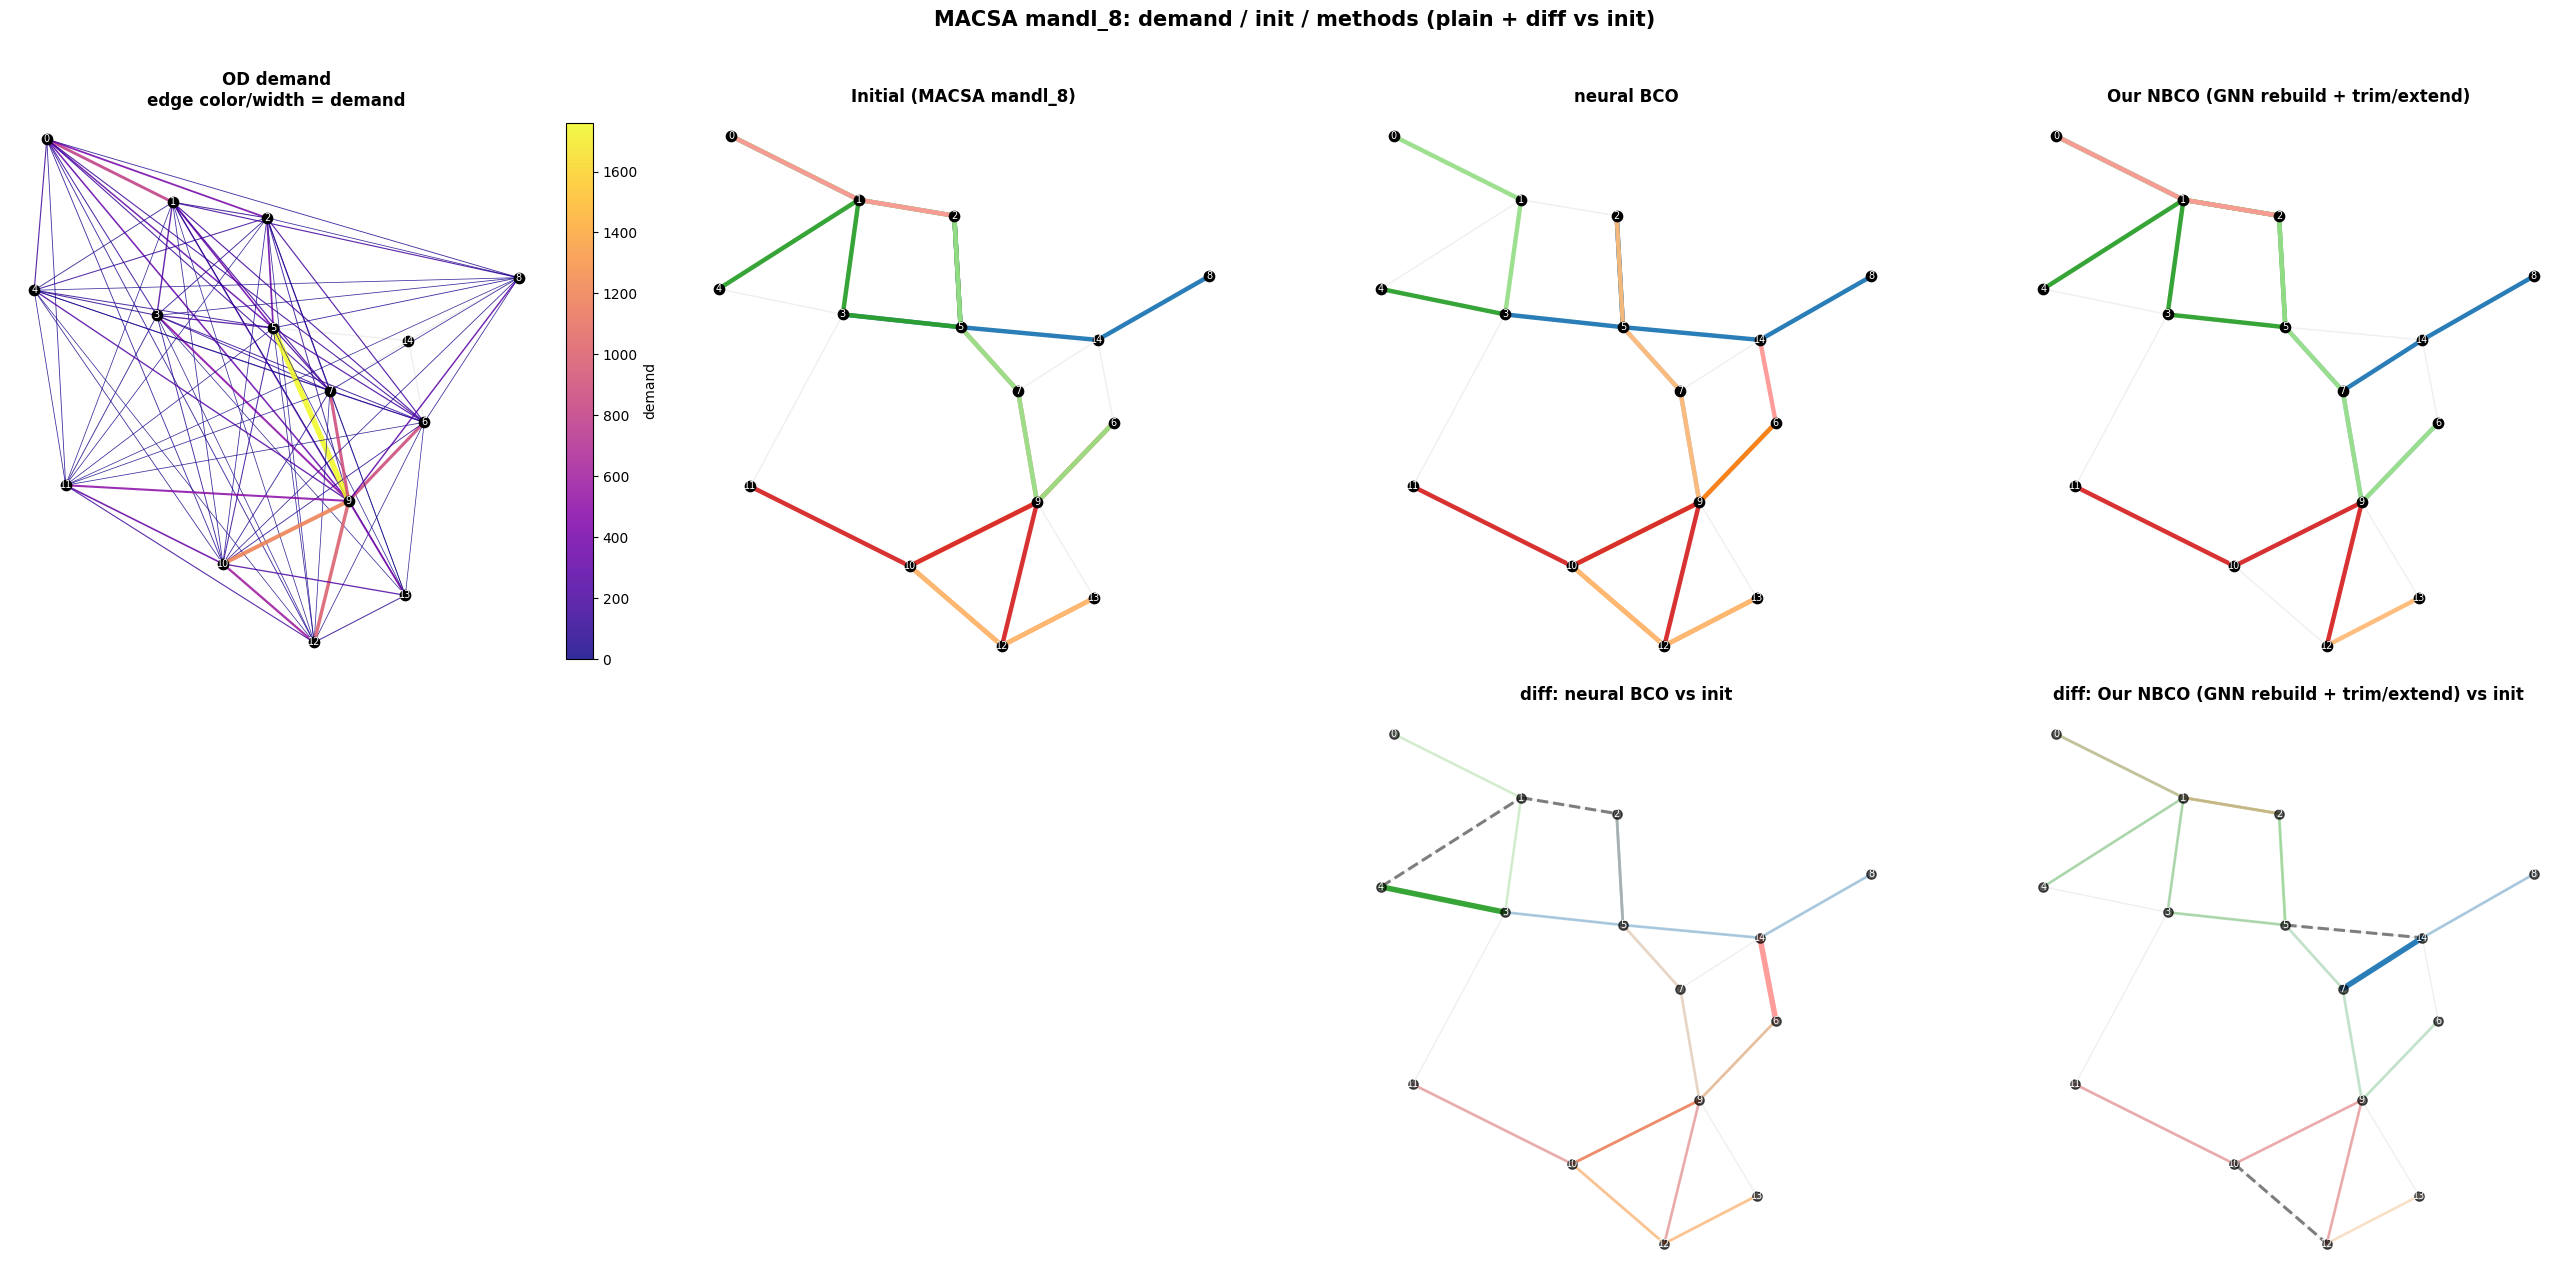

MACSA viz drawn for ['mandl_8']


In [ ]:
# MACSA route visualisation: OD demand + init + methods (plain row + diff-vs-init row).
import matplotlib.pyplot as plt
from eval_lib import plots as route_plots

for _name, (_routes, _tensors, _init) in MACSA_RESULTS.items():
    _methods = list(_routes)
    _ref_key = next((m for m in _methods if "Initial" in m), _methods[0])
    _ref_rt = as_route_tensor(_routes[_ref_key]); _ref_rr = _ref_rt[0] if _ref_rt.ndim == 3 else _ref_rt
    _coords, _adj, _demand = _tensors["node_locs"], _tensors["street_adj"], _tensors["demand"]
    _panels = ["__demand__", _ref_key] + [m for m in _methods if m != _ref_key]
    fig, axes = plt.subplots(2, len(_panels), figsize=(6.5 * len(_panels), 13), squeeze=False)
    for _col, _p in enumerate(_panels):
        if _p == "__demand__":
            route_plots.plot_demand_graph(axes[0, _col], _demand, _coords, _adj,
                                          title="OD demand", subtitle="edge color/width = demand")
            axes[1, _col].axis("off")
            continue
        _rt = as_route_tensor(_routes[_p]); _rr = _rt[0] if _rt.ndim == 3 else _rt
        route_plots.plot_plain_route_set(axes[0, _col], _rr, _coords, _adj, title=_p,
                                         palette="tab20", with_overlap_curves=False)
        if _p != _ref_key:
            route_plots.plot_route_diff(axes[1, _col], _rr, _ref_rr, _coords, _adj,
                                        title=f"diff: {_p} vs init", palette="tab20",
                                        with_overlap_curves=False)
        else:
            axes[1, _col].axis("off")
    fig.suptitle(f"MACSA {_name}: demand / init / methods (plain + diff vs init)",
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show(); plt.close(fig)
print(f"MACSA viz drawn for {list(MACSA_RESULTS)}")